In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, ModelOutputConstants, NASADatasetConstants
from preprocessing_functions import generate_sliding_window_data
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM
from models.train import train_model
from models.evaluate import evaluate_model, plot_predictions
from models.save_load import save_model, load_model
import pathlib

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
TRAIN_RATIO = 0.8
VAL_RATIO = 1 - TRAIN_RATIO

class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

# CALCE Dataset

## Loading the Data

In [5]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
PROCESSED_BATTERY_PATHS

[WindowsPath('c:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_35.csv'),
 WindowsPath('c:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_36.csv'),
 WindowsPath('c:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_37.csv'),
 WindowsPath('c:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_38.csv')]

In [6]:
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

# Visualizing the data along with train test split

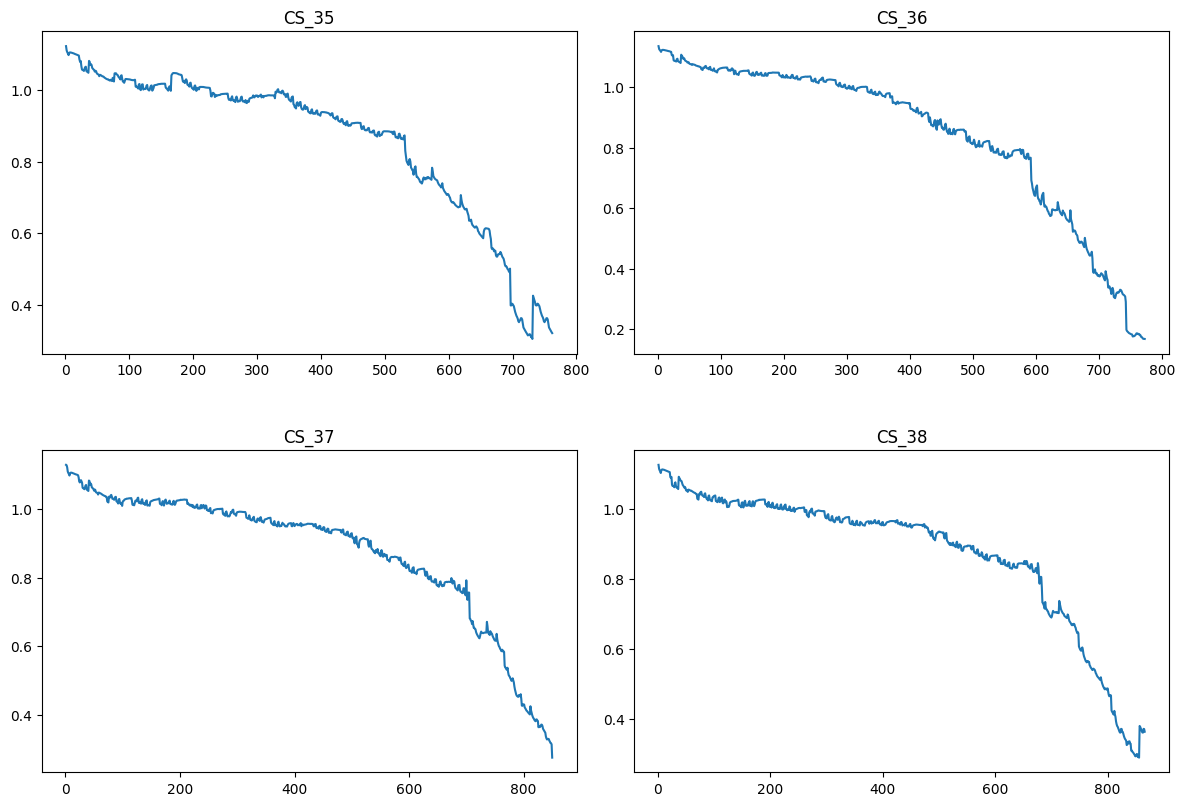

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [8]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in CALCEDatasetConstants.BATTERY_NUMBERS.value:
    excluded_list = [x for x in CALCEDatasetConstants.BATTERY_NUMBERS.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[(35, [36, 37, 38]),
 (36, [35, 37, 38]),
 (37, [35, 36, 38]),
 (38, [35, 36, 37])]

In [9]:
TRAINING_BATTERIES = CALCEDatasetConstants.BATTERY_NUMBERS.value[:3]
TEST_BATTERY = CALCEDatasetConstants.BATTERY_NUMBERS.value[3]

In [10]:
x, y = generate_sliding_window_data(dfs[TRAINING_BATTERIES[0]]['Discharge_Capacity(Ah)'])
x.shape, y.shape

((752, 10), (752,))

In [11]:
x.shape, y.shape

((752, 10), (752,))

In [21]:
CALCE_train_dataloaders_30 = []
CALCE_val_dataloaders_30 = []
CALCE_test_dataloaders_30 = []
n = 30

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []

    test_capacity = dfs[test_battery]['Discharge_Capacity(Ah)'].to_numpy()
    split_idx = int(len(test_capacity) * (n / 100))  # First n% index
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
        trainX.extend(x)
        trainY.extend(y)

    train_part = test_capacity[:split_idx]
    test_part = test_capacity[split_idx:]

    # Generate train data from the first n% of test battery
    trainX_test, trainY_test = generate_sliding_window_data(train_part)
    trainX.extend(trainX_test)
    trainY.extend(trainY_test)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(test_part)
    testX, testY = np.array(testX), np.array(testY)
    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    CALCE_train_dataloaders_30.append(train_dataloader)
    CALCE_val_dataloaders_30.append(val_dataloader)
    CALCE_test_dataloaders_30.append(test_dataloader)

In [22]:
CALCE_train_dataloaders_30, CALCE_val_dataloaders_30, CALCE_test_dataloaders_30

([<torch.utils.data.dataloader.DataLoader at 0x2867f598c20>,
  <torch.utils.data.dataloader.DataLoader at 0x2867f59f980>])

In [23]:
CALCE_train_dataloaders_50 = []
CALCE_val_dataloaders_50 = []
CALCE_test_dataloaders_50 = []
n = 50

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []

    test_capacity = dfs[test_battery]['Discharge_Capacity(Ah)'].to_numpy()
    split_idx = int(len(test_capacity) * (n / 100))  # First n% index
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
        trainX.extend(x)
        trainY.extend(y)

    train_part = test_capacity[:split_idx]
    test_part = test_capacity[split_idx:]

    # Generate train data from the first n% of test battery
    trainX_test, trainY_test = generate_sliding_window_data(train_part)
    trainX.extend(trainX_test)
    trainY.extend(trainY_test)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(test_part)
    testX, testY = np.array(testX), np.array(testY)
    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    CALCE_train_dataloaders_50.append(train_dataloader)
    CALCE_val_dataloaders_50.append(val_dataloader)
    CALCE_test_dataloaders_50.append(test_dataloader)

In [24]:
CALCE_train_dataloaders_50, CALCE_val_dataloaders_50, CALCE_test_dataloaders_50

([<torch.utils.data.dataloader.DataLoader at 0x2867f644c80>,
  <torch.utils.data.dataloader.DataLoader at 0x2867f646150>])

In [25]:
MAX = 1.1
MIN = 0.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

c:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1: Validation loss improved to 0.7411988623001996. Model saved!
Epoch 1/50, Train Loss: 0.8715839661769013, Val Loss: 0.7411988623001996
Epoch 2: Validation loss improved to 0.21341165198999293. Model saved!
Epoch 2/50, Train Loss: 0.5088254084338003, Val Loss: 0.21341165198999293
Epoch 3: Validation loss improved to 0.018842765020535272. Model saved!
Epoch 3/50, Train Loss: 0.08427902917141344, Val Loss: 0.018842765020535272
Epoch 4: Validation loss improved to 0.002448732841431218. Model saved!
Epoch 4/50, Train Loss: 0.007816200238416221, Val Loss: 0.002448732841431218
Epoch 5: Validation loss improved to 0.0008046064501874806. Model saved!
Epoch 5/50, Train Loss: 0.0015952914020171695, Val Loss: 0.0008046064501874806
Epoch 6: Validation loss improved to 0.00039924973680172116. Model saved!
Epoch 6/50, Train Loss: 0.0007306683283827421, Val Loss: 0.00039924973680172116
Epoch 7: Validation loss improved to 0.00031641193987418185. Model saved!
Epoch 7/50, Train Loss: 0.000647097

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\248334962.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConstan

RMSE: 0.012061202654894554
MAE: 0.007452609543581955


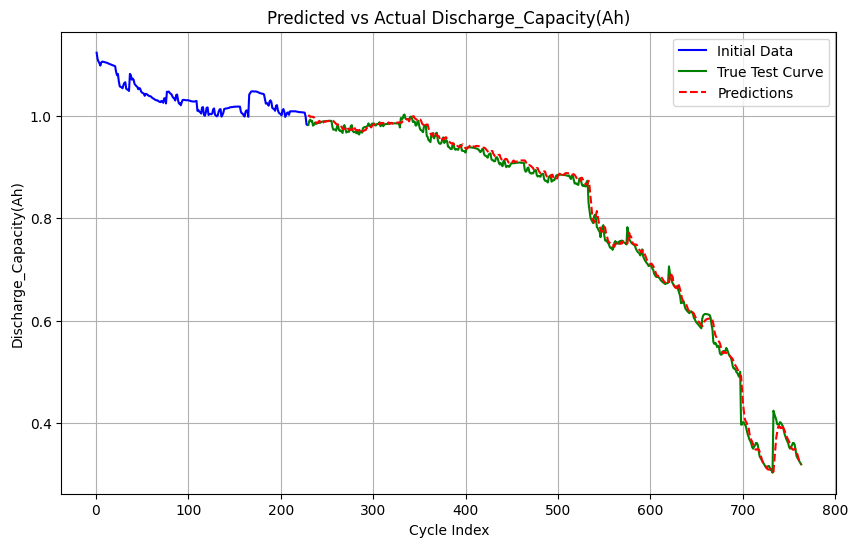

Epoch 1: Validation loss improved to 0.8381774670937482. Model saved!
Epoch 1/50, Train Loss: 0.87541533939874, Val Loss: 0.8381774670937482
Epoch 2: Validation loss improved to 0.3211963492281297. Model saved!
Epoch 2/50, Train Loss: 0.6473972032319254, Val Loss: 0.3211963492281297
Epoch 3: Validation loss improved to 0.03524026296594564. Model saved!
Epoch 3/50, Train Loss: 0.13681522756814957, Val Loss: 0.03524026296594564
Epoch 4: Validation loss improved to 0.0021028057946001783. Model saved!
Epoch 4/50, Train Loss: 0.010939536915063414, Val Loss: 0.0021028057946001783
Epoch 5: Validation loss improved to 0.000561474623870762. Model saved!
Epoch 5/50, Train Loss: 0.0012362597174872991, Val Loss: 0.000561474623870762
Epoch 6: Validation loss improved to 0.0003837073197834851. Model saved!
Epoch 6/50, Train Loss: 0.000666805301704305, Val Loss: 0.0003837073197834851
Epoch 7: Validation loss improved to 0.0003455851739786072. Model saved!
Epoch 7/50, Train Loss: 0.0004847058081571986

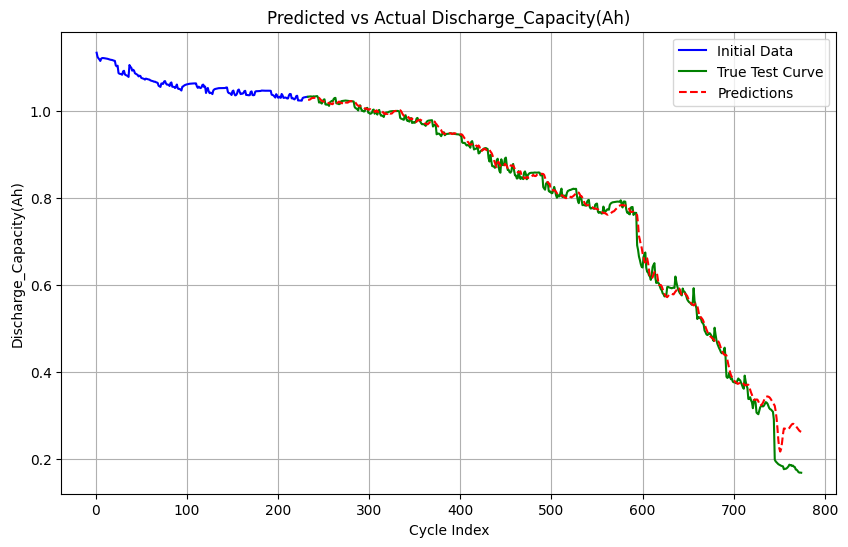

Epoch 1: Validation loss improved to 0.8091686648481032. Model saved!
Epoch 1/50, Train Loss: 0.9869776566823324, Val Loss: 0.8091686648481032
Epoch 2: Validation loss improved to 0.3089476630968206. Model saved!
Epoch 2/50, Train Loss: 0.5638594690597418, Val Loss: 0.3089476630968206
Epoch 3: Validation loss improved to 0.05308007405084722. Model saved!
Epoch 3/50, Train Loss: 0.1534417960228342, Val Loss: 0.05308007405084722
Epoch 4: Validation loss improved to 0.005024316871319623. Model saved!
Epoch 4/50, Train Loss: 0.019559089665893804, Val Loss: 0.005024316871319623
Epoch 5: Validation loss improved to 0.0008349276202566483. Model saved!
Epoch 5/50, Train Loss: 0.002605502850862897, Val Loss: 0.0008349276202566483
Epoch 6: Validation loss improved to 0.0005156943353701054. Model saved!
Epoch 6/50, Train Loss: 0.0010714686495978667, Val Loss: 0.0005156943353701054
Epoch 7: Validation loss improved to 0.0003487201585598728. Model saved!
Epoch 7/50, Train Loss: 0.000599872191687058

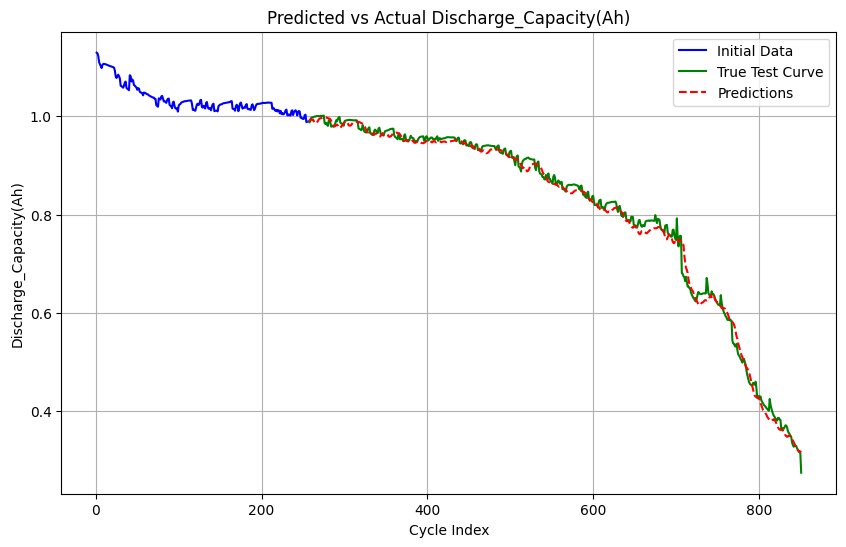

Epoch 1: Validation loss improved to 0.5224352514042574. Model saved!
Epoch 1/50, Train Loss: 0.5542889007113196, Val Loss: 0.5224352514042574
Epoch 2: Validation loss improved to 0.11387797664193545. Model saved!
Epoch 2/50, Train Loss: 0.3780584635608124, Val Loss: 0.11387797664193545
Epoch 3: Validation loss improved to 0.00041856985155712157. Model saved!
Epoch 3/50, Train Loss: 0.024554219256529133, Val Loss: 0.00041856985155712157
Epoch 4: Validation loss improved to 0.0004129760611035368. Model saved!
Epoch 4/50, Train Loss: 0.000802869455197431, Val Loss: 0.0004129760611035368
Epoch 5: Validation loss improved to 0.00025604006163228084. Model saved!
Epoch 5/50, Train Loss: 0.0007312205114320739, Val Loss: 0.00025604006163228084
Epoch 6: Validation loss improved to 0.0002560011005912469. Model saved!
Epoch 6/50, Train Loss: 0.0005392881776060676, Val Loss: 0.0002560011005912469
Epoch 7: Validation loss improved to 0.00022318804044249083. Model saved!
Epoch 7/50, Train Loss: 0.00

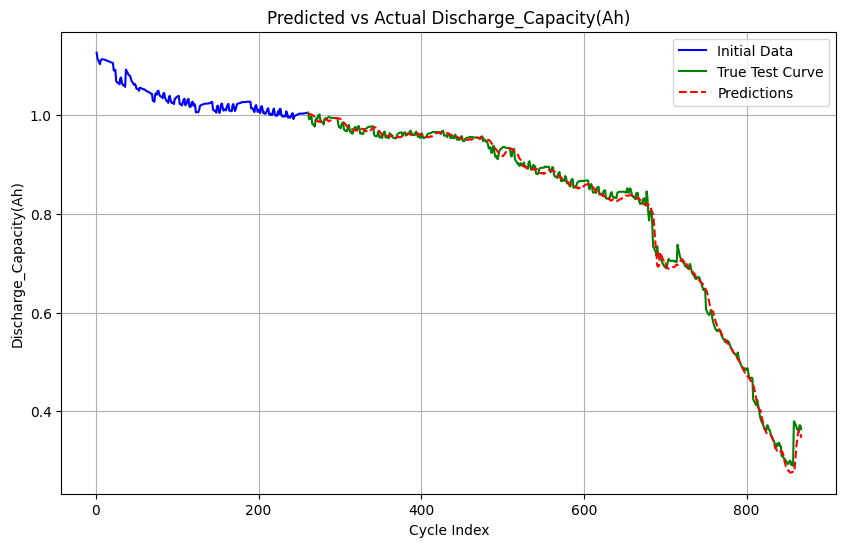

In [26]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model().to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50

    # Training
    train_model(
        model=model_1,
        train_dataloader=CALCE_train_dataloaders_30[i],
        val_dataloader = CALCE_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_30.pth'
    )

    # Evaluation
    model_1.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_30.pth'))
    model_1.to(device)
    
    metrics = evaluate_model(model_1, CALCE_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    # Plotting Curve
    plot_predictions(model_1, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

c:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1: Validation loss improved to 0.4175637513399124. Model saved!
Epoch 1/50, Train Loss: 0.4611014942048301, Val Loss: 0.4175637513399124
Epoch 2: Validation loss improved to 0.3949108057551914. Model saved!
Epoch 2/50, Train Loss: 0.4201962633032194, Val Loss: 0.3949108057551914
Epoch 3: Validation loss improved to 0.3455960286988152. Model saved!
Epoch 3/50, Train Loss: 0.3879414599546244, Val Loss: 0.3455960286988152
Epoch 4: Validation loss improved to 0.25684143271711135. Model saved!
Epoch 4/50, Train Loss: 0.3130215889131519, Val Loss: 0.25684143271711135
Epoch 5: Validation loss improved to 0.1448517201675309. Model saved!
Epoch 5/50, Train Loss: 0.20996494024572238, Val Loss: 0.1448517201675309
Epoch 6: Validation loss improved to 0.06674380890197223. Model saved!
Epoch 6/50, Train Loss: 0.10842706158127584, Val Loss: 0.06674380890197223
Epoch 7: Validation loss improved to 0.024234065061642066. Model saved!
Epoch 7/50, Train Loss: 0.046139695222528886, Val Loss: 0.024234

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\4045443427.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.01697518610029601
MAE: 0.01099854032948332


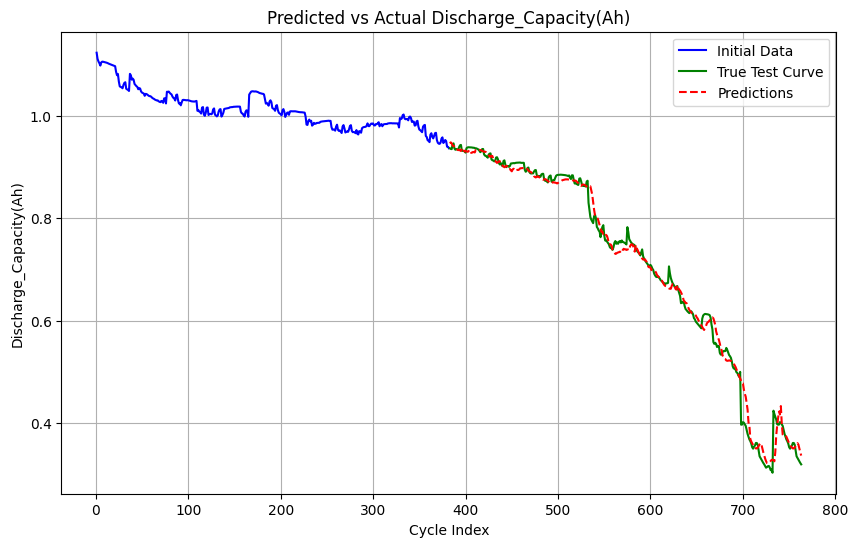

Epoch 1: Validation loss improved to 0.19635115481085247. Model saved!
Epoch 1/50, Train Loss: 0.29620858418269896, Val Loss: 0.19635115481085247
Epoch 2: Validation loss improved to 0.003920040274452832. Model saved!
Epoch 2/50, Train Loss: 0.08261957091384266, Val Loss: 0.003920040274452832
Epoch 3: Validation loss improved to 0.0003772731716809277. Model saved!
Epoch 3/50, Train Loss: 0.0012208814730680824, Val Loss: 0.0003772731716809277
Epoch 4: No improvement. (1/10)
Epoch 4/50, Train Loss: 0.00046285028072585625, Val Loss: 0.00038731171258000866
Epoch 5: Validation loss improved to 0.00028430453029512946. Model saved!
Epoch 5/50, Train Loss: 0.00046444192760735487, Val Loss: 0.00028430453029512946
Epoch 6: No improvement. (1/10)
Epoch 6/50, Train Loss: 0.00046910838659321494, Val Loss: 0.0003739911569735139
Epoch 7: Validation loss improved to 0.0002766177838364254. Model saved!
Epoch 7/50, Train Loss: 0.00039012567027435887, Val Loss: 0.0002766177838364254
Epoch 8: Validation l

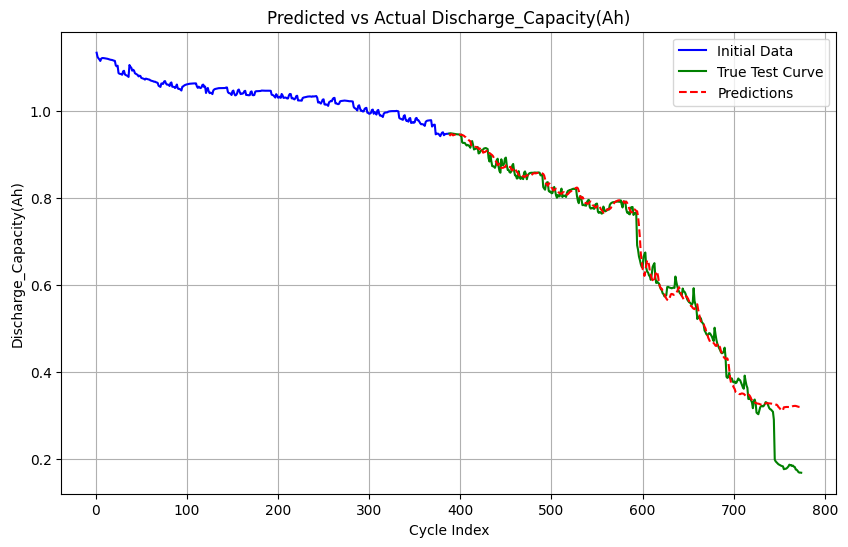

Epoch 1: Validation loss improved to 0.37989845044083065. Model saved!
Epoch 1/50, Train Loss: 0.4348124657358442, Val Loss: 0.37989845044083065
Epoch 2: Validation loss improved to 0.23715225524372524. Model saved!
Epoch 2/50, Train Loss: 0.3217963163341795, Val Loss: 0.23715225524372524
Epoch 3: Validation loss improved to 0.025109329778287146. Model saved!
Epoch 3/50, Train Loss: 0.1097905171769006, Val Loss: 0.025109329778287146
Epoch 4: Validation loss improved to 0.0016948543909368003. Model saved!
Epoch 4/50, Train Loss: 0.007299327429583562, Val Loss: 0.0016948543909368003
Epoch 5: Validation loss improved to 0.0007983162811595119. Model saved!
Epoch 5/50, Train Loss: 0.0014139872684609145, Val Loss: 0.0007983162811595119
Epoch 6: Validation loss improved to 0.00044565589269041084. Model saved!
Epoch 6/50, Train Loss: 0.0009632576331828854, Val Loss: 0.00044565589269041084
Epoch 7: Validation loss improved to 0.00038941904495004565. Model saved!
Epoch 7/50, Train Loss: 0.000621

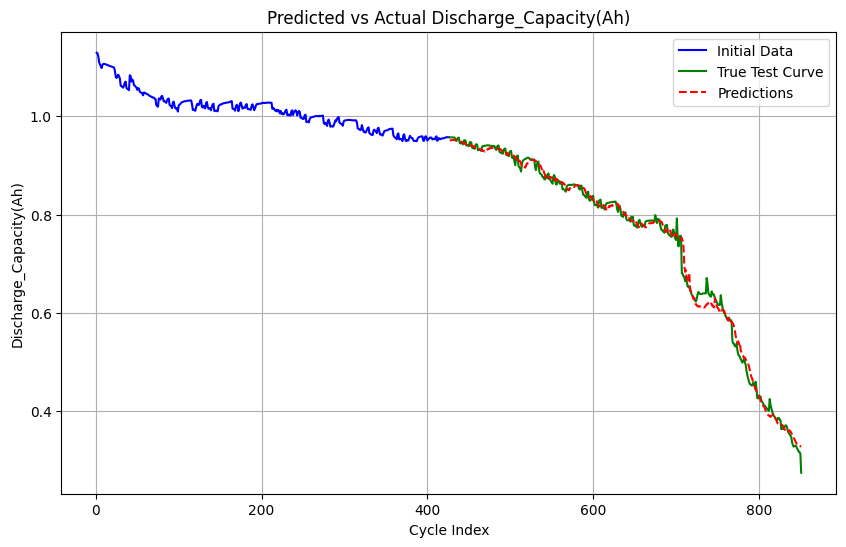

Epoch 1: Validation loss improved to 0.4555571907096439. Model saved!
Epoch 1/50, Train Loss: 0.4983440990958895, Val Loss: 0.4555571907096439
Epoch 2: Validation loss improved to 0.39858994715743595. Model saved!
Epoch 2/50, Train Loss: 0.45344670585223606, Val Loss: 0.39858994715743595
Epoch 3: Validation loss improved to 0.19696014953984153. Model saved!
Epoch 3/50, Train Loss: 0.3287853566663606, Val Loss: 0.19696014953984153
Epoch 4: Validation loss improved to 0.007295030557240049. Model saved!
Epoch 4/50, Train Loss: 0.07823222036074315, Val Loss: 0.007295030557240049
Epoch 5: Validation loss improved to 0.0008039612746668152. Model saved!
Epoch 5/50, Train Loss: 0.002927127926211272, Val Loss: 0.0008039612746668152
Epoch 6: Validation loss improved to 0.0006052379968524394. Model saved!
Epoch 6/50, Train Loss: 0.0008201334159821272, Val Loss: 0.0006052379968524394
Epoch 7: Validation loss improved to 0.000369948356011365. Model saved!
Epoch 7/50, Train Loss: 0.00087075490550237

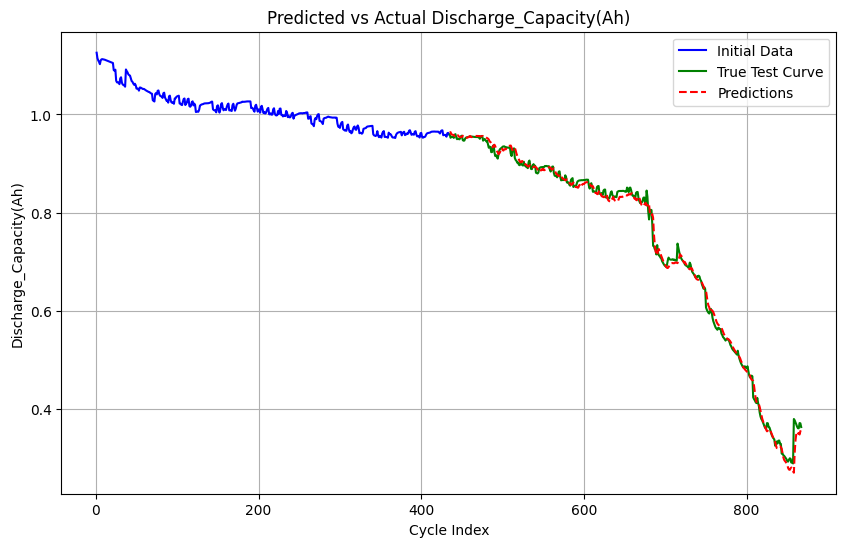

In [27]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model().to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50

    # Training
    train_model(
        model=model_1,
        train_dataloader=CALCE_train_dataloaders_50[i],
        val_dataloader = CALCE_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_50.pth'
    )

    # Evaluation
    model_1.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_50.pth'))
    model_1.to(device)
    
    metrics = evaluate_model(model_1, CALCE_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    # Plotting Curve
    plot_predictions(model_1, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 50)

In [18]:
metrics = evaluate_model(model_1, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.009994705719651886
MAE: 0.007432813782279737


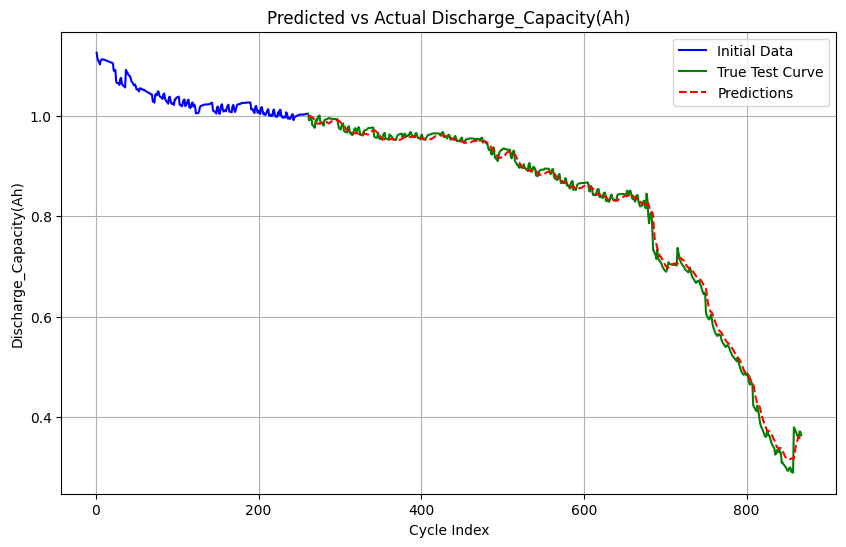

In [19]:
plot_predictions(model_1, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## BiLSTM Attention Model

Epoch 1: Validation loss improved to 0.0017372085233492887. Model saved!
Epoch 1/25, Train Loss: 0.05085480654848489, Val Loss: 0.0017372085233492887
Epoch 2: Validation loss improved to 8.891213056973785e-05. Model saved!
Epoch 2/25, Train Loss: 0.0003019859676584671, Val Loss: 8.891213056973785e-05
Epoch 3: Validation loss improved to 8.060601805268293e-05. Model saved!
Epoch 3/25, Train Loss: 0.00013851019744535407, Val Loss: 8.060601805268293e-05
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00013972265715797696, Val Loss: 0.00011230494141380084
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.0001258828922990647, Val Loss: 8.658847603809965e-05
Epoch 6: Validation loss improved to 7.272063393269062e-05. Model saved!
Epoch 6/25, Train Loss: 0.00013162497151512722, Val Loss: 7.272063393269062e-05
Epoch 7: No improvement. (1/5)
Epoch 7/25, Train Loss: 0.0001375077955521219, Val Loss: 0.00011365097110255567
Epoch 8: No improvement. (2/5)
Epoch 8/25, Train Loss: 0.00

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\846914238.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConstan

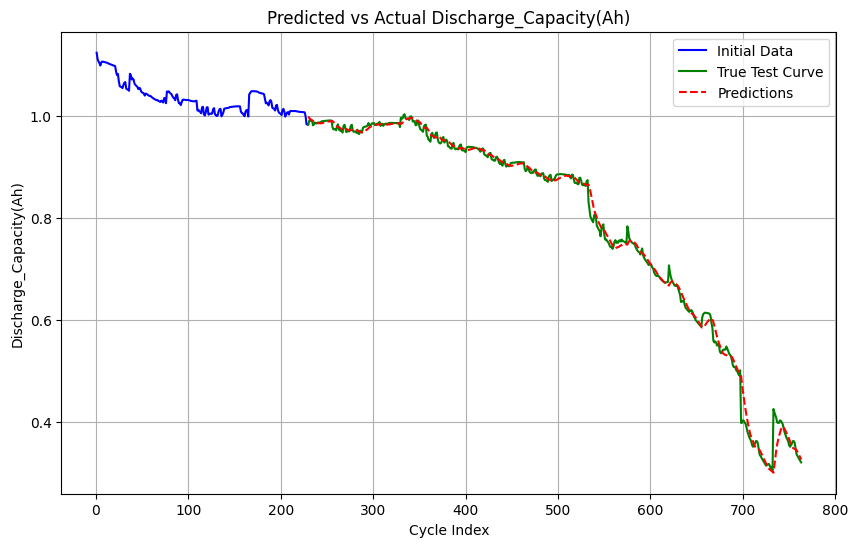

Epoch 1: Validation loss improved to 0.0008879276197951506. Model saved!
Epoch 1/25, Train Loss: 0.0734421297753188, Val Loss: 0.0008879276197951506
Epoch 2: Validation loss improved to 0.00012073311796377632. Model saved!
Epoch 2/25, Train Loss: 0.0002456337172032417, Val Loss: 0.00012073311796377632
Epoch 3: Validation loss improved to 0.00011449353041825816. Model saved!
Epoch 3/25, Train Loss: 0.00012419923500126616, Val Loss: 0.00011449353041825816
Epoch 4: Validation loss improved to 0.00011135541460723343. Model saved!
Epoch 4/25, Train Loss: 0.00012738984835085655, Val Loss: 0.00011135541460723343
Epoch 5: No improvement. (1/5)
Epoch 5/25, Train Loss: 0.00012884053535005356, Val Loss: 0.0001412033392732744
Epoch 6: No improvement. (2/5)
Epoch 6/25, Train Loss: 0.00012163981189777547, Val Loss: 0.00014952583895886645
Epoch 7: Validation loss improved to 0.00010839065833030926. Model saved!
Epoch 7/25, Train Loss: 0.00012378318711147476, Val Loss: 0.00010839065833030926
Epoch 8: 

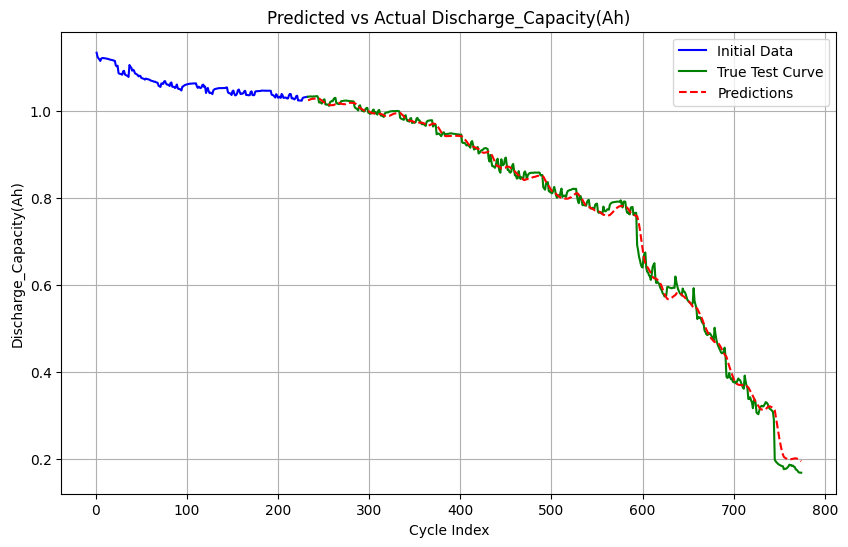

Epoch 1: Validation loss improved to 0.0029692556709051132. Model saved!
Epoch 1/25, Train Loss: 0.06375099214457089, Val Loss: 0.0029692556709051132
Epoch 2: Validation loss improved to 0.0001019582076183082. Model saved!
Epoch 2/25, Train Loss: 0.0005968012315089723, Val Loss: 0.0001019582076183082
Epoch 3: Validation loss improved to 9.984924241400543e-05. Model saved!
Epoch 3/25, Train Loss: 0.00015250892967301434, Val Loss: 9.984924241400543e-05
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.0001545135387321793, Val Loss: 0.0001009484485086218
Epoch 5: Validation loss improved to 9.51537887671935e-05. Model saved!
Epoch 5/25, Train Loss: 0.00014398744629447307, Val Loss: 9.51537887671935e-05
Epoch 6: Validation loss improved to 9.378371439251008e-05. Model saved!
Epoch 6/25, Train Loss: 0.0001433109983102468, Val Loss: 9.378371439251008e-05
Epoch 7: No improvement. (1/5)
Epoch 7/25, Train Loss: 0.00015159710787746448, Val Loss: 0.00011956428566276479
Epoch 8: No improvem

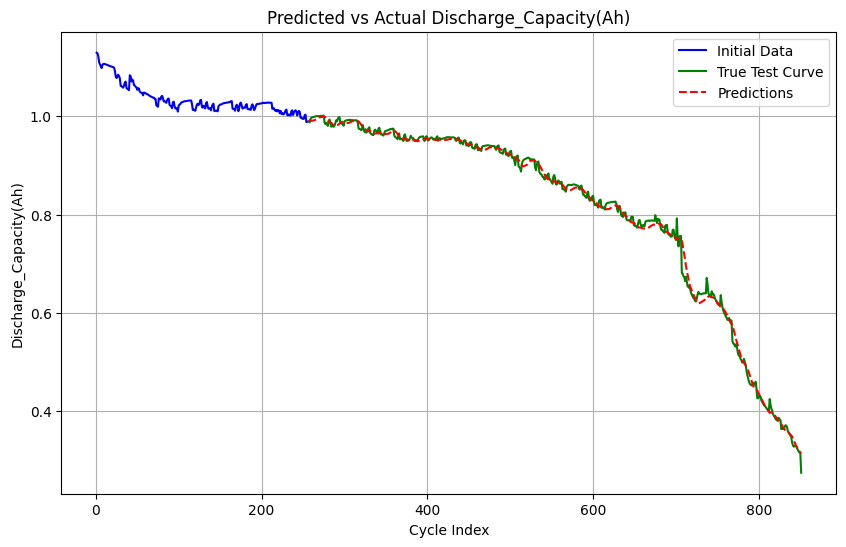

Epoch 1: Validation loss improved to 0.003461619243299698. Model saved!
Epoch 1/25, Train Loss: 0.06909779140683399, Val Loss: 0.003461619243299698
Epoch 2: Validation loss improved to 0.00010726004513665376. Model saved!
Epoch 2/25, Train Loss: 0.000870311215211669, Val Loss: 0.00010726004513665376
Epoch 3: No improvement. (1/5)
Epoch 3/25, Train Loss: 0.00014821060463101745, Val Loss: 0.00010982925895779558
Epoch 4: No improvement. (2/5)
Epoch 4/25, Train Loss: 0.0001390354523623087, Val Loss: 0.0001409398892599925
Epoch 5: No improvement. (3/5)
Epoch 5/25, Train Loss: 0.0001542797062112103, Val Loss: 0.00010978847785736434
Epoch 6: No improvement. (4/5)
Epoch 6/25, Train Loss: 0.00013668203579679053, Val Loss: 0.00013356409801738612
Epoch 7: Validation loss improved to 8.64613864584552e-05. Model saved!
Epoch 7/25, Train Loss: 0.00013287365618452895, Val Loss: 8.64613864584552e-05
Epoch 8: Validation loss improved to 8.595753356263124e-05. Model saved!
Epoch 8/25, Train Loss: 0.0001

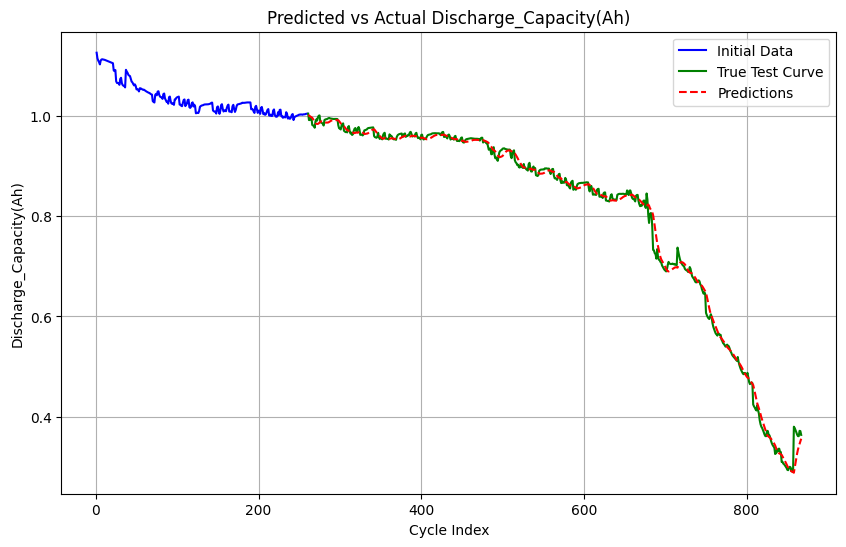

In [38]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 25
    
    train_model(
        model=model_2,
        train_dataloader=CALCE_train_dataloaders_30[i],
        val_dataloader=CALCE_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}_30.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}_30.pth'))
    model_2.to(device)
    
    metrics = evaluate_model(model_2, CALCE_test_dataloaders_30[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 30)

Epoch 1: Validation loss improved to 0.00439506524708122. Model saved!
Epoch 1/25, Train Loss: 0.06880783180142162, Val Loss: 0.00439506524708122
Epoch 2: Validation loss improved to 0.00011274003049442804. Model saved!
Epoch 2/25, Train Loss: 0.0009928484304138282, Val Loss: 0.00011274003049442804
Epoch 3: Validation loss improved to 0.00011025565345335053. Model saved!
Epoch 3/25, Train Loss: 0.00011506761566893211, Val Loss: 0.00011025565345335053
Epoch 4: Validation loss improved to 0.00010862835956181193. Model saved!
Epoch 4/25, Train Loss: 0.00011530203979854262, Val Loss: 0.00010862835956181193
Epoch 5: Validation loss improved to 0.00010549631123366352. Model saved!
Epoch 5/25, Train Loss: 0.00012085048544743675, Val Loss: 0.00010549631123366352
Epoch 6: No improvement. (1/5)
Epoch 6/25, Train Loss: 0.00011882306388940032, Val Loss: 0.00014062291787316403
Epoch 7: No improvement. (2/5)
Epoch 7/25, Train Loss: 0.0001235484351768014, Val Loss: 0.00012992130521322705
Epoch 8: No 

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1109441075.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConsta

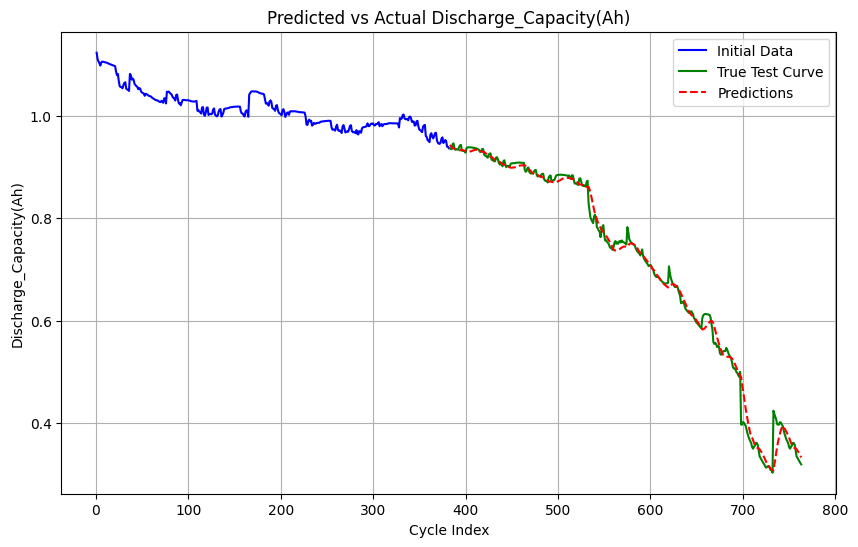

Epoch 1: Validation loss improved to 0.0024546494177128705. Model saved!
Epoch 1/25, Train Loss: 0.05671118460530022, Val Loss: 0.0024546494177128705
Epoch 2: Validation loss improved to 0.00012968245836317592. Model saved!
Epoch 2/25, Train Loss: 0.0004617082243859046, Val Loss: 0.00012968245836317592
Epoch 3: Validation loss improved to 0.00012263557901961677. Model saved!
Epoch 3/25, Train Loss: 0.00011032386070107517, Val Loss: 0.00012263557901961677
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00011983083090277612, Val Loss: 0.00013105865764373448
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.00010402621236108375, Val Loss: 0.00013343874727272324
Epoch 6: No improvement. (3/5)
Epoch 6/25, Train Loss: 0.00011213672180122263, Val Loss: 0.00013924502854933962
Epoch 7: No improvement. (4/5)
Epoch 7/25, Train Loss: 0.00010833443947133123, Val Loss: 0.00019400651945034042
Epoch 8: No improvement. (5/5)
Early stopping triggered. Training stopped.
RMSE: 0.0183932717

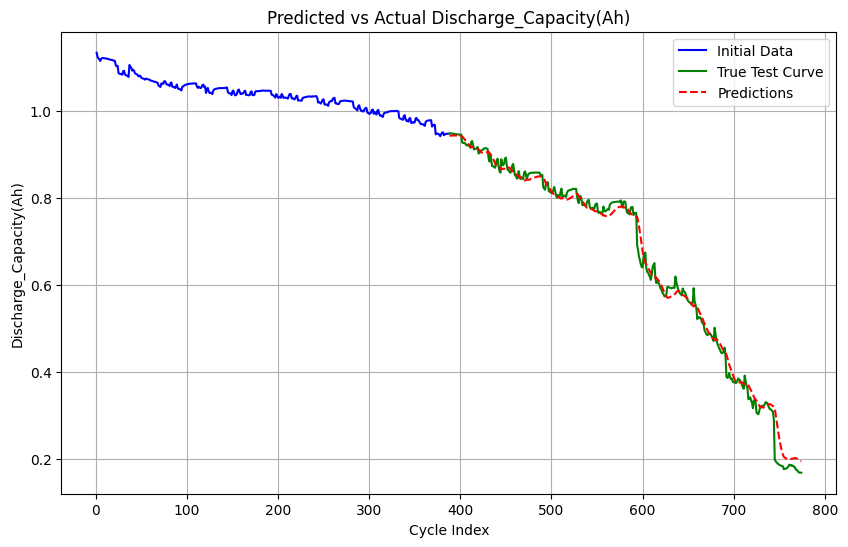

Epoch 1: Validation loss improved to 0.0021416722382936212. Model saved!
Epoch 1/25, Train Loss: 0.050438941506269784, Val Loss: 0.0021416722382936212
Epoch 2: Validation loss improved to 0.00013768898012737432. Model saved!
Epoch 2/25, Train Loss: 0.00037408203845968403, Val Loss: 0.00013768898012737432
Epoch 3: Validation loss improved to 0.00012929659998109046. Model saved!
Epoch 3/25, Train Loss: 0.00014010468226583077, Val Loss: 0.00012929659998109046
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00013299571525879271, Val Loss: 0.00013256208573390418
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.00013531019210079518, Val Loss: 0.00013735386892221868
Epoch 6: No improvement. (3/5)
Epoch 6/25, Train Loss: 0.0001469044389523333, Val Loss: 0.0001346772142925248
Epoch 7: No improvement. (4/5)
Epoch 7/25, Train Loss: 0.00012947740563374412, Val Loss: 0.00015040478117751062
Epoch 8: Validation loss improved to 0.00011863737139113557. Model saved!
Epoch 8/25, Train L

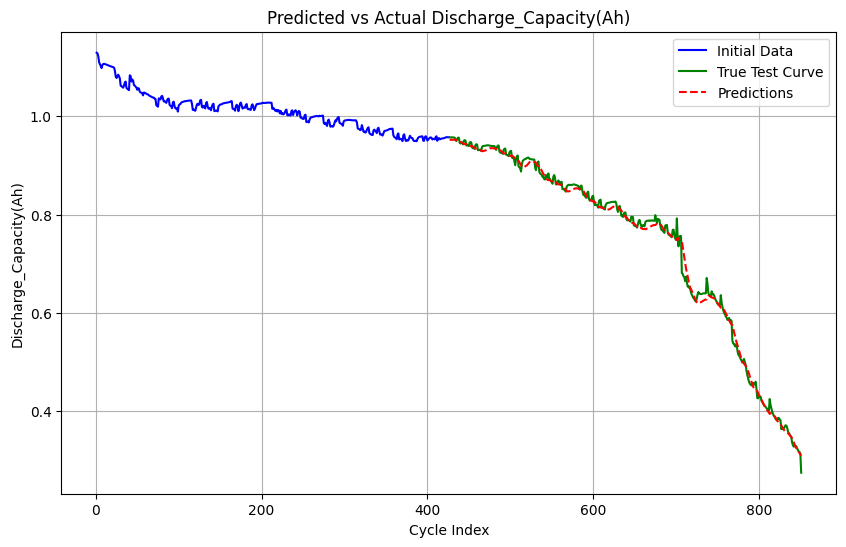

Epoch 1: Validation loss improved to 0.00300872602706982. Model saved!
Epoch 1/25, Train Loss: 0.07639042511083452, Val Loss: 0.00300872602706982
Epoch 2: Validation loss improved to 0.00013364793428788998. Model saved!
Epoch 2/25, Train Loss: 0.0006053629554246851, Val Loss: 0.00013364793428788998
Epoch 3: Validation loss improved to 0.00012715371445261149. Model saved!
Epoch 3/25, Train Loss: 0.00013625221015120458, Val Loss: 0.00012715371445261149
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00014192655778190653, Val Loss: 0.00013312956636784494
Epoch 5: Validation loss improved to 0.00012126530580442502. Model saved!
Epoch 5/25, Train Loss: 0.00012904484969372527, Val Loss: 0.00012126530580442502
Epoch 6: No improvement. (1/5)
Epoch 6/25, Train Loss: 0.00012319002650786257, Val Loss: 0.0001658745572462471
Epoch 7: Validation loss improved to 0.00012070056921705448. Model saved!
Epoch 7/25, Train Loss: 0.00011983757311619618, Val Loss: 0.00012070056921705448
Epoch 8: Val

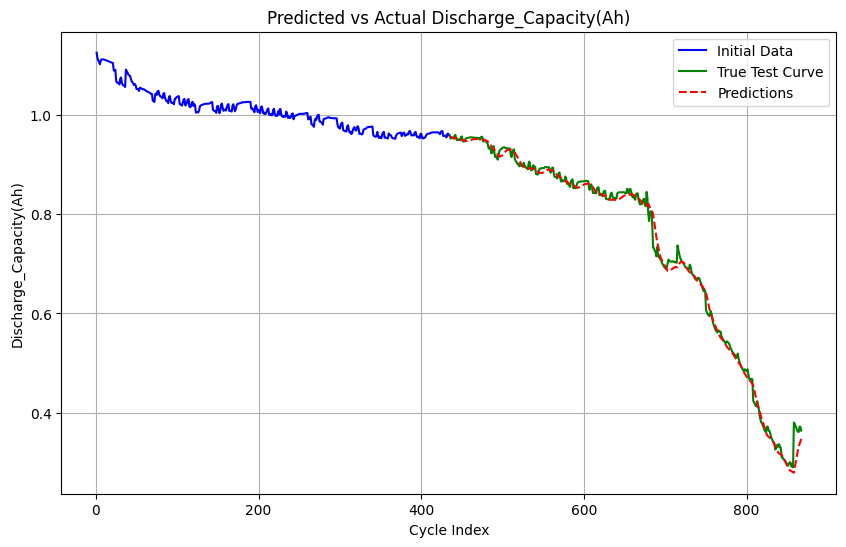

In [29]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 25
    
    train_model(
        model=model_2,
        train_dataloader=CALCE_train_dataloaders_50[i],
        val_dataloader=CALCE_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}_50.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}_50.pth'))
    model_2.to(device)
    
    metrics = evaluate_model(model_2, CALCE_test_dataloaders_50[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 50)

In [44]:
metrics = evaluate_model(model_2, test_dataloader, device, MIN, DIFF, -1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005601538985946446
MAE: 0.0037250833707713634


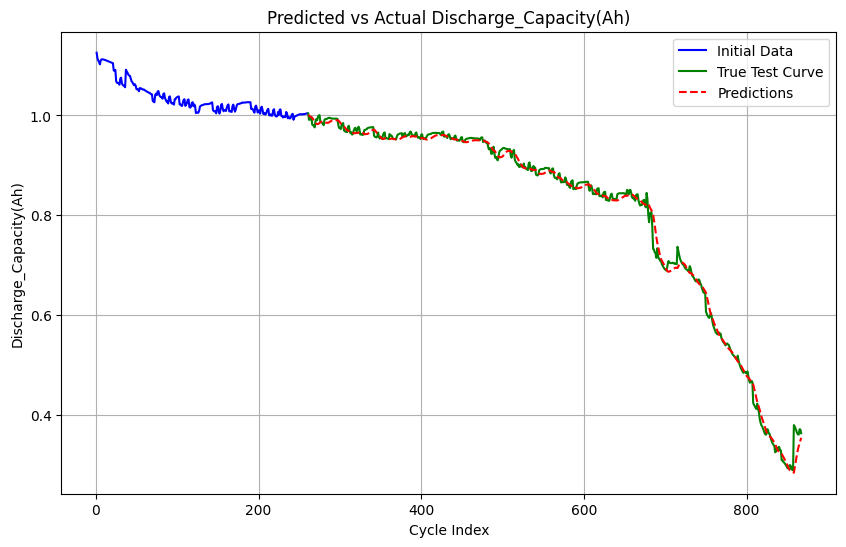

In [45]:
plot_predictions(model_2, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 30)

## ABC (Artificial Bee Colony) BiGRU Model

In [30]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, CALCE_train_dataloaders_30[0], CALCE_val_dataloaders_30[0], device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.0001714340952971457
Iteration 2/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 3/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 4/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 5/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 6/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 7/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 8/20, Best Fitness (MSE): 0.00011489270999685258
Iteration 9/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 10/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 11/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 12/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 13/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 14/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 15/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 16/20, Best Fitness (MSE): 0.00010092162590487587
Iteration 17/20, Best Fitness (MSE): 0.00010092162

Epoch 1: Validation loss improved to 0.005256728433510836. Model saved!
Epoch 1/50, Train Loss: 0.7632805218419699, Val Loss: 0.005256728433510836
Epoch 2: Validation loss improved to 0.0001343152702354607. Model saved!
Epoch 2/50, Train Loss: 0.004489523796503668, Val Loss: 0.0001343152702354607
Epoch 3: Validation loss improved to 0.00012849957077859845. Model saved!
Epoch 3/50, Train Loss: 0.0011248168085507158, Val Loss: 0.00012849957077859845
Epoch 4: No improvement. (1/5)
Epoch 4/50, Train Loss: 0.0012145986026430974, Val Loss: 0.00012859949942246792
Epoch 5: No improvement. (2/5)
Epoch 5/50, Train Loss: 0.0011759990697671006, Val Loss: 0.00013847542098065948
Epoch 6: Validation loss improved to 0.0001234473893418908. Model saved!
Epoch 6/50, Train Loss: 0.001137848695003386, Val Loss: 0.0001234473893418908
Epoch 7: Validation loss improved to 0.00012205232076881016. Model saved!
Epoch 7/50, Train Loss: 0.0011507774618065068, Val Loss: 0.00012205232076881016
Epoch 8: No improveme

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1467838394.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConsta

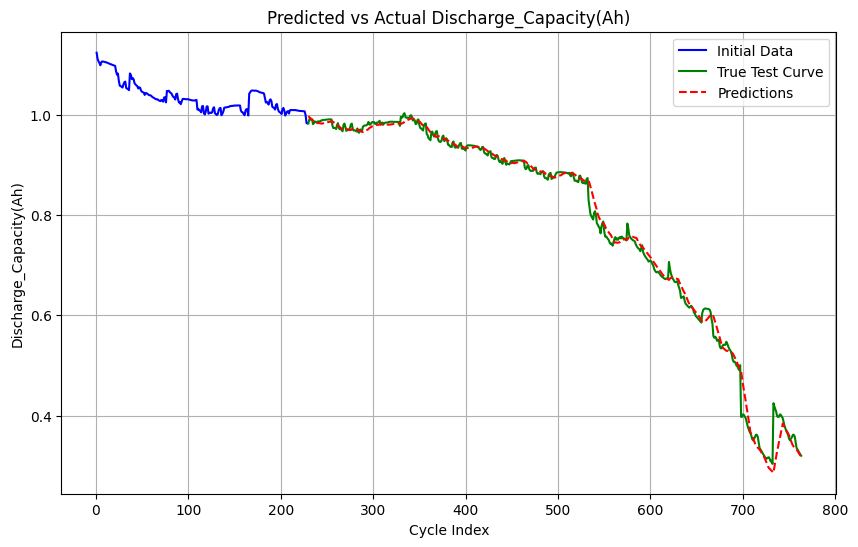

Epoch 1: Validation loss improved to 0.010421396178357741. Model saved!
Epoch 1/50, Train Loss: 1.0748952884546745, Val Loss: 0.010421396178357741
Epoch 2: Validation loss improved to 0.000992907835632864. Model saved!
Epoch 2/50, Train Loss: 0.00904018909726014, Val Loss: 0.000992907835632864
Epoch 3: Validation loss improved to 0.0008045116358998177. Model saved!
Epoch 3/50, Train Loss: 0.002216171214370919, Val Loss: 0.0008045116358998177
Epoch 4: Validation loss improved to 0.0006881860839819317. Model saved!
Epoch 4/50, Train Loss: 0.0022071065440245753, Val Loss: 0.0006881860839819317
Epoch 5: Validation loss improved to 0.0005969571699525285. Model saved!
Epoch 5/50, Train Loss: 0.0020247076693644273, Val Loss: 0.0005969571699525285
Epoch 6: Validation loss improved to 0.0005044232589973356. Model saved!
Epoch 6/50, Train Loss: 0.0019134098556198513, Val Loss: 0.0005044232589973356
Epoch 7: Validation loss improved to 0.00041733408365604086. Model saved!
Epoch 7/50, Train Loss: 

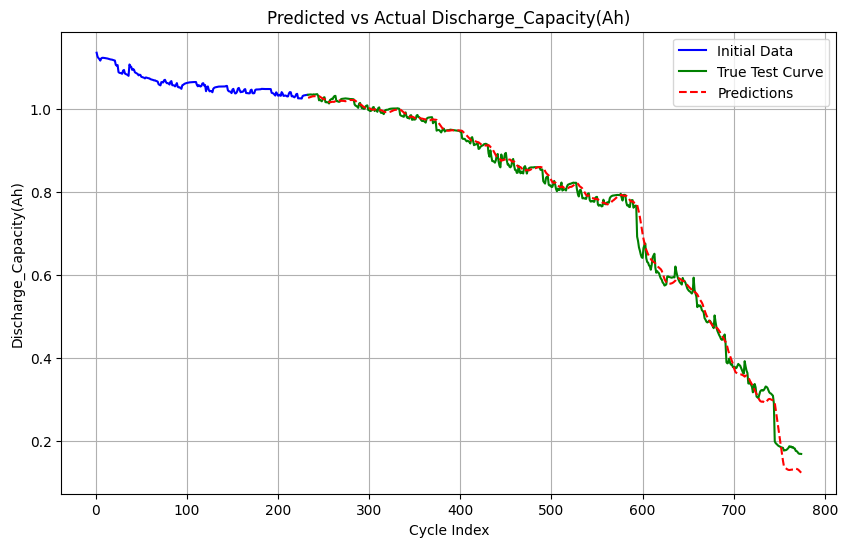

Epoch 1: Validation loss improved to 0.018912989481845322. Model saved!
Epoch 1/50, Train Loss: 0.05011300234632059, Val Loss: 0.018912989481845322
Epoch 2: Validation loss improved to 0.010905754232012174. Model saved!
Epoch 2/50, Train Loss: 0.017976448821806996, Val Loss: 0.010905754232012174
Epoch 3: Validation loss improved to 0.003850674253258416. Model saved!
Epoch 3/50, Train Loss: 0.008523607287894596, Val Loss: 0.003850674253258416
Epoch 4: Validation loss improved to 0.002325700014754308. Model saved!
Epoch 4/50, Train Loss: 0.0044521860060437275, Val Loss: 0.002325700014754308
Epoch 5: Validation loss improved to 0.0019077026372542605. Model saved!
Epoch 5/50, Train Loss: 0.0036117509064779647, Val Loss: 0.0019077026372542605
Epoch 6: Validation loss improved to 0.0016331220651730238. Model saved!
Epoch 6/50, Train Loss: 0.0029675019706535914, Val Loss: 0.0016331220651730238
Epoch 7: Validation loss improved to 0.0014446905843215063. Model saved!
Epoch 7/50, Train Loss: 0.0

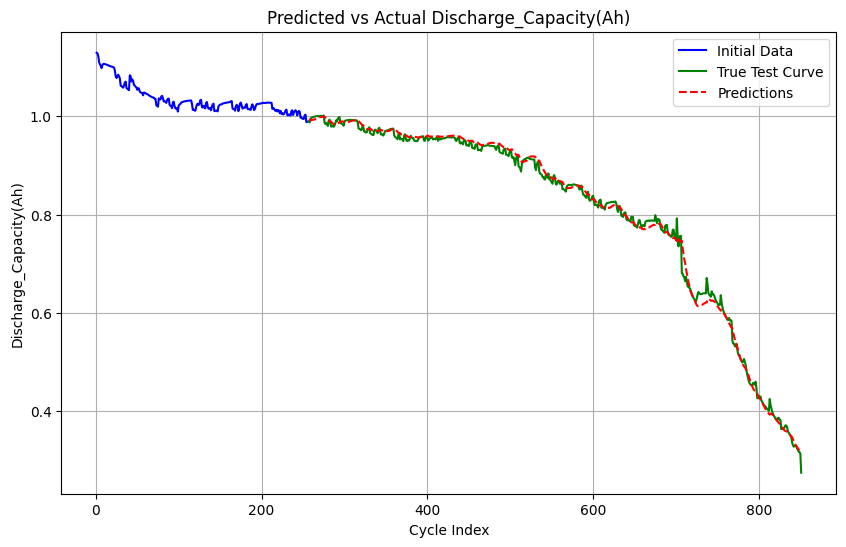

Epoch 1: Validation loss improved to 0.21019145758712993. Model saved!
Epoch 1/50, Train Loss: 0.2474090684995507, Val Loss: 0.21019145758712993
Epoch 2: Validation loss improved to 0.16595632889691522. Model saved!
Epoch 2/50, Train Loss: 0.1890852117177212, Val Loss: 0.16595632889691522
Epoch 3: Validation loss improved to 0.1290708206155721. Model saved!
Epoch 3/50, Train Loss: 0.1474574287280892, Val Loss: 0.1290708206155721
Epoch 4: Validation loss improved to 0.10061126640614342. Model saved!
Epoch 4/50, Train Loss: 0.1144814221470645, Val Loss: 0.10061126640614342
Epoch 5: Validation loss improved to 0.0765328214449041. Model saved!
Epoch 5/50, Train Loss: 0.08779188680152099, Val Loss: 0.0765328214449041
Epoch 6: Validation loss improved to 0.05649024204296224. Model saved!
Epoch 6/50, Train Loss: 0.06680018070972327, Val Loss: 0.05649024204296224
Epoch 7: Validation loss improved to 0.01268051057944403. Model saved!
Epoch 7/50, Train Loss: 0.04579401980013107, Val Loss: 0.0126

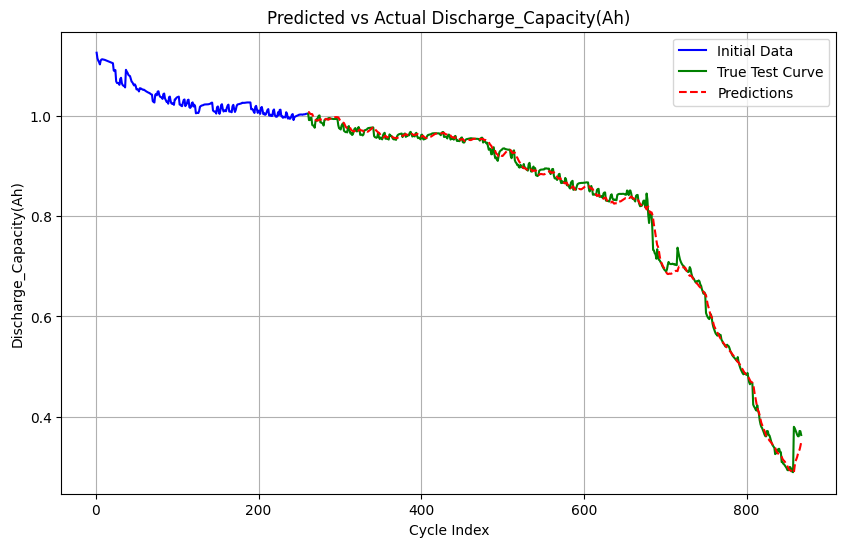

In [31]:

for i in range(4):
    model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    train_model(
        model=model_3,
        train_dataloader=CALCE_train_dataloaders_30[i],
        val_dataloader=CALCE_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}_30.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}_30.pth'))
    model_3.to(device)
    
    metrics = evaluate_model(model_3, CALCE_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [32]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, CALCE_train_dataloaders_50[0], CALCE_val_dataloaders_50[0], device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.0002450336449126351
Iteration 2/20, Best Fitness (MSE): 0.0002450336449126351
Iteration 3/20, Best Fitness (MSE): 0.00023352065990265046
Iteration 4/20, Best Fitness (MSE): 0.00016722159206336882
Iteration 5/20, Best Fitness (MSE): 0.00016722159206336882
Iteration 6/20, Best Fitness (MSE): 0.00016722159206336882
Iteration 7/20, Best Fitness (MSE): 0.00016722159206336882
Iteration 8/20, Best Fitness (MSE): 0.00016722159206336882
Iteration 9/20, Best Fitness (MSE): 0.00015773357639166838
Iteration 10/20, Best Fitness (MSE): 0.00015773357639166838
Iteration 11/20, Best Fitness (MSE): 0.00015773357639166838
Iteration 12/20, Best Fitness (MSE): 0.00015773357639166838
Iteration 13/20, Best Fitness (MSE): 0.00014893474003151318
Iteration 14/20, Best Fitness (MSE): 0.00014893474003151318
Iteration 15/20, Best Fitness (MSE): 0.00014893474003151318
Iteration 16/20, Best Fitness (MSE): 0.00014893474003151318
Iteration 17/20, Best Fitness (MSE): 0.000148934740

Epoch 1: Validation loss improved to 0.008914190085811747. Model saved!
Epoch 1/50, Train Loss: 0.9977575064682677, Val Loss: 0.008914190085811747
Epoch 2: Validation loss improved to 0.0011765194891874369. Model saved!
Epoch 2/50, Train Loss: 0.007617822613790106, Val Loss: 0.0011765194891874369
Epoch 3: Validation loss improved to 0.0009545808821308634. Model saved!
Epoch 3/50, Train Loss: 0.0019498460091532431, Val Loss: 0.0009545808821308634
Epoch 4: Validation loss improved to 0.0008232609317120579. Model saved!
Epoch 4/50, Train Loss: 0.0017922570040239624, Val Loss: 0.0008232609317120579
Epoch 5: Validation loss improved to 0.0006924140891189583. Model saved!
Epoch 5/50, Train Loss: 0.0015858560702173223, Val Loss: 0.0006924140891189583
Epoch 6: Validation loss improved to 0.0005832858898631659. Model saved!
Epoch 6/50, Train Loss: 0.0015657578576946448, Val Loss: 0.0005832858898631659
Epoch 7: Validation loss improved to 0.0005033713184982642. Model saved!
Epoch 7/50, Train Los

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\782537249.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConstan

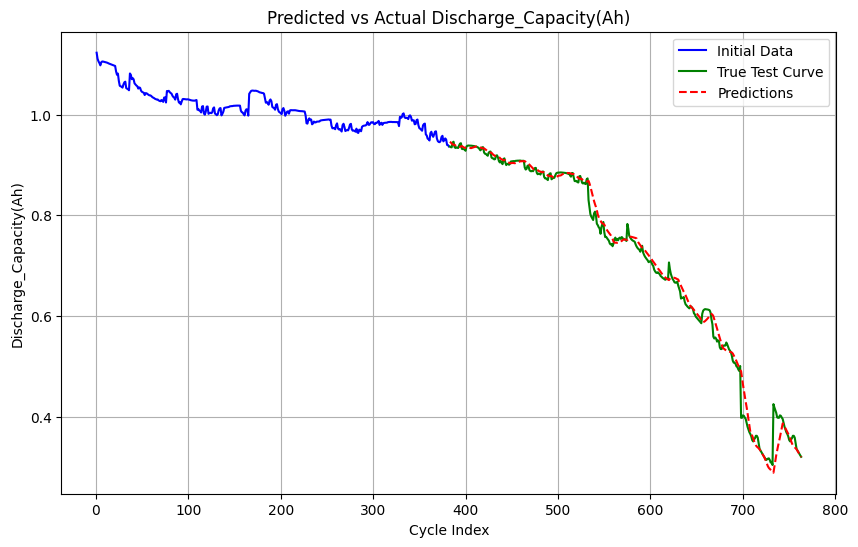

Epoch 1: Validation loss improved to 0.13989567011594772. Model saved!
Epoch 1/50, Train Loss: 0.7731177003031046, Val Loss: 0.13989567011594772
Epoch 2: Validation loss improved to 0.0006818951967741466. Model saved!
Epoch 2/50, Train Loss: 0.012534308726046706, Val Loss: 0.0006818951967741466
Epoch 3: Validation loss improved to 0.0005225670546577829. Model saved!
Epoch 3/50, Train Loss: 0.0011552896721183624, Val Loss: 0.0005225670546577829
Epoch 4: Validation loss improved to 0.00043739822689935356. Model saved!
Epoch 4/50, Train Loss: 0.0010700359904456517, Val Loss: 0.00043739822689935356
Epoch 5: Validation loss improved to 0.0004022290191238022. Model saved!
Epoch 5/50, Train Loss: 0.0010046435841424785, Val Loss: 0.0004022290191238022
Epoch 6: Validation loss improved to 0.0003420603210947269. Model saved!
Epoch 6/50, Train Loss: 0.0009721092761717212, Val Loss: 0.0003420603210947269
Epoch 7: Validation loss improved to 0.0002935775005931242. Model saved!
Epoch 7/50, Train Los

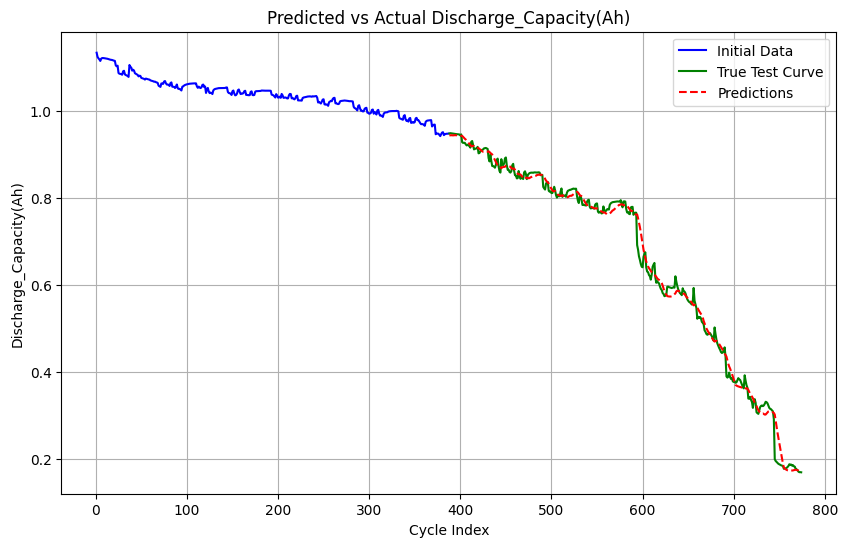

Epoch 1: Validation loss improved to 0.00993869402575203. Model saved!
Epoch 1/50, Train Loss: 0.04188451406412891, Val Loss: 0.00993869402575203
Epoch 2: Validation loss improved to 0.004987506571018862. Model saved!
Epoch 2/50, Train Loss: 0.007688125849901033, Val Loss: 0.004987506571018862
Epoch 3: Validation loss improved to 0.0005456141063607194. Model saved!
Epoch 3/50, Train Loss: 0.002527342800749466, Val Loss: 0.0005456141063607194
Epoch 4: Validation loss improved to 0.00027834336085814156. Model saved!
Epoch 4/50, Train Loss: 0.0005664229426266892, Val Loss: 0.00027834336085814156
Epoch 5: Validation loss improved to 0.00022394480583898257. Model saved!
Epoch 5/50, Train Loss: 0.000499784603847989, Val Loss: 0.00022394480583898257
Epoch 6: Validation loss improved to 0.00021606227467903713. Model saved!
Epoch 6/50, Train Loss: 0.0004505066267613854, Val Loss: 0.00021606227467903713
Epoch 7: Validation loss improved to 0.00019423113523468297. Model saved!
Epoch 7/50, Train L

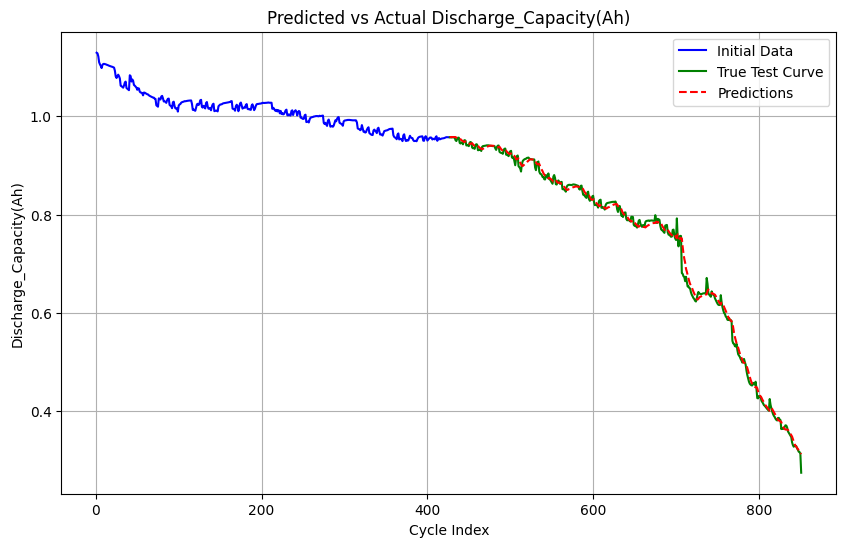

Epoch 1: Validation loss improved to 0.014702760976635747. Model saved!
Epoch 1/50, Train Loss: 0.08006798711472324, Val Loss: 0.014702760976635747
Epoch 2: Validation loss improved to 0.010461568444346389. Model saved!
Epoch 2/50, Train Loss: 0.010939135488920977, Val Loss: 0.010461568444346389
Epoch 3: Validation loss improved to 0.005112748877662752. Model saved!
Epoch 3/50, Train Loss: 0.007046086384382631, Val Loss: 0.005112748877662752
Epoch 4: Validation loss improved to 0.0014095770699592929. Model saved!
Epoch 4/50, Train Loss: 0.002725374140469025, Val Loss: 0.0014095770699592929
Epoch 5: Validation loss improved to 0.00032425882333579165. Model saved!
Epoch 5/50, Train Loss: 0.0007882658595917746, Val Loss: 0.00032425882333579165
Epoch 6: Validation loss improved to 0.00024354247297095653. Model saved!
Epoch 6/50, Train Loss: 0.00048178372713404574, Val Loss: 0.00024354247297095653
Epoch 7: Validation loss improved to 0.000215455695272087. Model saved!
Epoch 7/50, Train Loss

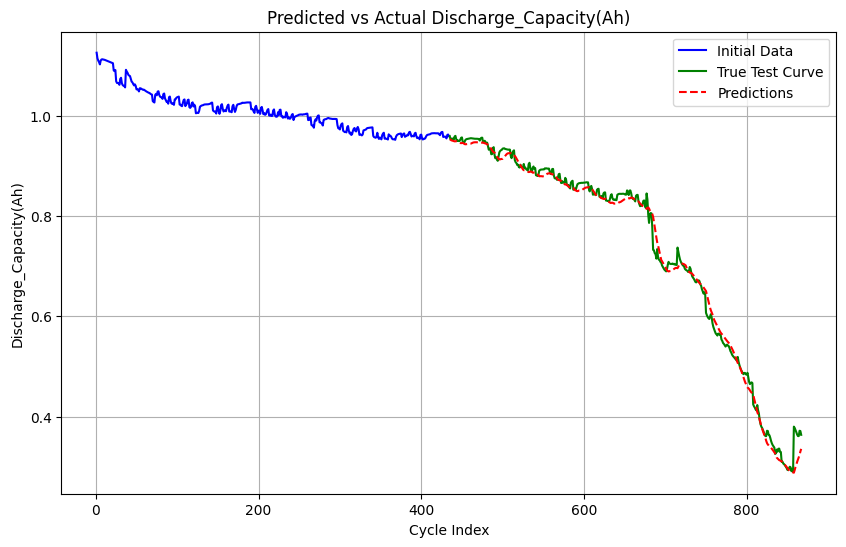

In [33]:

for i in range(4):
    model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    train_model(
        model=model_3,
        train_dataloader=CALCE_train_dataloaders_50[i],
        val_dataloader=CALCE_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}_50.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}_50.pth'))
    model_3.to(device)
    
    metrics = evaluate_model(model_3, CALCE_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 50)

In [48]:
metrics = evaluate_model(model_3, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005899988979855457
MAE: 0.003977795645037544


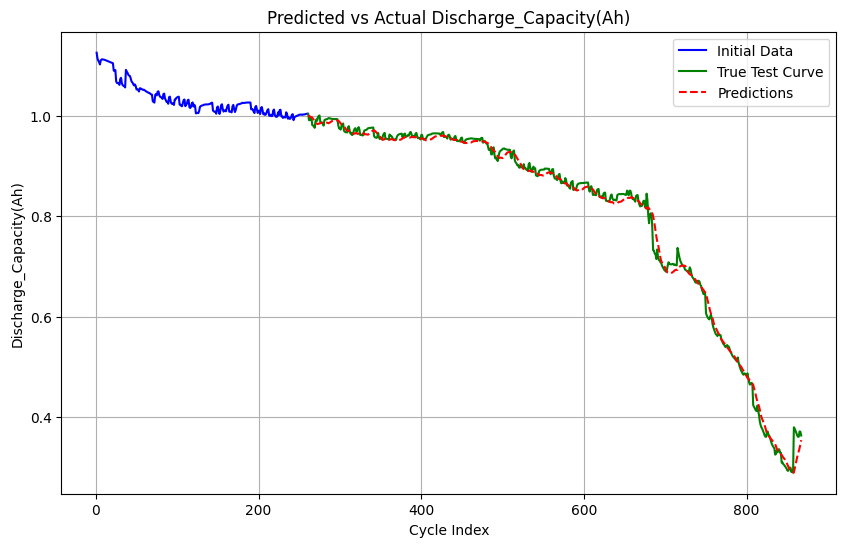

In [49]:
plot_predictions(model_3, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## CNN - DBLSTM Model

Epoch 1: Validation loss improved to 0.0013177454992033104. Model saved!
Epoch 1/50, Train Loss: 0.09094590527212261, Val Loss: 0.0013177454992033104
Epoch 2: Validation loss improved to 0.0005924208312267985. Model saved!
Epoch 2/50, Train Loss: 0.001521882809044397, Val Loss: 0.0005924208312267985
Epoch 3: Validation loss improved to 0.000331881272894166. Model saved!
Epoch 3/50, Train Loss: 0.0009323551446380121, Val Loss: 0.000331881272894166
Epoch 4: Validation loss improved to 0.00017596082676284234. Model saved!
Epoch 4/50, Train Loss: 0.0004978877184486864, Val Loss: 0.00017596082676284234
Epoch 5: No improvement. (1/10)
Epoch 5/50, Train Loss: 0.0006499439644615979, Val Loss: 0.00041021980338401217
Epoch 6: No improvement. (2/10)
Epoch 6/50, Train Loss: 0.0008679001206365317, Val Loss: 0.00045365896692280383
Epoch 7: Validation loss improved to 0.00010939457506003022. Model saved!
Epoch 7/50, Train Loss: 0.00046078232345049644, Val Loss: 0.00010939457506003022
Epoch 8: No impr

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1914441555.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

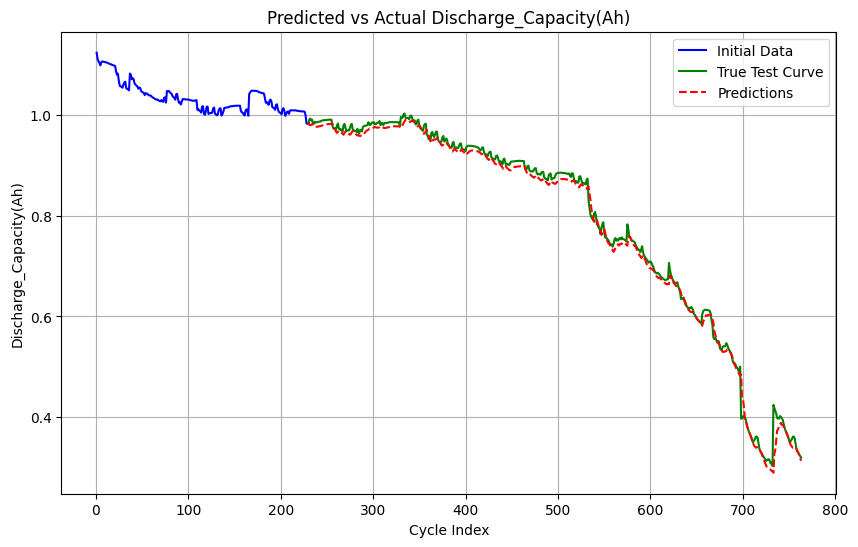

Epoch 1: Validation loss improved to 0.0066394615808830545. Model saved!
Epoch 1/50, Train Loss: 0.15433325757508848, Val Loss: 0.0066394615808830545
Epoch 2: Validation loss improved to 0.0004056967993486015. Model saved!
Epoch 2/50, Train Loss: 0.003234456224434787, Val Loss: 0.0004056967993486015
Epoch 3: Validation loss improved to 0.00013208253179019426. Model saved!
Epoch 3/50, Train Loss: 0.000724420441208588, Val Loss: 0.00013208253179019426
Epoch 4: Validation loss improved to 0.0001193165876697201. Model saved!
Epoch 4/50, Train Loss: 0.0005607114663458805, Val Loss: 0.0001193165876697201
Epoch 5: No improvement. (1/10)
Epoch 5/50, Train Loss: 0.00037084220772402345, Val Loss: 0.00012805487537715475
Epoch 6: No improvement. (2/10)
Epoch 6/50, Train Loss: 0.00038412597278869755, Val Loss: 0.00012505327878684243
Epoch 7: No improvement. (3/10)
Epoch 7/50, Train Loss: 0.0003347990841847156, Val Loss: 0.00024934106006506174
Epoch 8: No improvement. (4/10)
Epoch 8/50, Train Loss: 

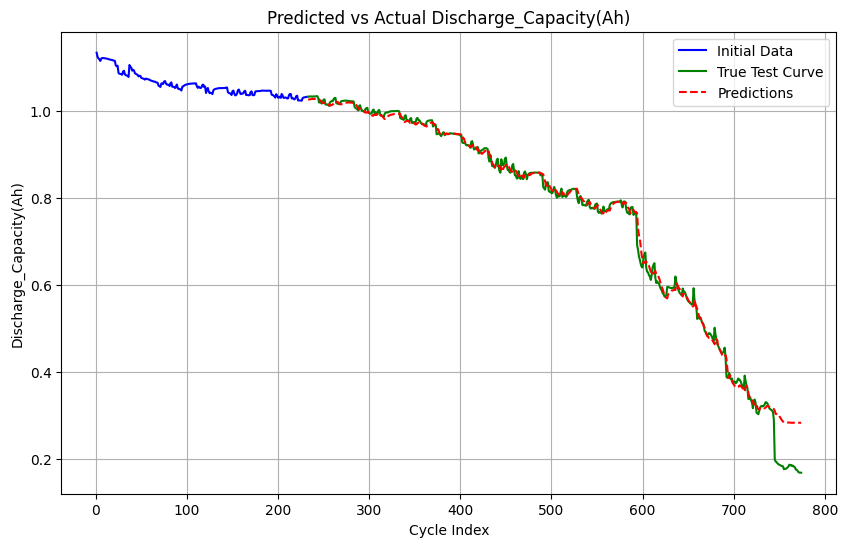

Epoch 1: Validation loss improved to 0.0006389100898933761. Model saved!
Epoch 1/50, Train Loss: 0.05364527288916041, Val Loss: 0.0006389100898933761
Epoch 2: Validation loss improved to 0.00042237513116560876. Model saved!
Epoch 2/50, Train Loss: 0.0015457716213087692, Val Loss: 0.00042237513116560876
Epoch 3: Validation loss improved to 0.00012745352775228266. Model saved!
Epoch 3/50, Train Loss: 0.0004901921545917338, Val Loss: 0.00012745352775228266
Epoch 4: No improvement. (1/10)
Epoch 4/50, Train Loss: 0.00033393398839645227, Val Loss: 0.00031006396217408646
Epoch 5: No improvement. (2/10)
Epoch 5/50, Train Loss: 0.0005601645628882001, Val Loss: 0.00020658048229319428
Epoch 6: No improvement. (3/10)
Epoch 6/50, Train Loss: 0.00083703452401096, Val Loss: 0.000339071499183774
Epoch 7: Validation loss improved to 9.589589022010948e-05. Model saved!
Epoch 7/50, Train Loss: 0.00044095920075602464, Val Loss: 9.589589022010948e-05
Epoch 8: Validation loss improved to 8.547626374125043e-

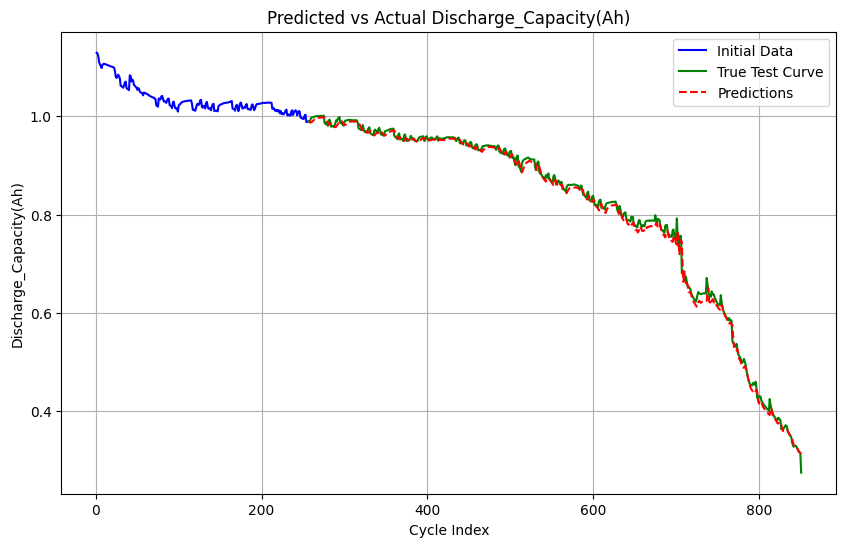

Epoch 1: Validation loss improved to 0.005274131948895314. Model saved!
Epoch 1/50, Train Loss: 0.1315294159787961, Val Loss: 0.005274131948895314
Epoch 2: Validation loss improved to 0.0006021011932342149. Model saved!
Epoch 2/50, Train Loss: 0.0029319549159316175, Val Loss: 0.0006021011932342149
Epoch 3: Validation loss improved to 0.0002152088692288517. Model saved!
Epoch 3/50, Train Loss: 0.0014802910723532973, Val Loss: 0.0002152088692288517
Epoch 4: No improvement. (1/10)
Epoch 4/50, Train Loss: 0.0013937601783475134, Val Loss: 0.0010414019343443215
Epoch 5: Validation loss improved to 0.00010304504351498669. Model saved!
Epoch 5/50, Train Loss: 0.000579478773447177, Val Loss: 0.00010304504351498669
Epoch 6: No improvement. (1/10)
Epoch 6/50, Train Loss: 0.0009187666957697013, Val Loss: 0.0008143099839799106
Epoch 7: Validation loss improved to 7.590526900671916e-05. Model saved!
Epoch 7/50, Train Loss: 0.0006377790558128089, Val Loss: 7.590526900671916e-05
Epoch 8: No improvemen

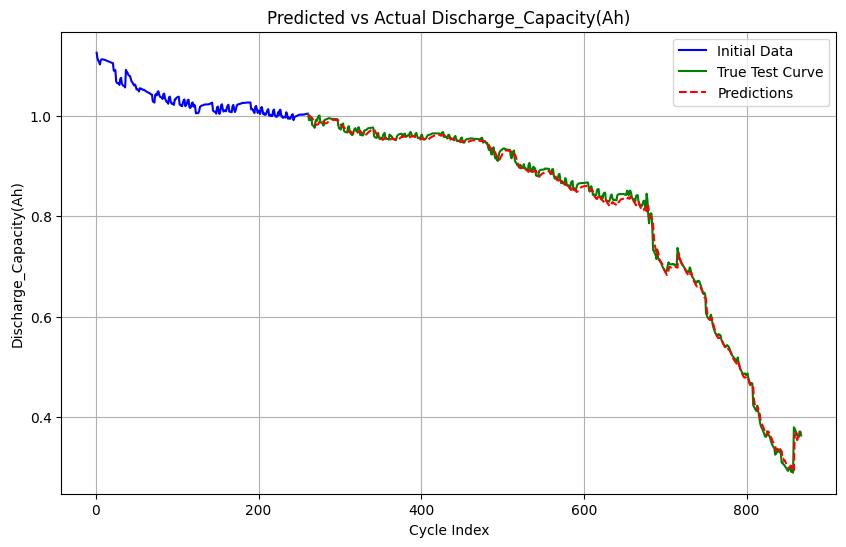

In [40]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters())
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_4,
        train_dataloader=CALCE_train_dataloaders_30[i],
        val_dataloader=CALCE_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}_30.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}_30.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, CALCE_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

Epoch 1: Validation loss improved to 0.0006668937065923172. Model saved!
Epoch 1/50, Train Loss: 0.059452957083458005, Val Loss: 0.0006668937065923172
Epoch 2: Validation loss improved to 0.00016649672195651673. Model saved!
Epoch 2/50, Train Loss: 0.0008893247077267774, Val Loss: 0.00016649672195651673
Epoch 3: No improvement. (1/10)
Epoch 3/50, Train Loss: 0.0004352651965643712, Val Loss: 0.00021562187571867576
Epoch 4: No improvement. (2/10)
Epoch 4/50, Train Loss: 0.000555522607587783, Val Loss: 0.00021526786440517753
Epoch 5: No improvement. (3/10)
Epoch 5/50, Train Loss: 0.00044427380081787574, Val Loss: 0.0002417744197171285
Epoch 6: No improvement. (4/10)
Epoch 6/50, Train Loss: 0.0006981725366618058, Val Loss: 0.0003596602570420752
Epoch 7: No improvement. (5/10)
Epoch 7/50, Train Loss: 0.0005115602985491753, Val Loss: 0.001085240319500574
Epoch 8: Validation loss improved to 0.00013960411848125255. Model saved!
Epoch 8/50, Train Loss: 0.0007058204250632782, Val Loss: 0.000139

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2998600537.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

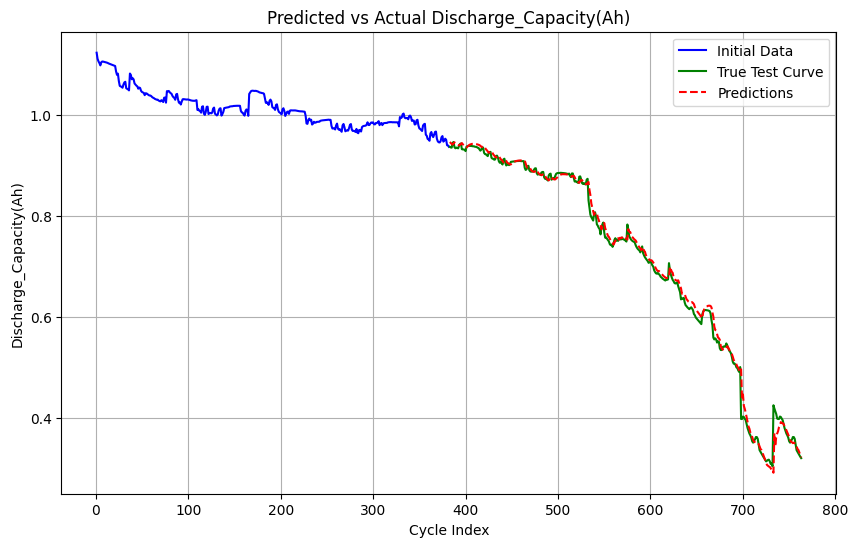

Epoch 1: Validation loss improved to 0.00409460861960219. Model saved!
Epoch 1/50, Train Loss: 0.1294909971110313, Val Loss: 0.00409460861960219
Epoch 2: Validation loss improved to 0.0007365804986976501. Model saved!
Epoch 2/50, Train Loss: 0.002273475557801799, Val Loss: 0.0007365804986976501
Epoch 3: Validation loss improved to 0.0003698632717714645. Model saved!
Epoch 3/50, Train Loss: 0.0009049322446078574, Val Loss: 0.0003698632717714645
Epoch 4: Validation loss improved to 0.00028126086221568077. Model saved!
Epoch 4/50, Train Loss: 0.0007441944069053624, Val Loss: 0.00028126086221568077
Epoch 5: No improvement. (1/10)
Epoch 5/50, Train Loss: 0.0004704716013011549, Val Loss: 0.0002904081516640468
Epoch 6: Validation loss improved to 0.00013745538045542262. Model saved!
Epoch 6/50, Train Loss: 0.00045194239636414196, Val Loss: 0.00013745538045542262
Epoch 7: No improvement. (1/10)
Epoch 7/50, Train Loss: 0.000632953785895206, Val Loss: 0.00048684719755935174
Epoch 8: No improveme

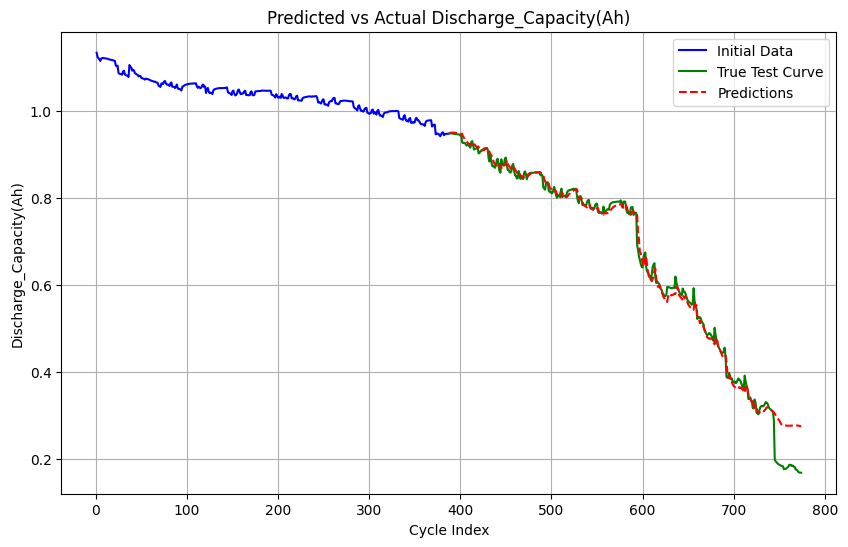

Epoch 1: Validation loss improved to 0.001520004256033442. Model saved!
Epoch 1/50, Train Loss: 0.04232122976848456, Val Loss: 0.001520004256033442
Epoch 2: Validation loss improved to 0.0006757169208463489. Model saved!
Epoch 2/50, Train Loss: 0.0013103893860326415, Val Loss: 0.0006757169208463489
Epoch 3: No improvement. (1/10)
Epoch 3/50, Train Loss: 0.0005911157172314623, Val Loss: 0.0006938255780066053
Epoch 4: Validation loss improved to 0.000467535433320639. Model saved!
Epoch 4/50, Train Loss: 0.0008717799428268336, Val Loss: 0.000467535433320639
Epoch 5: Validation loss improved to 0.00013122675752836384. Model saved!
Epoch 5/50, Train Loss: 0.0006289881661879397, Val Loss: 0.00013122675752836384
Epoch 6: No improvement. (1/10)
Epoch 6/50, Train Loss: 0.00036483311050687915, Val Loss: 0.0002566643278340861
Epoch 7: No improvement. (2/10)
Epoch 7/50, Train Loss: 0.0005225078654413145, Val Loss: 0.0003680740046547726
Epoch 8: No improvement. (3/10)
Epoch 8/50, Train Loss: 0.0003

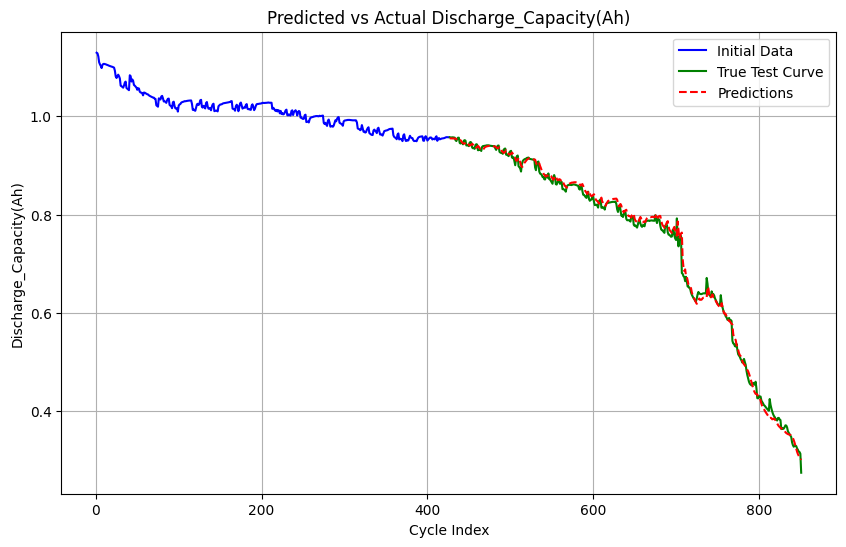

Epoch 1: Validation loss improved to 0.0003890719381161034. Model saved!
Epoch 1/50, Train Loss: 0.02707712694734385, Val Loss: 0.0003890719381161034
Epoch 2: No improvement. (1/10)
Epoch 2/50, Train Loss: 0.0007197804123799349, Val Loss: 0.0007629134553200048
Epoch 3: Validation loss improved to 0.00034173868981371116. Model saved!
Epoch 3/50, Train Loss: 0.000934874116813132, Val Loss: 0.00034173868981371116
Epoch 4: Validation loss improved to 0.00027515155023946945. Model saved!
Epoch 4/50, Train Loss: 0.0006496843987926175, Val Loss: 0.00027515155023946945
Epoch 5: Validation loss improved to 0.00022428272111735877. Model saved!
Epoch 5/50, Train Loss: 0.0007790261109351247, Val Loss: 0.00022428272111735877
Epoch 6: No improvement. (1/10)
Epoch 6/50, Train Loss: 0.0005754664953980995, Val Loss: 0.0002418828870658116
Epoch 7: No improvement. (2/10)
Epoch 7/50, Train Loss: 0.00048165114692112965, Val Loss: 0.0005237219544748465
Epoch 8: No improvement. (3/10)
Epoch 8/50, Train Loss:

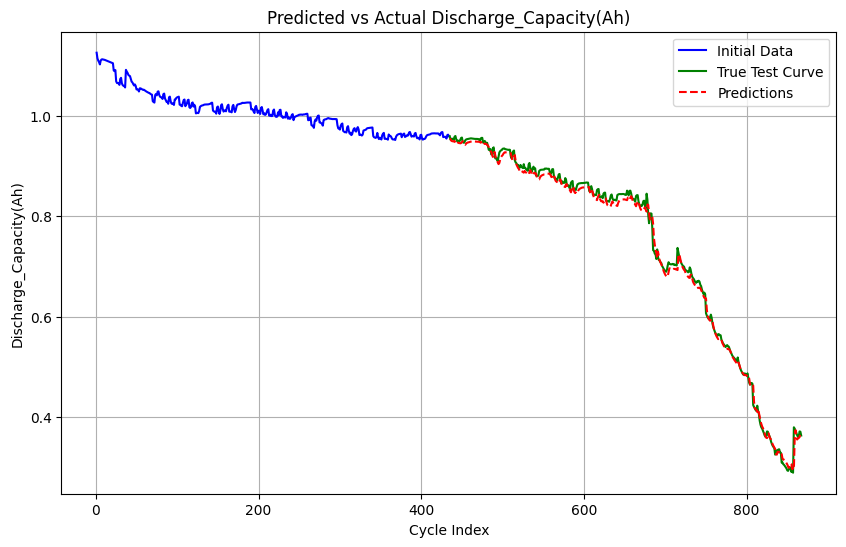

In [42]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters())
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_4,
        train_dataloader=CALCE_train_dataloaders_50[i],
        val_dataloader=CALCE_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}_50.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}_50.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, CALCE_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 50)

In [51]:
metrics = evaluate_model(model_4, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005643505035701092
MAE: 0.003953174975152327


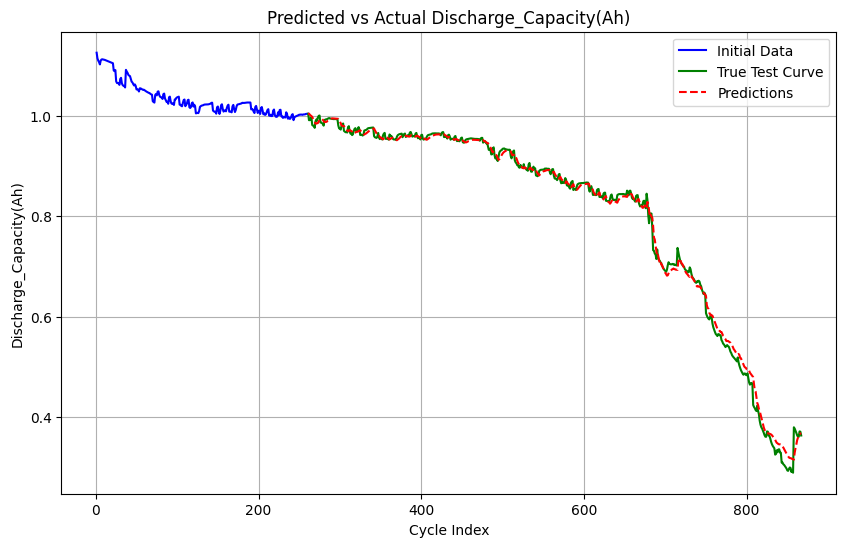

In [52]:
plot_predictions(model_4, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## CNN - ASTLSTM

Epoch 1: Validation loss improved to 0.07202352451927521. Model saved!
Epoch 1/50, Train Loss: 0.27074881031442044, Val Loss: 0.07202352451927521
Epoch 2: Validation loss improved to 0.019838659531053376. Model saved!
Epoch 2/50, Train Loss: 0.034015417863517555, Val Loss: 0.019838659531053376
Epoch 3: Validation loss improved to 0.014847974128582898. Model saved!
Epoch 3/50, Train Loss: 0.01683156069284722, Val Loss: 0.014847974128582898
Epoch 4: Validation loss improved to 0.011463442461236435. Model saved!
Epoch 4/50, Train Loss: 0.013012534028280582, Val Loss: 0.011463442461236435
Epoch 5: Validation loss improved to 0.00855012603706735. Model saved!
Epoch 5/50, Train Loss: 0.009974579736868392, Val Loss: 0.00855012603706735
Epoch 6: Validation loss improved to 0.006264117327244843. Model saved!
Epoch 6/50, Train Loss: 0.00727102223352821, Val Loss: 0.006264117327244843
Epoch 7: Validation loss improved to 0.004387354053666487. Model saved!
Epoch 7/50, Train Loss: 0.005118338877696

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2413496159.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.01712156270915154
MAE: 0.011055946293222995


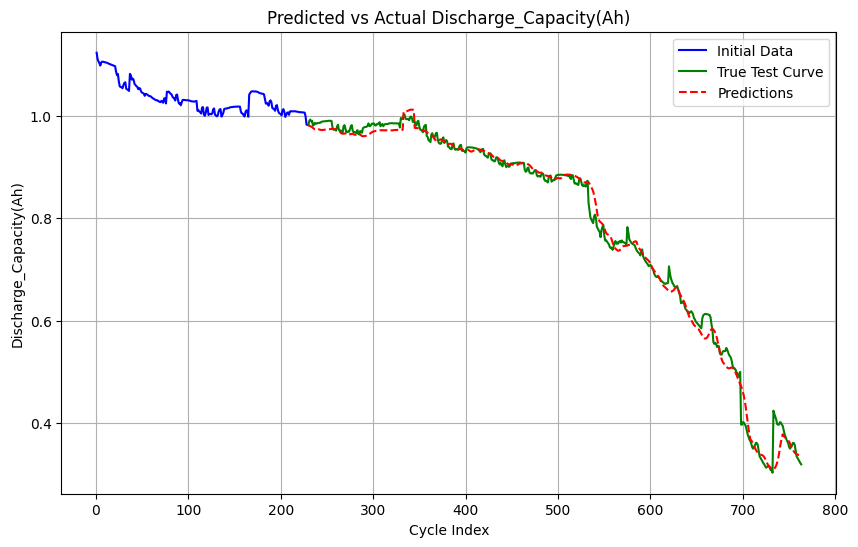

Epoch 1: Validation loss improved to 0.48449236505171833. Model saved!
Epoch 1/50, Train Loss: 0.6333385652570582, Val Loss: 0.48449236505171833
Epoch 2: Validation loss improved to 0.27726225730250864. Model saved!
Epoch 2/50, Train Loss: 0.3745213804849938, Val Loss: 0.27726225730250864
Epoch 3: Validation loss improved to 0.12074669056078967. Model saved!
Epoch 3/50, Train Loss: 0.19448359477431026, Val Loss: 0.12074669056078967
Epoch 4: Validation loss improved to 0.04022367912180284. Model saved!
Epoch 4/50, Train Loss: 0.07123702286339517, Val Loss: 0.04022367912180284
Epoch 5: Validation loss improved to 0.0313676925485625. Model saved!
Epoch 5/50, Train Loss: 0.03405646515537554, Val Loss: 0.0313676925485625
Epoch 6: Validation loss improved to 0.03128410985364633. Model saved!
Epoch 6/50, Train Loss: 0.031613925888912, Val Loss: 0.03128410985364633
Epoch 7: Validation loss improved to 0.031133404604214078. Model saved!
Epoch 7/50, Train Loss: 0.0315116456251091, Val Loss: 0.03

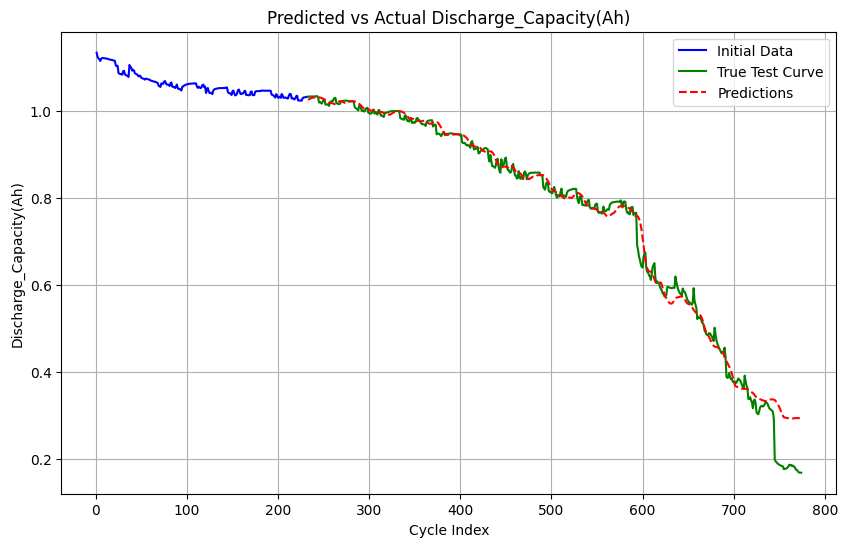

Epoch 1: Validation loss improved to 0.11939272372161641. Model saved!
Epoch 1/50, Train Loss: 0.2138106445922996, Val Loss: 0.11939272372161641
Epoch 2: Validation loss improved to 0.04233980376054259. Model saved!
Epoch 2/50, Train Loss: 0.06950980464391636, Val Loss: 0.04233980376054259
Epoch 3: Validation loss improved to 0.03381856410380672. Model saved!
Epoch 3/50, Train Loss: 0.0403383532821229, Val Loss: 0.03381856410380672
Epoch 4: Validation loss improved to 0.033419049509307915. Model saved!
Epoch 4/50, Train Loss: 0.03856760514617869, Val Loss: 0.033419049509307915
Epoch 5: Validation loss improved to 0.029662326800034326. Model saved!
Epoch 5/50, Train Loss: 0.036621221228305134, Val Loss: 0.029662326800034326
Epoch 6: Validation loss improved to 0.024336513405775324. Model saved!
Epoch 6/50, Train Loss: 0.030945513115236252, Val Loss: 0.024336513405775324
Epoch 7: Validation loss improved to 0.010431395569706665. Model saved!
Epoch 7/50, Train Loss: 0.0193394927138632, Va

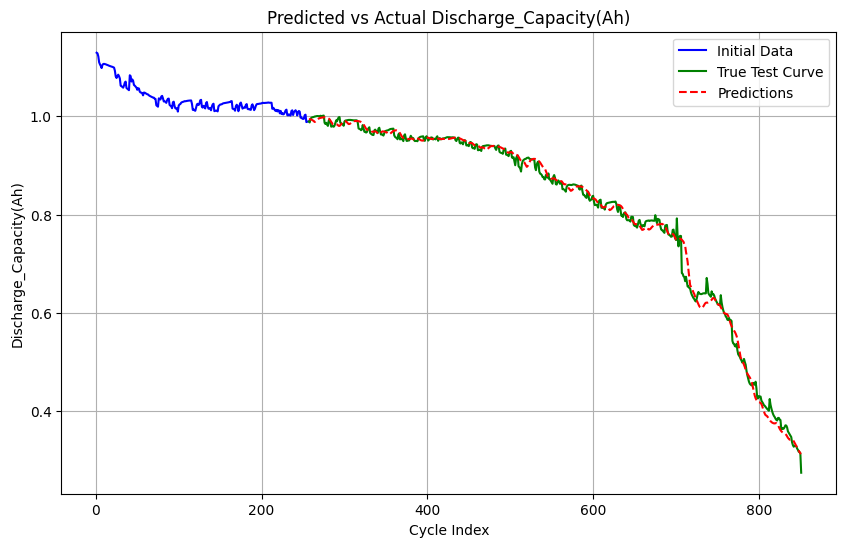

Epoch 1: Validation loss improved to 0.49827342173632455. Model saved!
Epoch 1/50, Train Loss: 0.6208920244014624, Val Loss: 0.49827342173632455
Epoch 2: Validation loss improved to 0.32849398430655985. Model saved!
Epoch 2/50, Train Loss: 0.41074595803564246, Val Loss: 0.32849398430655985
Epoch 3: Validation loss improved to 0.22844549750580506. Model saved!
Epoch 3/50, Train Loss: 0.27334381809288805, Val Loss: 0.22844549750580506
Epoch 4: Validation loss improved to 0.14493821429855683. Model saved!
Epoch 4/50, Train Loss: 0.186781362602205, Val Loss: 0.14493821429855683
Epoch 5: Validation loss improved to 0.07380148593117208. Model saved!
Epoch 5/50, Train Loss: 0.10861171409487724, Val Loss: 0.07380148593117208
Epoch 6: Validation loss improved to 0.04225097158375908. Model saved!
Epoch 6/50, Train Loss: 0.05315597685561939, Val Loss: 0.04225097158375908
Epoch 7: Validation loss improved to 0.03515906894908232. Model saved!
Epoch 7/50, Train Loss: 0.0365417325220099, Val Loss: 0.

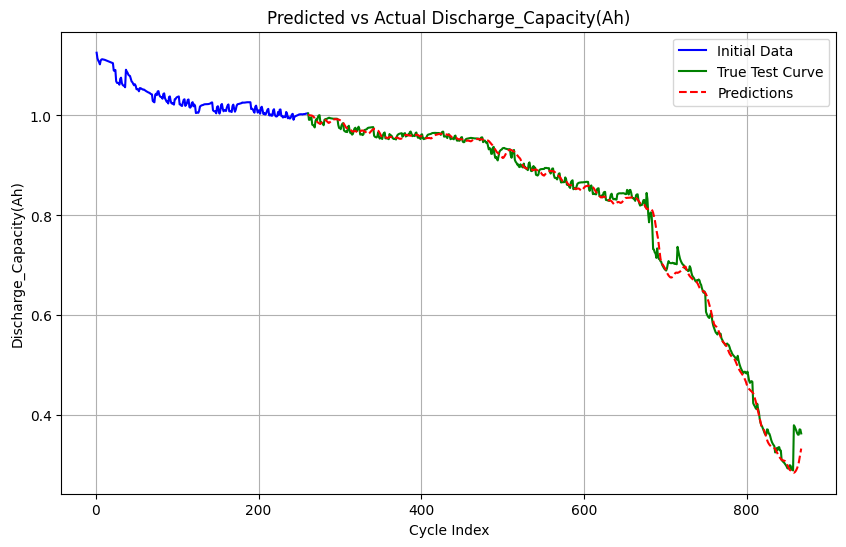

In [47]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_5,
        train_dataloader=CALCE_train_dataloaders_30[i],
        val_dataloader=CALCE_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_30.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_30.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, CALCE_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

Epoch 1: Validation loss improved to 0.035838783201244145. Model saved!
Epoch 1/50, Train Loss: 0.08673042801379317, Val Loss: 0.035838783201244145
Epoch 2: Validation loss improved to 0.03281945476515426. Model saved!
Epoch 2/50, Train Loss: 0.03357315483227582, Val Loss: 0.03281945476515426
Epoch 3: Validation loss improved to 0.031276041020949684. Model saved!
Epoch 3/50, Train Loss: 0.03213066125000027, Val Loss: 0.031276041020949684
Epoch 4: Validation loss improved to 0.020060943025681708. Model saved!
Epoch 4/50, Train Loss: 0.02672966921203573, Val Loss: 0.020060943025681708
Epoch 5: Validation loss improved to 0.0003389534031157382. Model saved!
Epoch 5/50, Train Loss: 0.006421627018426079, Val Loss: 0.0003389534031157382
Epoch 6: Validation loss improved to 0.00027567882231475477. Model saved!
Epoch 6/50, Train Loss: 0.0002698694208422085, Val Loss: 0.00027567882231475477
Epoch 7: Validation loss improved to 0.00024820364160405006. Model saved!
Epoch 7/50, Train Loss: 0.00022

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1123361552.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConsta

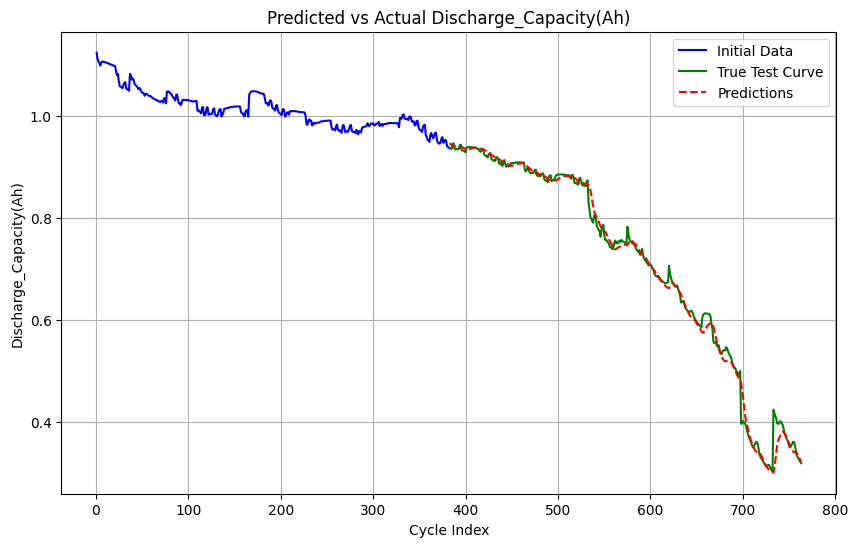

Epoch 1: Validation loss improved to 0.032852645652989544. Model saved!
Epoch 1/50, Train Loss: 0.1334953503552037, Val Loss: 0.032852645652989544
Epoch 2: Validation loss improved to 0.03142621678610643. Model saved!
Epoch 2/50, Train Loss: 0.02989896348821865, Val Loss: 0.03142621678610643
Epoch 3: Validation loss improved to 0.02302346725223793. Model saved!
Epoch 3/50, Train Loss: 0.02587038172330235, Val Loss: 0.02302346725223793
Epoch 4: Validation loss improved to 0.0011003767754623874. Model saved!
Epoch 4/50, Train Loss: 0.011875517281841382, Val Loss: 0.0011003767754623874
Epoch 5: Validation loss improved to 0.000534027538378723. Model saved!
Epoch 5/50, Train Loss: 0.0006566954035521813, Val Loss: 0.000534027538378723
Epoch 6: Validation loss improved to 0.0003334848386455431. Model saved!
Epoch 6/50, Train Loss: 0.0003659828977157611, Val Loss: 0.0003334848386455431
Epoch 7: Validation loss improved to 0.0002590540542668249. Model saved!
Epoch 7/50, Train Loss: 0.000257581

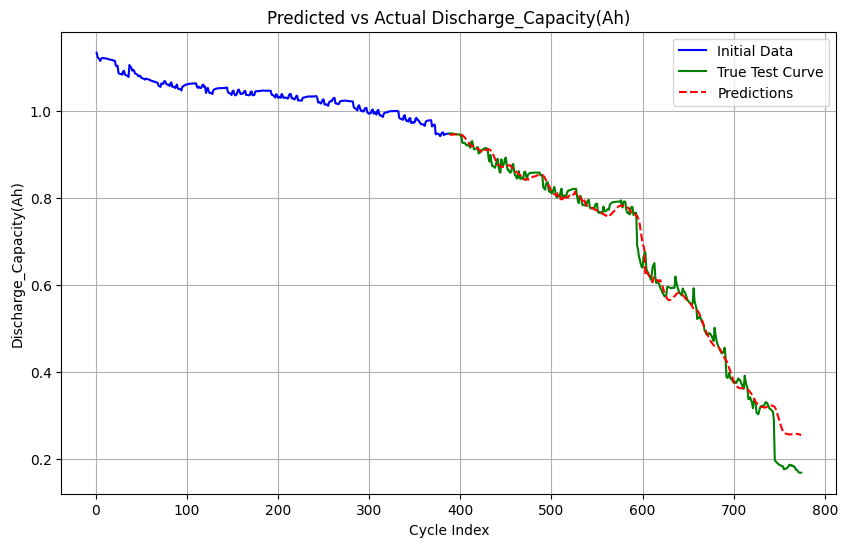

Epoch 1: Validation loss improved to 0.1489174904094802. Model saved!
Epoch 1/50, Train Loss: 0.33899018211024146, Val Loss: 0.1489174904094802
Epoch 2: Validation loss improved to 0.035542812612321645. Model saved!
Epoch 2/50, Train Loss: 0.054752692447177, Val Loss: 0.035542812612321645
Epoch 3: Validation loss improved to 0.03470906832565864. Model saved!
Epoch 3/50, Train Loss: 0.03398324166025434, Val Loss: 0.03470906832565864
Epoch 4: Validation loss improved to 0.02671365724462602. Model saved!
Epoch 4/50, Train Loss: 0.03019769395302449, Val Loss: 0.02671365724462602
Epoch 5: Validation loss improved to 0.0021821489855129686. Model saved!
Epoch 5/50, Train Loss: 0.014599056275827544, Val Loss: 0.0021821489855129686
Epoch 6: Validation loss improved to 0.00037828462761050713. Model saved!
Epoch 6/50, Train Loss: 0.000579206645488739, Val Loss: 0.00037828462761050713
Epoch 7: Validation loss improved to 0.0003355438052999994. Model saved!
Epoch 7/50, Train Loss: 0.000332145537894

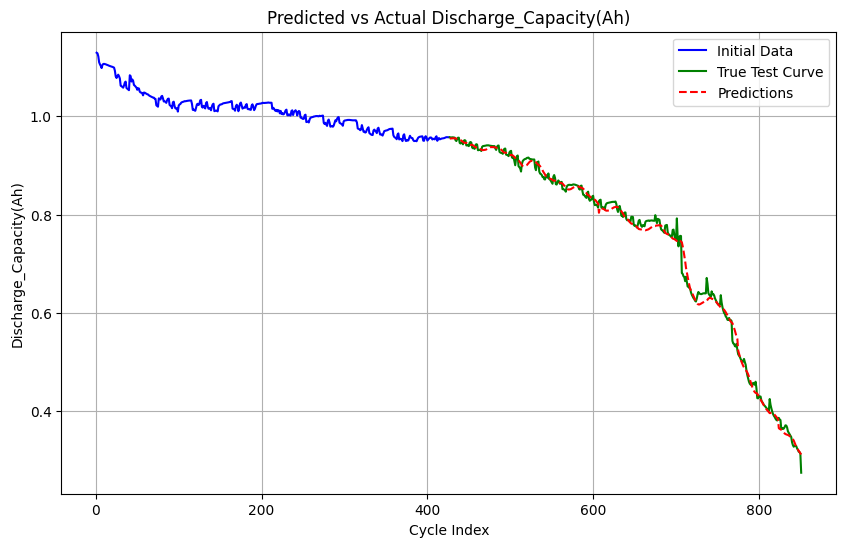

Epoch 1: Validation loss improved to 0.032499358161456056. Model saved!
Epoch 1/50, Train Loss: 0.46415101513266566, Val Loss: 0.032499358161456056
Epoch 2: Validation loss improved to 0.017003024721311197. Model saved!
Epoch 2/50, Train Loss: 0.020765075120808822, Val Loss: 0.017003024721311197
Epoch 3: Validation loss improved to 0.0012851409911591974. Model saved!
Epoch 3/50, Train Loss: 0.006050210894318298, Val Loss: 0.0012851409911591974
Epoch 4: Validation loss improved to 0.0006449267562452911. Model saved!
Epoch 4/50, Train Loss: 0.0007885424054360816, Val Loss: 0.0006449267562452911
Epoch 5: Validation loss improved to 0.0004084389276815475. Model saved!
Epoch 5/50, Train Loss: 0.0004769648701767437, Val Loss: 0.0004084389276815475
Epoch 6: Validation loss improved to 0.00033188033679228585. Model saved!
Epoch 6/50, Train Loss: 0.0003521210300927383, Val Loss: 0.00033188033679228585
Epoch 7: Validation loss improved to 0.00031347722688224167. Model saved!
Epoch 7/50, Train Lo

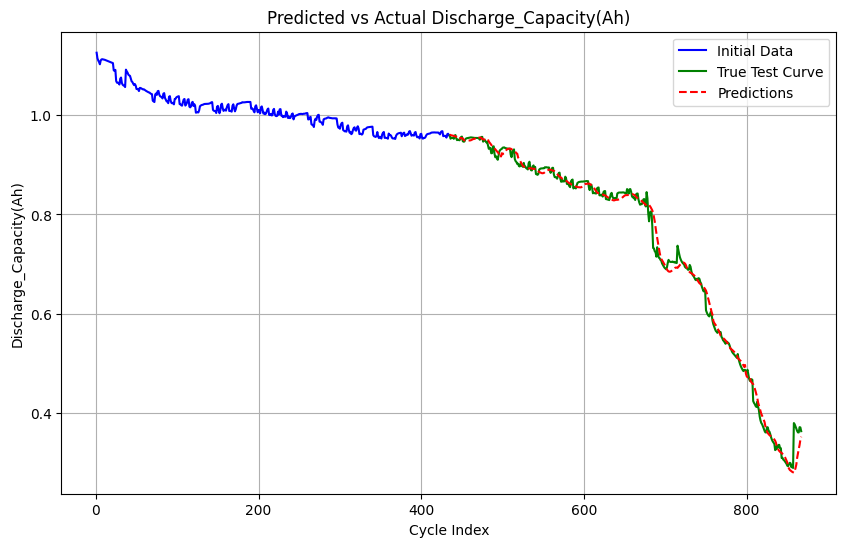

In [37]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=5e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_5,
        train_dataloader=CALCE_train_dataloaders_50[i],
        val_dataloader=CALCE_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_50.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_50.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, CALCE_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 50)

In [49]:
metrics = evaluate_model(model_5, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.011298141927561706
MAE: 0.007304784589420969


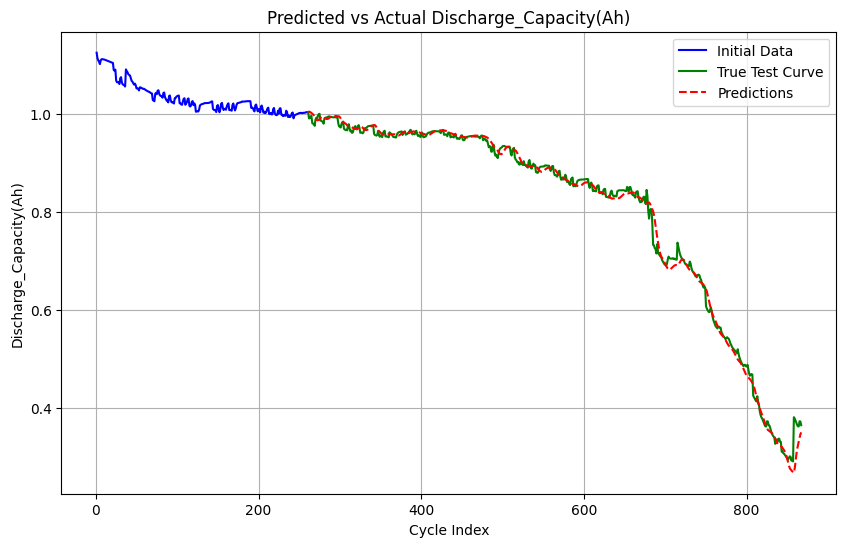

In [50]:
plot_predictions(model_5, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

# NASA Dataset

In [48]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

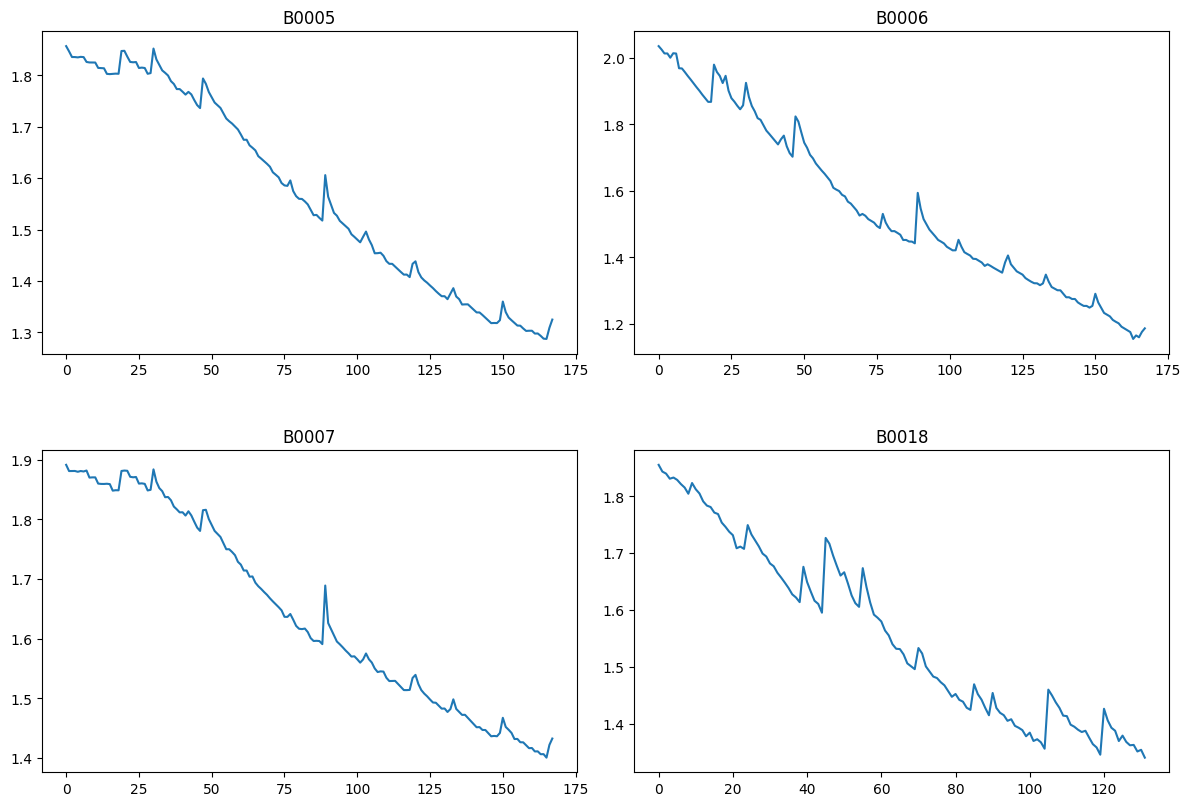

In [49]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [50]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in NASADatasetConstants.BATTERY_NAMES.value:
    excluded_list = [x for x in NASADatasetConstants.BATTERY_NAMES.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[('B0005', ['B0006', 'B0007', 'B0018']),
 ('B0006', ['B0005', 'B0007', 'B0018']),
 ('B0007', ['B0005', 'B0006', 'B0018']),
 ('B0018', ['B0005', 'B0006', 'B0007'])]

In [75]:
NASA_train_dataloaders_30 = []
NASA_val_dataloaders_30 = []
NASA_test_dataloaders_30 = []
n = 30

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []

    test_capacity = nasa_dfs[test_battery]['capacity'].to_numpy()
    split_idx = int(len(test_capacity) * (n / 100))  
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(nasa_dfs[battery]['capacity'], window_size=5)
        trainX.extend(x)
        trainY.extend(y)
    
    train_part = test_capacity[:split_idx]
    test_part = test_capacity[split_idx:]

    # Generate train data from the first n% of test battery
    trainX_test, trainY_test = generate_sliding_window_data(train_part, window_size=5)
    trainX.extend(trainX_test)
    trainY.extend(trainY_test)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(test_part, window_size=5)
    testX, testY = np.array(testX), np.array(testY)

    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    NASA_train_dataloaders_30.append(train_dataloader)
    NASA_val_dataloaders_30.append(val_dataloader)
    NASA_test_dataloaders_30.append(test_dataloader)

In [53]:
NASA_train_dataloaders_30, NASA_test_dataloaders_30, NASA_val_dataloaders_30

([<torch.utils.data.dataloader.DataLoader at 0x2860fbbbda0>,
  <torch.utils.data.dataloader.DataLoader at 0x28699ff8d40>])

In [76]:
NASA_train_dataloaders_50 = []
NASA_val_dataloaders_50 = []
NASA_test_dataloaders_50 = []
n = 50

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []

    test_capacity = nasa_dfs[test_battery]['capacity'].to_numpy()
    split_idx = int(len(test_capacity) * (n / 100))  
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(nasa_dfs[battery]['capacity'], window_size=5)
        trainX.extend(x)
        trainY.extend(y)
    
    train_part = test_capacity[:split_idx]
    test_part = test_capacity[split_idx:]

    # Generate train data from the first n% of test battery
    trainX_test, trainY_test = generate_sliding_window_data(train_part, window_size=5)
    trainX.extend(trainX_test)
    trainY.extend(trainY_test)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(test_part, window_size=5)
    testX, testY = np.array(testX), np.array(testY)

    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    NASA_train_dataloaders_50.append(train_dataloader)
    NASA_val_dataloaders_50.append(val_dataloader)
    NASA_test_dataloaders_50.append(test_dataloader)

In [56]:
NASA_train_dataloaders_50, NASA_test_dataloaders_50, NASA_val_dataloaders_50

([<torch.utils.data.dataloader.DataLoader at 0x2860773eb70>,
  <torch.utils.data.dataloader.DataLoader at 0x2861035e000>])

In [77]:
MIN = 0.0
MAX = 2.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

c:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1: Validation loss improved to 1.1405712366104126. Model saved!
Epoch 1/200, Train Loss: 1.141594960139348, Val Loss: 1.1405712366104126
Epoch 2: Validation loss improved to 1.1272908449172974. Model saved!
Epoch 2/200, Train Loss: 1.0755705191538885, Val Loss: 1.1272908449172974
Epoch 3: Validation loss improved to 1.0439775586128235. Model saved!
Epoch 3/200, Train Loss: 0.983200192451477, Val Loss: 1.0439775586128235
Epoch 4: Validation loss improved to 0.8500558435916901. Model saved!
Epoch 4/200, Train Loss: 0.8753757110008826, Val Loss: 0.8500558435916901
Epoch 5: Validation loss improved to 0.7736538946628571. Model saved!
Epoch 5/200, Train Loss: 0.7764171040975131, Val Loss: 0.7736538946628571
Epoch 6: Validation loss improved to 0.6599402725696564. Model saved!
Epoch 6/200, Train Loss: 0.665836934859936, Val Loss: 0.6599402725696564
Epoch 7: Validation loss improved to 0.47018733620643616. Model saved!
Epoch 7/200, Train Loss: 0.5420003647987659, Val Loss: 0.47018733620

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\4123180717.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConsta

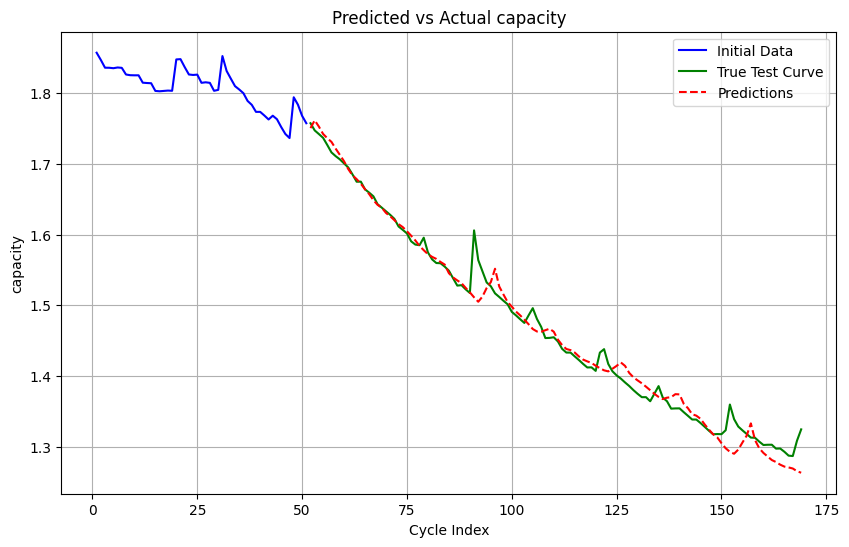

Epoch 1: Validation loss improved to 0.3328135460615158. Model saved!
Epoch 1/200, Train Loss: 0.33377136633946347, Val Loss: 0.3328135460615158
Epoch 2: Validation loss improved to 0.3302724286913872. Model saved!
Epoch 2/200, Train Loss: 0.2938191363444695, Val Loss: 0.3302724286913872
Epoch 3: Validation loss improved to 0.24719688668847084. Model saved!
Epoch 3/200, Train Loss: 0.2348571144617521, Val Loss: 0.24719688668847084
Epoch 4: Validation loss improved to 0.1385527327656746. Model saved!
Epoch 4/200, Train Loss: 0.16831178733935723, Val Loss: 0.1385527327656746
Epoch 5: Validation loss improved to 0.07446219027042389. Model saved!
Epoch 5/200, Train Loss: 0.10806819510001403, Val Loss: 0.07446219027042389
Epoch 6: Validation loss improved to 0.04014081880450249. Model saved!
Epoch 6/200, Train Loss: 0.05717964011889238, Val Loss: 0.04014081880450249
Epoch 7: Validation loss improved to 0.01786463987082243. Model saved!
Epoch 7/200, Train Loss: 0.027728066278191712, Val Loss

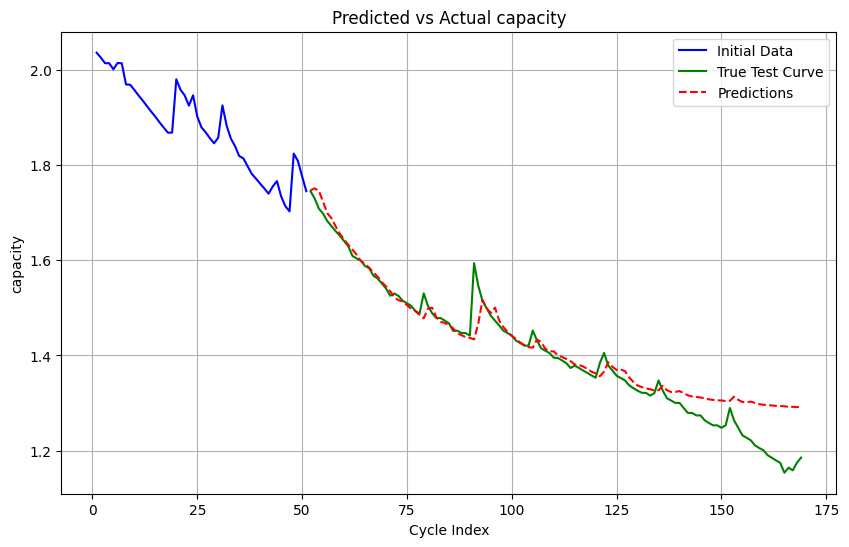

Epoch 1: Validation loss improved to 1.162264883518219. Model saved!
Epoch 1/200, Train Loss: 1.1064004256175115, Val Loss: 1.162264883518219
Epoch 2: Validation loss improved to 1.074683427810669. Model saved!
Epoch 2/200, Train Loss: 1.0535534299336946, Val Loss: 1.074683427810669
Epoch 3: Validation loss improved to 1.055394321680069. Model saved!
Epoch 3/200, Train Loss: 1.0126642080453725, Val Loss: 1.055394321680069
Epoch 4: Validation loss improved to 0.9478692263364792. Model saved!
Epoch 4/200, Train Loss: 0.9564191423929654, Val Loss: 0.9478692263364792
Epoch 5: Validation loss improved to 0.8872277438640594. Model saved!
Epoch 5/200, Train Loss: 0.8870832048929654, Val Loss: 0.8872277438640594
Epoch 6: Validation loss improved to 0.6813258975744247. Model saved!
Epoch 6/200, Train Loss: 0.7830393360211299, Val Loss: 0.6813258975744247
Epoch 7: Validation loss improved to 0.5330619812011719. Model saved!
Epoch 7/200, Train Loss: 0.6159338309214666, Val Loss: 0.533061981201171

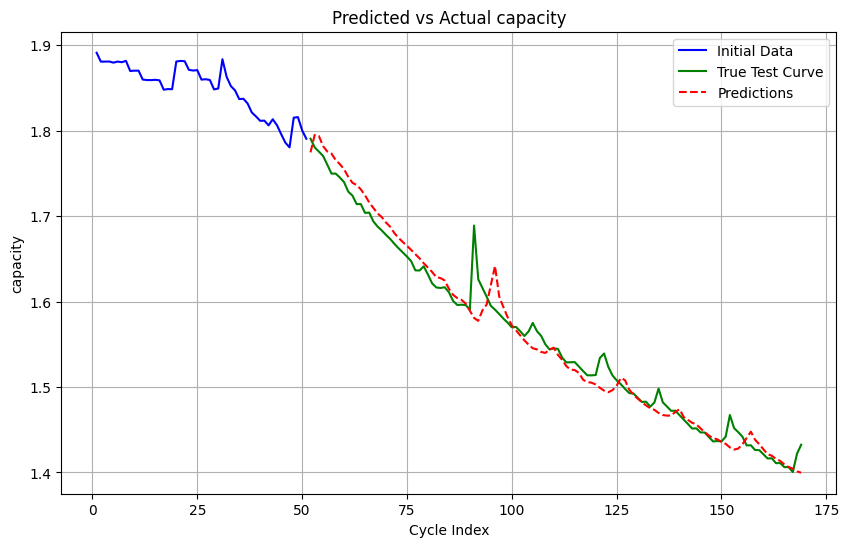

Epoch 1: Validation loss improved to 0.3401956260204315. Model saved!
Epoch 1/200, Train Loss: 0.35360375472477507, Val Loss: 0.3401956260204315
Epoch 2: Validation loss improved to 0.29692648351192474. Model saved!
Epoch 2/200, Train Loss: 0.30479204441819874, Val Loss: 0.29692648351192474
Epoch 3: Validation loss improved to 0.24253341928124428. Model saved!
Epoch 3/200, Train Loss: 0.24669473511832102, Val Loss: 0.24253341928124428
Epoch 4: Validation loss improved to 0.13334272988140583. Model saved!
Epoch 4/200, Train Loss: 0.18807441421917506, Val Loss: 0.13334272988140583
Epoch 5: Validation loss improved to 0.03927597450092435. Model saved!
Epoch 5/200, Train Loss: 0.09417458982872111, Val Loss: 0.03927597450092435
Epoch 6: Validation loss improved to 0.007446054834872484. Model saved!
Epoch 6/200, Train Loss: 0.02199113984326167, Val Loss: 0.007446054834872484
Epoch 7: Validation loss improved to 0.002153918147087097. Model saved!
Epoch 7/200, Train Loss: 0.002903341716903794,

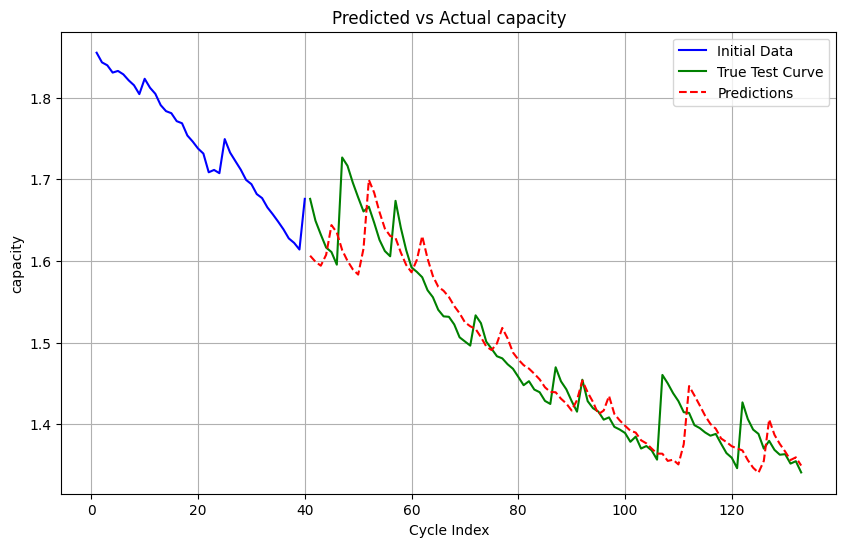

In [78]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model(window_size=5).to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=2e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_1,
        train_dataloader=NASA_train_dataloaders_30[i],
        val_dataloader=NASA_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=50,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_30.pth'
    )
    
    model_1.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_30.pth'))
    model_1.to(device)

    metrics = evaluate_model(model_1, NASA_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_1, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

Epoch 1: Validation loss improved to 0.594292014837265. Model saved!
Epoch 1/200, Train Loss: 0.5923418487821307, Val Loss: 0.594292014837265
Epoch 2: Validation loss improved to 0.5677464306354523. Model saved!
Epoch 2/200, Train Loss: 0.5430948223386493, Val Loss: 0.5677464306354523
Epoch 3: Validation loss improved to 0.476726733148098. Model saved!
Epoch 3/200, Train Loss: 0.4918756974594934, Val Loss: 0.476726733148098
Epoch 4: Validation loss improved to 0.3105318620800972. Model saved!
Epoch 4/200, Train Loss: 0.39095790897096905, Val Loss: 0.3105318620800972
Epoch 5: Validation loss improved to 0.1915689893066883. Model saved!
Epoch 5/200, Train Loss: 0.26233585285288946, Val Loss: 0.1915689893066883
Epoch 6: Validation loss improved to 0.08744026720523834. Model saved!
Epoch 6/200, Train Loss: 0.13714074077350752, Val Loss: 0.08744026720523834
Epoch 7: Validation loss improved to 0.03592951875180006. Model saved!
Epoch 7/200, Train Loss: 0.06131681560405663, Val Loss: 0.035929

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2493353597.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConsta

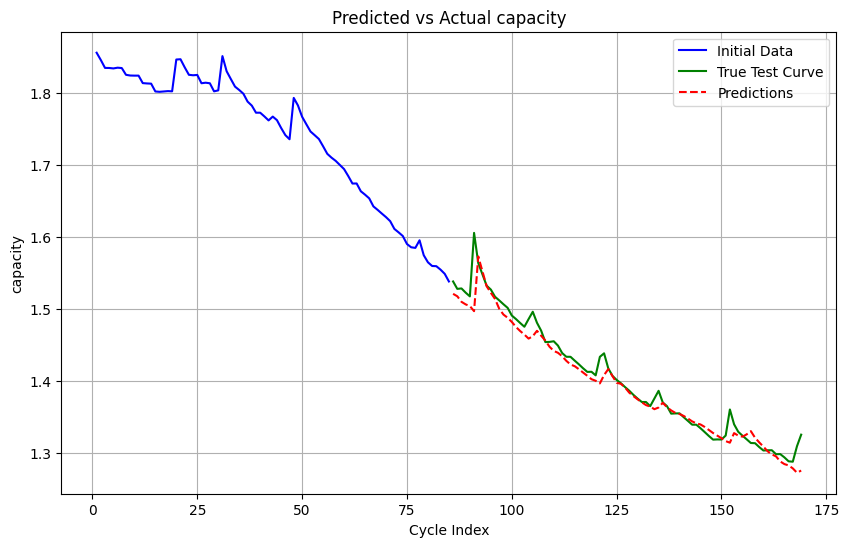

Epoch 1: Validation loss improved to 0.8182629346847534. Model saved!
Epoch 1/200, Train Loss: 0.8234568664005825, Val Loss: 0.8182629346847534
Epoch 2: Validation loss improved to 0.7829248607158661. Model saved!
Epoch 2/200, Train Loss: 0.7825865873268673, Val Loss: 0.7829248607158661
Epoch 3: Validation loss improved to 0.7627551555633545. Model saved!
Epoch 3/200, Train Loss: 0.7480670213699341, Val Loss: 0.7627551555633545
Epoch 4: Validation loss improved to 0.6411667019128799. Model saved!
Epoch 4/200, Train Loss: 0.6952830978802272, Val Loss: 0.6411667019128799
Epoch 5: Validation loss improved to 0.5116803199052811. Model saved!
Epoch 5/200, Train Loss: 0.586162771497454, Val Loss: 0.5116803199052811
Epoch 6: Validation loss improved to 0.4212741032242775. Model saved!
Epoch 6/200, Train Loss: 0.4735578830753054, Val Loss: 0.4212741032242775
Epoch 7: Validation loss improved to 0.3341882601380348. Model saved!
Epoch 7/200, Train Loss: 0.386377500636237, Val Loss: 0.33418826013

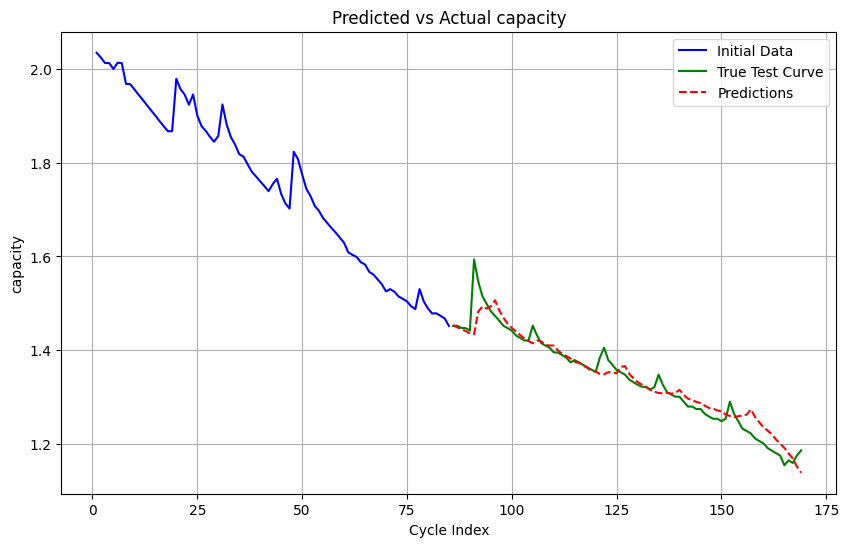

Epoch 1: Validation loss improved to 0.305684432387352. Model saved!
Epoch 1/200, Train Loss: 0.3333093502691814, Val Loss: 0.305684432387352
Epoch 2: No improvement. (1/50)
Epoch 2/200, Train Loss: 0.31341808821473804, Val Loss: 0.31385017931461334
Epoch 3: Validation loss improved to 0.25918781757354736. Model saved!
Epoch 3/200, Train Loss: 0.28174941135304316, Val Loss: 0.25918781757354736
Epoch 4: Validation loss improved to 0.21942336857318878. Model saved!
Epoch 4/200, Train Loss: 0.24128224913563048, Val Loss: 0.21942336857318878
Epoch 5: Validation loss improved to 0.1814885251224041. Model saved!
Epoch 5/200, Train Loss: 0.20893128854887827, Val Loss: 0.1814885251224041
Epoch 6: Validation loss improved to 0.14622808620333672. Model saved!
Epoch 6/200, Train Loss: 0.17422153907162802, Val Loss: 0.14622808620333672
Epoch 7: Validation loss improved to 0.11005081608891487. Model saved!
Epoch 7/200, Train Loss: 0.13656323882085936, Val Loss: 0.11005081608891487
Epoch 8: Validati

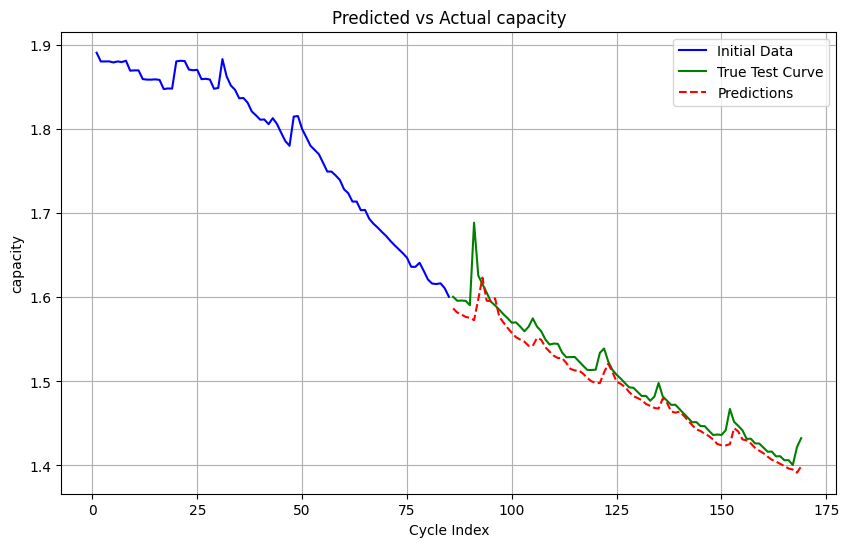

Epoch 1: Validation loss improved to 0.3293028250336647. Model saved!
Epoch 1/200, Train Loss: 0.3310661975826536, Val Loss: 0.3293028250336647
Epoch 2: Validation loss improved to 0.29048918187618256. Model saved!
Epoch 2/200, Train Loss: 0.2836772395031793, Val Loss: 0.29048918187618256
Epoch 3: Validation loss improved to 0.16668899729847908. Model saved!
Epoch 3/200, Train Loss: 0.19216049994741166, Val Loss: 0.16668899729847908
Epoch 4: Validation loss improved to 0.06695181783288717. Model saved!
Epoch 4/200, Train Loss: 0.09894411585160665, Val Loss: 0.06695181783288717
Epoch 5: Validation loss improved to 0.022268579807132483. Model saved!
Epoch 5/200, Train Loss: 0.040964419687432904, Val Loss: 0.022268579807132483
Epoch 6: Validation loss improved to 0.008428214467130601. Model saved!
Epoch 6/200, Train Loss: 0.01273633147190724, Val Loss: 0.008428214467130601
Epoch 7: Validation loss improved to 0.0022962134971749038. Model saved!
Epoch 7/200, Train Loss: 0.00397196185076609

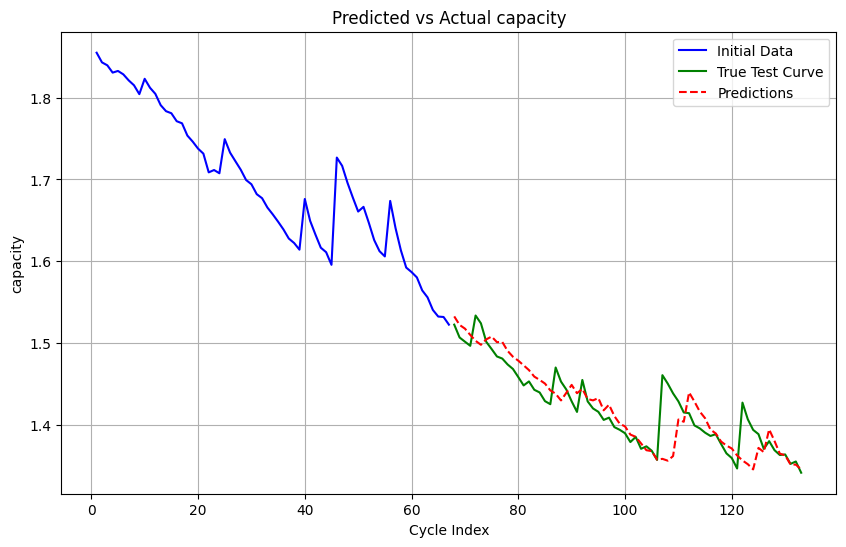

In [79]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model(window_size=5).to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=2e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_1,
        train_dataloader=NASA_train_dataloaders_50[i],
        val_dataloader=NASA_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=50,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_50.pth'
    )
    
    model_1.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}_50.pth'))
    model_1.to(device)

    metrics = evaluate_model(model_1, NASA_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_1, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 50, 5)

## BiLSTM Attention Model

Epoch 1: Validation loss improved to 0.6240723133087158. Model saved!
Epoch 1/100, Train Loss: 0.6183755718744718, Val Loss: 0.6240723133087158
Epoch 2: Validation loss improved to 0.5355775505304337. Model saved!
Epoch 2/100, Train Loss: 0.5422522654900184, Val Loss: 0.5355775505304337
Epoch 3: Validation loss improved to 0.2522297166287899. Model saved!
Epoch 3/100, Train Loss: 0.38009002117010265, Val Loss: 0.2522297166287899
Epoch 4: Validation loss improved to 0.005100460723042488. Model saved!
Epoch 4/100, Train Loss: 0.09317453782289074, Val Loss: 0.005100460723042488
Epoch 5: Validation loss improved to 0.0013224786962382495. Model saved!
Epoch 5/100, Train Loss: 0.01848873746796296, Val Loss: 0.0013224786962382495
Epoch 6: No improvement. (1/10)
Epoch 6/100, Train Loss: 0.005136033269361808, Val Loss: 0.00395131844561547
Epoch 7: No improvement. (2/10)
Epoch 7/100, Train Loss: 0.002024991607938248, Val Loss: 0.0019540524517651647
Epoch 8: No improvement. (3/10)
Epoch 8/100, Tr

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1437012541.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConsta

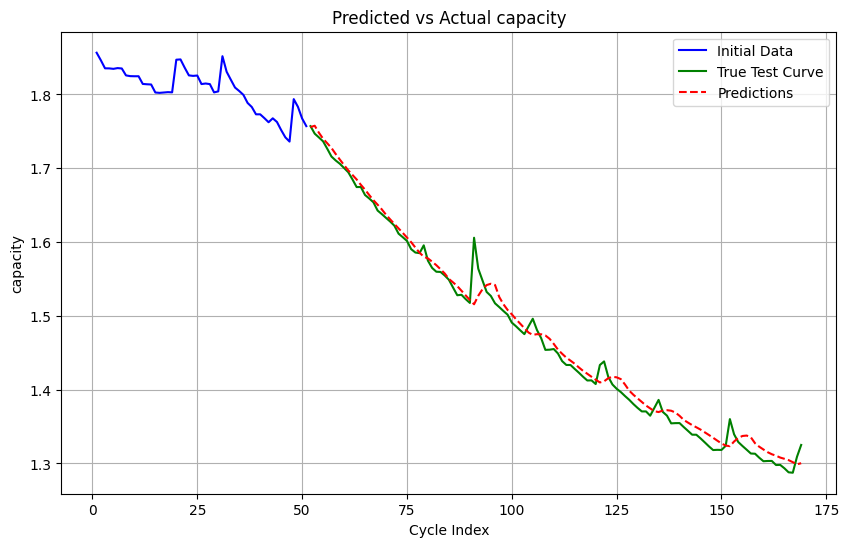

Epoch 1: Validation loss improved to 0.543751060962677. Model saved!
Epoch 1/100, Train Loss: 0.6138367927991427, Val Loss: 0.543751060962677
Epoch 2: Validation loss improved to 0.37435224652290344. Model saved!
Epoch 2/100, Train Loss: 0.4922275703686934, Val Loss: 0.37435224652290344
Epoch 3: Validation loss improved to 0.08156122639775276. Model saved!
Epoch 3/100, Train Loss: 0.24983070332270402, Val Loss: 0.08156122639775276
Epoch 4: Validation loss improved to 0.028926925733685493. Model saved!
Epoch 4/100, Train Loss: 0.025463375003220372, Val Loss: 0.028926925733685493
Epoch 5: Validation loss improved to 0.007850002264603972. Model saved!
Epoch 5/100, Train Loss: 0.008735737002168138, Val Loss: 0.007850002264603972
Epoch 6: Validation loss improved to 0.0015626002568751574. Model saved!
Epoch 6/100, Train Loss: 0.004309849361351763, Val Loss: 0.0015626002568751574
Epoch 7: Validation loss improved to 0.0010870757105294615. Model saved!
Epoch 7/100, Train Loss: 0.0019697809430

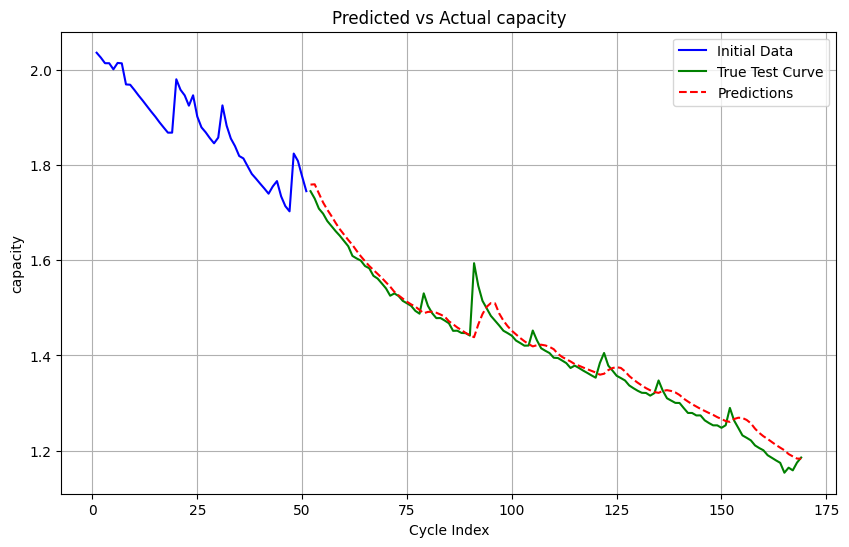

Epoch 1: Validation loss improved to 0.6461586952209473. Model saved!
Epoch 1/100, Train Loss: 0.6192650519884549, Val Loss: 0.6461586952209473
Epoch 2: Validation loss improved to 0.5723074376583099. Model saved!
Epoch 2/100, Train Loss: 0.5989618851588323, Val Loss: 0.5723074376583099
Epoch 3: Validation loss improved to 0.5049792379140854. Model saved!
Epoch 3/100, Train Loss: 0.5435869120634519, Val Loss: 0.5049792379140854
Epoch 4: Validation loss improved to 0.3010029122233391. Model saved!
Epoch 4/100, Train Loss: 0.40769652678416324, Val Loss: 0.3010029122233391
Epoch 5: Validation loss improved to 0.003904437879100442. Model saved!
Epoch 5/100, Train Loss: 0.11476600082376255, Val Loss: 0.003904437879100442
Epoch 6: Validation loss improved to 0.0012290100858081132. Model saved!
Epoch 6/100, Train Loss: 0.020579126667983543, Val Loss: 0.0012290100858081132
Epoch 7: No improvement. (1/10)
Epoch 7/100, Train Loss: 0.005865093750449328, Val Loss: 0.00389772851485759
Epoch 8: No i

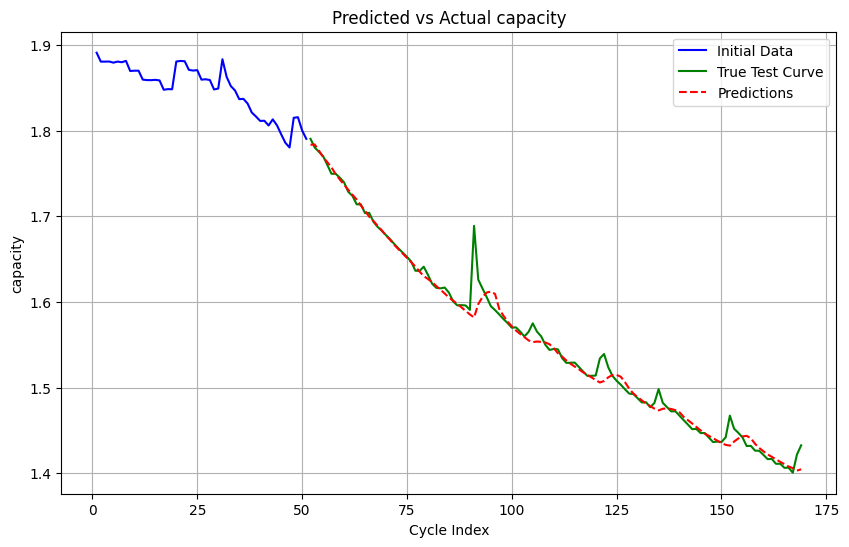

Epoch 1: Validation loss improved to 0.5902645438909531. Model saved!
Epoch 1/100, Train Loss: 0.6262270723070417, Val Loss: 0.5902645438909531
Epoch 2: Validation loss improved to 0.5380878001451492. Model saved!
Epoch 2/100, Train Loss: 0.5914389533655984, Val Loss: 0.5380878001451492
Epoch 3: Validation loss improved to 0.3916589766740799. Model saved!
Epoch 3/100, Train Loss: 0.49486168793269564, Val Loss: 0.3916589766740799
Epoch 4: Validation loss improved to 0.08292722329497337. Model saved!
Epoch 4/100, Train Loss: 0.26876614934631754, Val Loss: 0.08292722329497337
Epoch 5: Validation loss improved to 0.022176245227456093. Model saved!
Epoch 5/100, Train Loss: 0.029177007913988615, Val Loss: 0.022176245227456093
Epoch 6: Validation loss improved to 0.006050542462617159. Model saved!
Epoch 6/100, Train Loss: 0.006829470778549356, Val Loss: 0.006050542462617159
Epoch 7: Validation loss improved to 0.0025953472359105945. Model saved!
Epoch 7/100, Train Loss: 0.0025329165010979132,

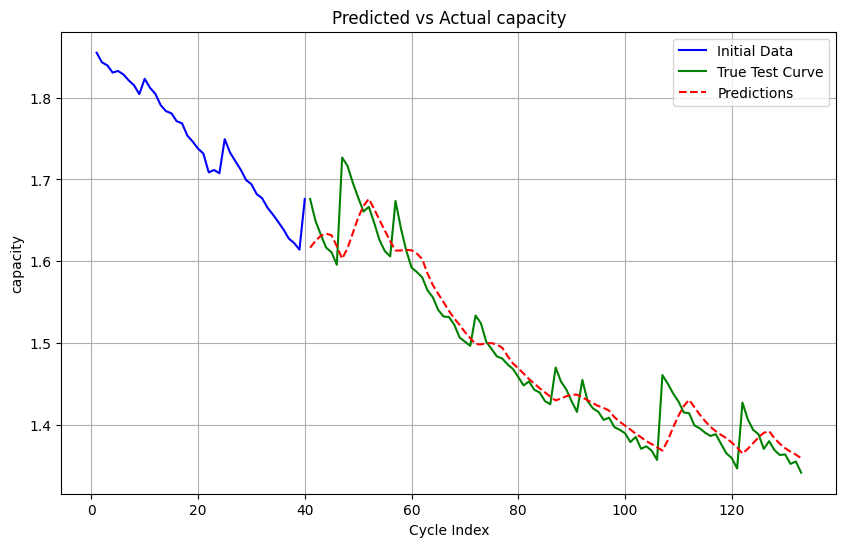

In [80]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 100
    
    train_model(
        model=model_2,
        train_dataloader=NASA_train_dataloaders_30[i],
        val_dataloader=NASA_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}_30.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}_30.pth'))
    model_2.to(device)

    metrics = evaluate_model(model_2, NASA_test_dataloaders_30[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', -1, 30, 5)

Epoch 1: Validation loss improved to 0.5488293021917343. Model saved!
Epoch 1/100, Train Loss: 0.6089502828461784, Val Loss: 0.5488293021917343
Epoch 2: Validation loss improved to 0.3322969526052475. Model saved!
Epoch 2/100, Train Loss: 0.45929885123457226, Val Loss: 0.3322969526052475
Epoch 3: Validation loss improved to 0.005453737918287516. Model saved!
Epoch 3/100, Train Loss: 0.16342964941369637, Val Loss: 0.005453737918287516
Epoch 4: Validation loss improved to 0.002154156187316403. Model saved!
Epoch 4/100, Train Loss: 0.017143914301414043, Val Loss: 0.002154156187316403
Epoch 5: No improvement. (1/10)
Epoch 5/100, Train Loss: 0.004890462059328067, Val Loss: 0.0033419608371332288
Epoch 6: Validation loss improved to 0.002032742224400863. Model saved!
Epoch 6/100, Train Loss: 0.002125589667619871, Val Loss: 0.002032742224400863
Epoch 7: Validation loss improved to 0.0015938743599690497. Model saved!
Epoch 7/100, Train Loss: 0.0014786145184189081, Val Loss: 0.001593874359969049

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2017192351.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConsta

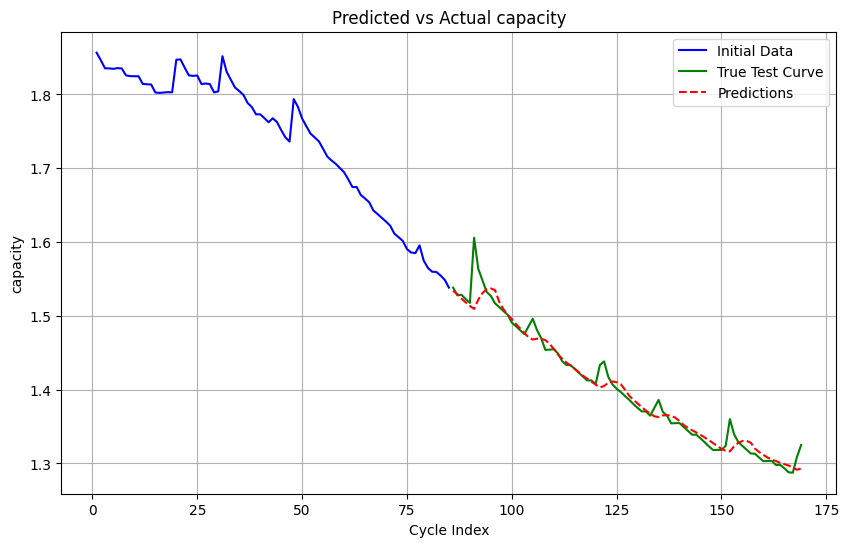

Epoch 1: Validation loss improved to 0.650862842798233. Model saved!
Epoch 1/100, Train Loss: 0.6521029259477343, Val Loss: 0.650862842798233
Epoch 2: Validation loss improved to 0.6290128231048584. Model saved!
Epoch 2/100, Train Loss: 0.6386204149041858, Val Loss: 0.6290128231048584
Epoch 3: Validation loss improved to 0.5902808010578156. Model saved!
Epoch 3/100, Train Loss: 0.6118704974651337, Val Loss: 0.5902808010578156
Epoch 4: Validation loss improved to 0.46858903765678406. Model saved!
Epoch 4/100, Train Loss: 0.5495562127658299, Val Loss: 0.46858903765678406
Epoch 5: Validation loss improved to 0.1683192364871502. Model saved!
Epoch 5/100, Train Loss: 0.3580660724214145, Val Loss: 0.1683192364871502
Epoch 6: Validation loss improved to 0.027650023344904184. Model saved!
Epoch 6/100, Train Loss: 0.04963383876020089, Val Loss: 0.027650023344904184
Epoch 7: Validation loss improved to 0.0030979608418419957. Model saved!
Epoch 7/100, Train Loss: 0.00854072644973972, Val Loss: 0.

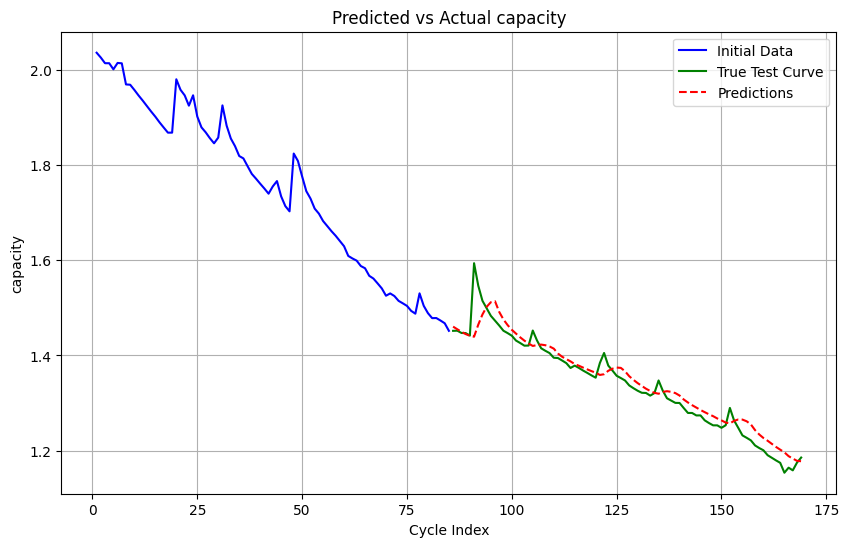

Epoch 1: Validation loss improved to 0.5777670294046402. Model saved!
Epoch 1/100, Train Loss: 0.6197493842669896, Val Loss: 0.5777670294046402
Epoch 2: Validation loss improved to 0.4677896499633789. Model saved!
Epoch 2/100, Train Loss: 0.5419298516852515, Val Loss: 0.4677896499633789
Epoch 3: Validation loss improved to 0.21089262515306473. Model saved!
Epoch 3/100, Train Loss: 0.369174841259207, Val Loss: 0.21089262515306473
Epoch 4: Validation loss improved to 0.028483049012720585. Model saved!
Epoch 4/100, Train Loss: 0.07514352640802306, Val Loss: 0.028483049012720585
Epoch 5: Validation loss improved to 0.007027949672192335. Model saved!
Epoch 5/100, Train Loss: 0.01478773243226377, Val Loss: 0.007027949672192335
Epoch 6: Validation loss improved to 0.002814390347339213. Model saved!
Epoch 6/100, Train Loss: 0.004177112889010459, Val Loss: 0.002814390347339213
Epoch 7: Validation loss improved to 0.0014828195853624493. Model saved!
Epoch 7/100, Train Loss: 0.0021221115603111684

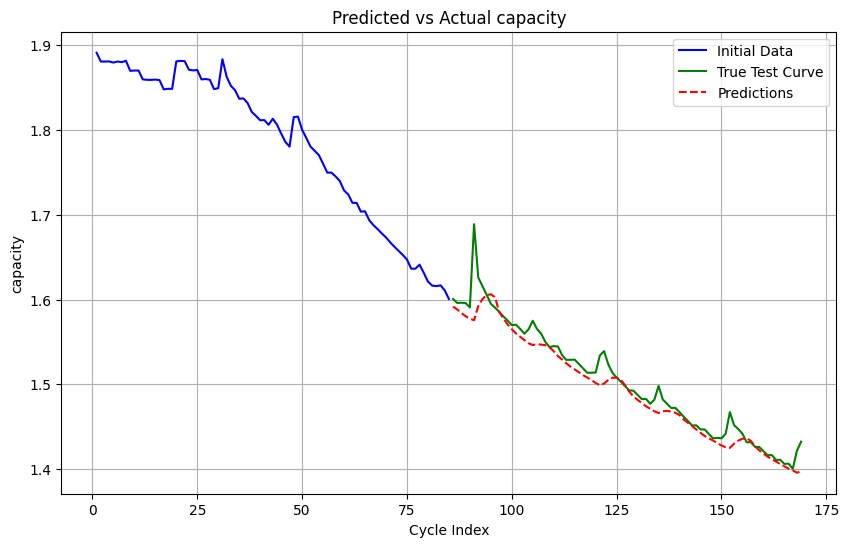

Epoch 1: Validation loss improved to 0.5953228920698166. Model saved!
Epoch 1/100, Train Loss: 0.6234614040170398, Val Loss: 0.5953228920698166
Epoch 2: Validation loss improved to 0.5206695348024368. Model saved!
Epoch 2/100, Train Loss: 0.5687330833503178, Val Loss: 0.5206695348024368
Epoch 3: Validation loss improved to 0.3250921964645386. Model saved!
Epoch 3/100, Train Loss: 0.44431587627955843, Val Loss: 0.3250921964645386
Epoch 4: Validation loss improved to 0.010672292206436396. Model saved!
Epoch 4/100, Train Loss: 0.17376988833504065, Val Loss: 0.010672292206436396
Epoch 5: Validation loss improved to 0.0017624754691496491. Model saved!
Epoch 5/100, Train Loss: 0.01563964438225542, Val Loss: 0.0017624754691496491
Epoch 6: No improvement. (1/10)
Epoch 6/100, Train Loss: 0.004582150880846062, Val Loss: 0.0023861785302869976
Epoch 7: Validation loss improved to 0.001556028553750366. Model saved!
Epoch 7/100, Train Loss: 0.0019468753515476628, Val Loss: 0.001556028553750366
Epoch

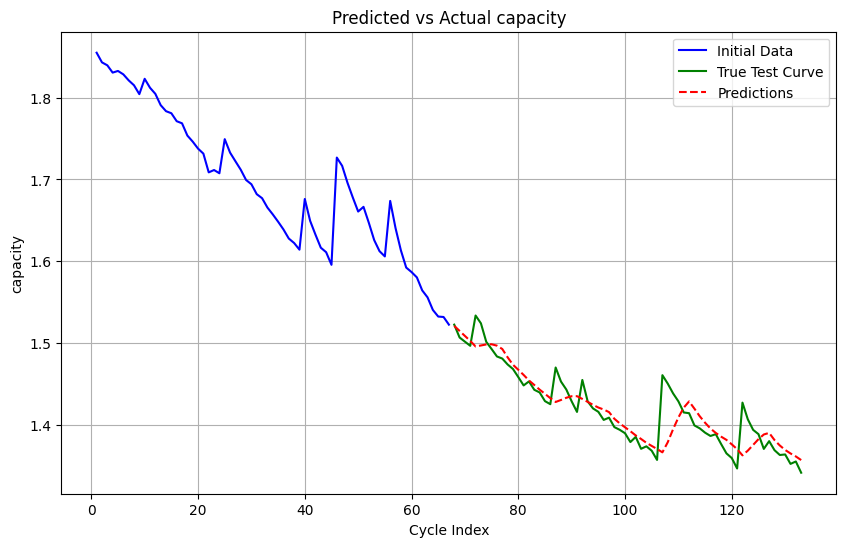

In [81]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 100
    
    train_model(
        model=model_2,
        train_dataloader=NASA_train_dataloaders_50[i],
        val_dataloader=NASA_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}_50.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}_50.pth'))
    model_2.to(device)

    metrics = evaluate_model(model_2, NASA_test_dataloaders_50[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', -1, 50, 5)

## ABC (Artificial Bee Colony) BiGRU Model

In [82]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, NASA_train_dataloaders_30[0], NASA_test_dataloaders_30[0], device, n_solutions=10, max_iters=20, window_size=5)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 2/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 3/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 4/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 5/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 6/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 7/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 8/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 9/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 10/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 11/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 12/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 13/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 14/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 15/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 16/20, Best Fitness (MSE): 0.0024058000999502838
Iteration 17/20, Best Fitness (MSE): 0.0024058000999502838
Iterat

Epoch 1: Validation loss improved to 1.5573287606239319. Model saved!
Epoch 1/200, Train Loss: 1.4838671042368963, Val Loss: 1.5573287606239319
Epoch 2: Validation loss improved to 1.4741618633270264. Model saved!
Epoch 2/200, Train Loss: 1.4598908607776349, Val Loss: 1.4741618633270264
Epoch 3: Validation loss improved to 1.4717312455177307. Model saved!
Epoch 3/200, Train Loss: 1.437865871649522, Val Loss: 1.4717312455177307
Epoch 4: Validation loss improved to 1.429230660200119. Model saved!
Epoch 4/200, Train Loss: 1.4167027656848614, Val Loss: 1.429230660200119
Epoch 5: Validation loss improved to 1.4179528057575226. Model saved!
Epoch 5/200, Train Loss: 1.3891305740063007, Val Loss: 1.4179528057575226
Epoch 6: Validation loss improved to 1.3512271642684937. Model saved!
Epoch 6/200, Train Loss: 1.3655398442195013, Val Loss: 1.3512271642684937
Epoch 7: No improvement. (1/20)
Epoch 7/200, Train Loss: 1.33831603710468, Val Loss: 1.3844638764858246
Epoch 8: Validation loss improved t

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\480005572.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConstan

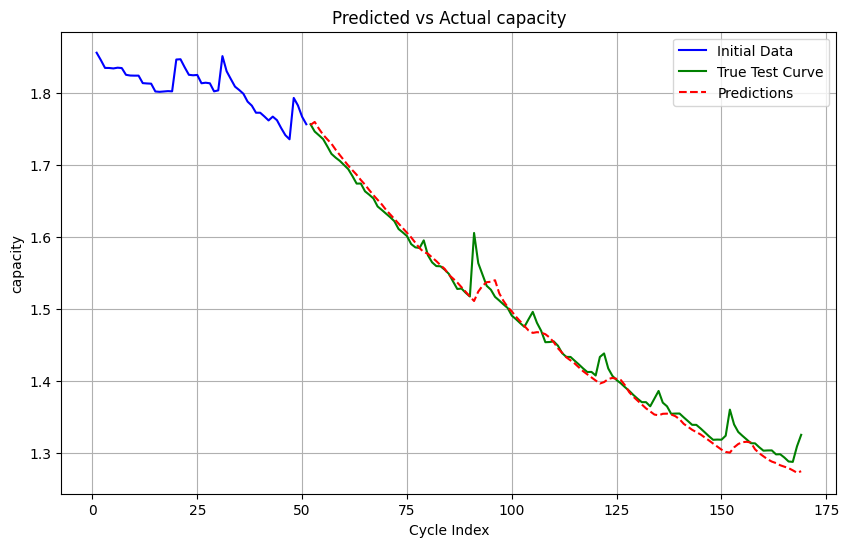

Epoch 1: Validation loss improved to 1.1688221395015717. Model saved!
Epoch 1/200, Train Loss: 1.1711759383861835, Val Loss: 1.1688221395015717
Epoch 2: No improvement. (1/20)
Epoch 2/200, Train Loss: 1.1494333102152898, Val Loss: 1.1781595647335052
Epoch 3: Validation loss improved to 1.1674091517925262. Model saved!
Epoch 3/200, Train Loss: 1.1357042972858136, Val Loss: 1.1674091517925262
Epoch 4: Validation loss improved to 1.1167981326580048. Model saved!
Epoch 4/200, Train Loss: 1.1274094489904551, Val Loss: 1.1167981326580048
Epoch 5: No improvement. (1/20)
Epoch 5/200, Train Loss: 1.110475365932171, Val Loss: 1.129952758550644
Epoch 6: No improvement. (2/20)
Epoch 6/200, Train Loss: 1.097849387388963, Val Loss: 1.127702921628952
Epoch 7: Validation loss improved to 1.1077072620391846. Model saved!
Epoch 7/200, Train Loss: 1.0863841221882746, Val Loss: 1.1077072620391846
Epoch 8: Validation loss improved to 1.076599359512329. Model saved!
Epoch 8/200, Train Loss: 1.06311899882096

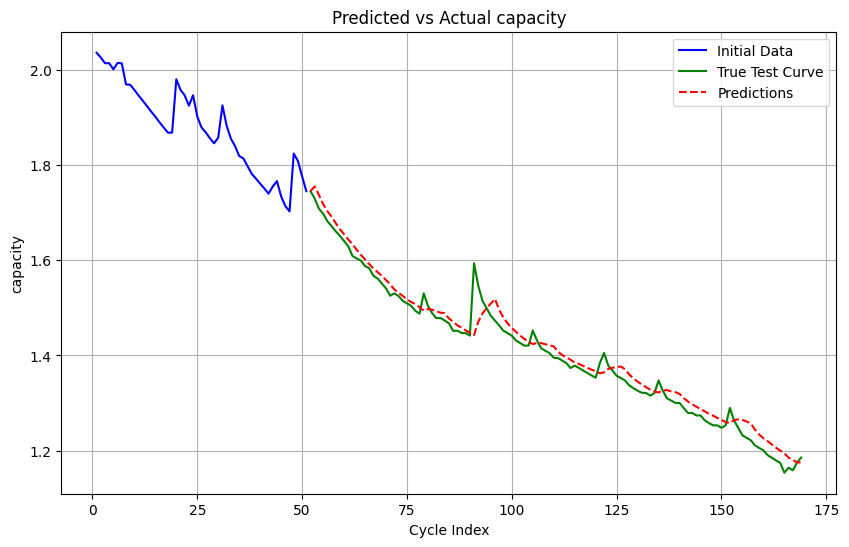

Epoch 1: Validation loss improved to 0.26276082172989845. Model saved!
Epoch 1/200, Train Loss: 0.25285072739307696, Val Loss: 0.26276082172989845
Epoch 2: Validation loss improved to 0.25956253707408905. Model saved!
Epoch 2/200, Train Loss: 0.24658168049959037, Val Loss: 0.25956253707408905
Epoch 3: Validation loss improved to 0.25666923448443413. Model saved!
Epoch 3/200, Train Loss: 0.23753052147535178, Val Loss: 0.25666923448443413
Epoch 4: Validation loss improved to 0.2459501028060913. Model saved!
Epoch 4/200, Train Loss: 0.2242559423813453, Val Loss: 0.2459501028060913
Epoch 5: Validation loss improved to 0.234115831553936. Model saved!
Epoch 5/200, Train Loss: 0.21102616649407607, Val Loss: 0.234115831553936
Epoch 6: Validation loss improved to 0.1882372461259365. Model saved!
Epoch 6/200, Train Loss: 0.1966460278401008, Val Loss: 0.1882372461259365
Epoch 7: No improvement. (1/20)
Epoch 7/200, Train Loss: 0.1868574722455098, Val Loss: 0.19967779144644737
Epoch 8: No improveme

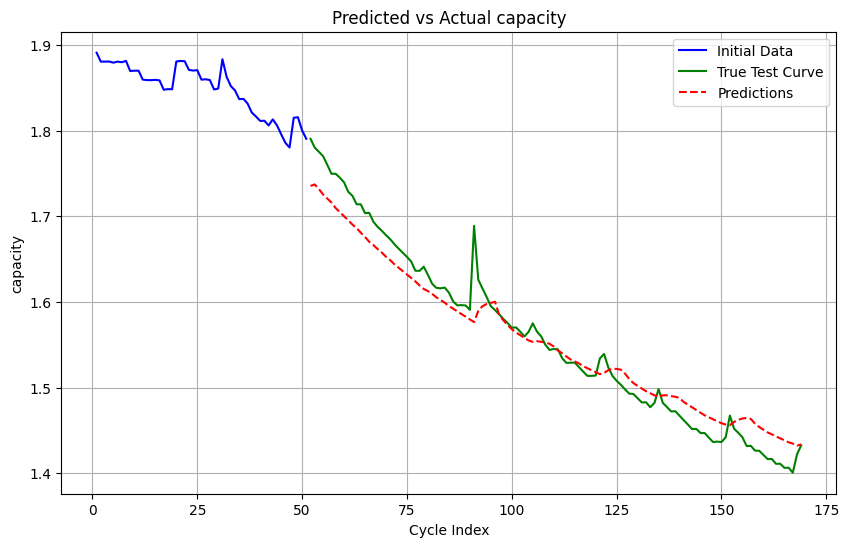

Epoch 1: Validation loss improved to 0.5029952600598335. Model saved!
Epoch 1/200, Train Loss: 0.5449943521193096, Val Loss: 0.5029952600598335
Epoch 2: Validation loss improved to 0.45177067071199417. Model saved!
Epoch 2/200, Train Loss: 0.5033144290958133, Val Loss: 0.45177067071199417
Epoch 3: Validation loss improved to 0.4232957363128662. Model saved!
Epoch 3/200, Train Loss: 0.4477646904332297, Val Loss: 0.4232957363128662
Epoch 4: Validation loss improved to 0.3864588141441345. Model saved!
Epoch 4/200, Train Loss: 0.4194334936993463, Val Loss: 0.3864588141441345
Epoch 5: Validation loss improved to 0.36266519874334335. Model saved!
Epoch 5/200, Train Loss: 0.3859469997031348, Val Loss: 0.36266519874334335
Epoch 6: Validation loss improved to 0.3372543454170227. Model saved!
Epoch 6/200, Train Loss: 0.35226900449820925, Val Loss: 0.3372543454170227
Epoch 7: Validation loss improved to 0.3021961525082588. Model saved!
Epoch 7/200, Train Loss: 0.3193709190402712, Val Loss: 0.3021

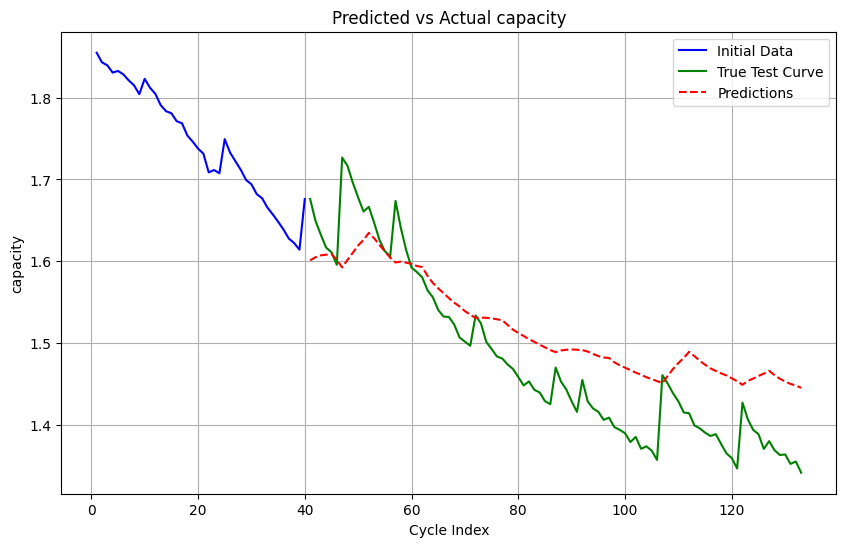

In [91]:

for i in range(4):
    model_3 = BiGRUModel(input_size=5, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    train_model(
        model=model_3,
        train_dataloader=NASA_train_dataloaders_30[i],
        val_dataloader=NASA_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=20,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}_30.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}_30.pth'))
    model_3.to(device)

    metrics = evaluate_model(model_3, NASA_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

In [84]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, NASA_train_dataloaders_50[0], NASA_test_dataloaders_50[0], device, n_solutions=10, max_iters=20, window_size=5)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 2/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 3/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 4/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 5/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 6/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 7/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 8/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 9/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 10/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 11/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 12/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 13/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 14/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 15/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 16/20, Best Fitness (MSE): 0.0009824949859951933
Iteration 17/20, Best Fitness (MSE): 0.0009824949859951933
Iterat

Epoch 1: Validation loss improved to 1.283802330493927. Model saved!
Epoch 1/200, Train Loss: 1.2989167060170854, Val Loss: 1.283802330493927
Epoch 2: No improvement. (1/20)
Epoch 2/200, Train Loss: 1.2904903633253915, Val Loss: 1.288719117641449
Epoch 3: Validation loss improved to 1.2584648430347443. Model saved!
Epoch 3/200, Train Loss: 1.2818658266748701, Val Loss: 1.2584648430347443
Epoch 4: No improvement. (1/20)
Epoch 4/200, Train Loss: 1.2699244277817863, Val Loss: 1.2593435645103455
Epoch 5: Validation loss improved to 1.2284279465675354. Model saved!
Epoch 5/200, Train Loss: 1.2471115333693368, Val Loss: 1.2284279465675354
Epoch 6: Validation loss improved to 1.2139244377613068. Model saved!
Epoch 6/200, Train Loss: 1.221496684210641, Val Loss: 1.2139244377613068
Epoch 7: Validation loss improved to 1.2046167254447937. Model saved!
Epoch 7/200, Train Loss: 1.2073480572019304, Val Loss: 1.2046167254447937
Epoch 8: Validation loss improved to 1.1691027581691742. Model saved!
Ep

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\4182160593.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConsta

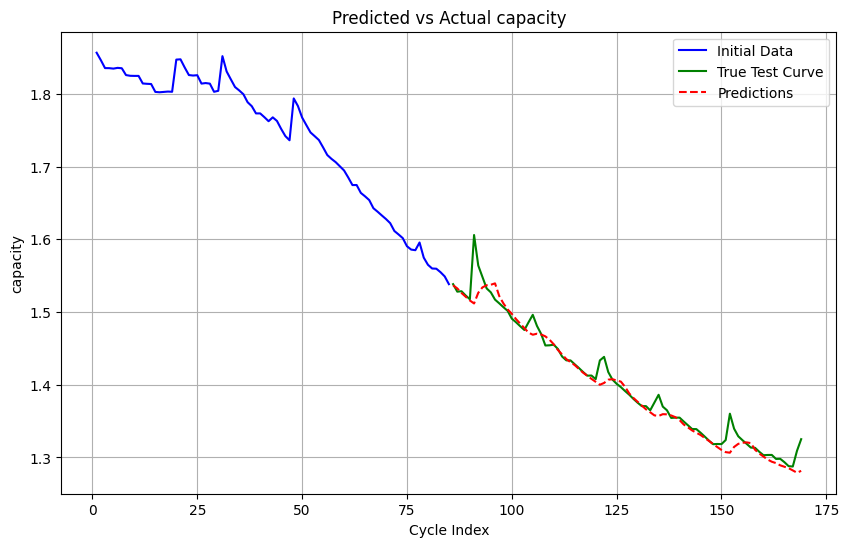

Epoch 1: Validation loss improved to 0.2884995937347412. Model saved!
Epoch 1/200, Train Loss: 0.29358385290418354, Val Loss: 0.2884995937347412
Epoch 2: Validation loss improved to 0.2622143030166626. Model saved!
Epoch 2/200, Train Loss: 0.269779061632497, Val Loss: 0.2622143030166626
Epoch 3: Validation loss improved to 0.2577461078763008. Model saved!
Epoch 3/200, Train Loss: 0.26052657621247427, Val Loss: 0.2577461078763008
Epoch 4: Validation loss improved to 0.2564202845096588. Model saved!
Epoch 4/200, Train Loss: 0.25504573647465023, Val Loss: 0.2564202845096588
Epoch 5: Validation loss improved to 0.24696096032857895. Model saved!
Epoch 5/200, Train Loss: 0.24937626932348525, Val Loss: 0.24696096032857895
Epoch 6: Validation loss improved to 0.23467756062746048. Model saved!
Epoch 6/200, Train Loss: 0.24271295751844132, Val Loss: 0.23467756062746048
Epoch 7: Validation loss improved to 0.23014350980520248. Model saved!
Epoch 7/200, Train Loss: 0.23625627266509192, Val Loss: 0

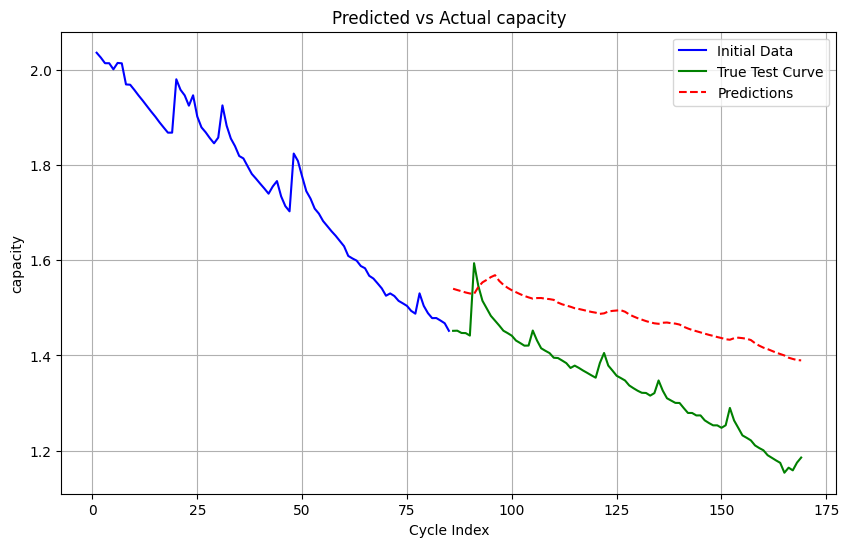

Epoch 1: Validation loss improved to 0.2206287607550621. Model saved!
Epoch 1/200, Train Loss: 0.2385757640004158, Val Loss: 0.2206287607550621
Epoch 2: No improvement. (1/20)
Epoch 2/200, Train Loss: 0.23770050598042353, Val Loss: 0.2273913212120533
Epoch 3: No improvement. (2/20)
Epoch 3/200, Train Loss: 0.23107946131910598, Val Loss: 0.2210124395787716
Epoch 4: Validation loss improved to 0.21641893312335014. Model saved!
Epoch 4/200, Train Loss: 0.2304296972496169, Val Loss: 0.21641893312335014
Epoch 5: Validation loss improved to 0.21431290358304977. Model saved!
Epoch 5/200, Train Loss: 0.2251583422933306, Val Loss: 0.21431290358304977
Epoch 6: No improvement. (1/20)
Epoch 6/200, Train Loss: 0.22402483011995042, Val Loss: 0.2164895012974739
Epoch 7: Validation loss improved to 0.21249110251665115. Model saved!
Epoch 7/200, Train Loss: 0.2233267586146082, Val Loss: 0.21249110251665115
Epoch 8: No improvement. (1/20)
Epoch 8/200, Train Loss: 0.22373645326920918, Val Loss: 0.2153664

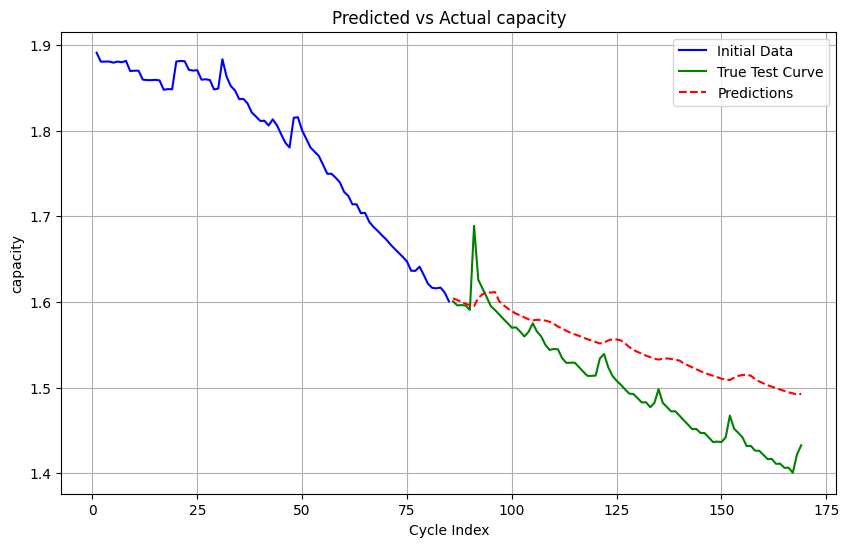

Epoch 1: Validation loss improved to 0.42556043714284897. Model saved!
Epoch 1/200, Train Loss: 0.4303247907332012, Val Loss: 0.42556043714284897
Epoch 2: Validation loss improved to 0.41006647050380707. Model saved!
Epoch 2/200, Train Loss: 0.42262032628059387, Val Loss: 0.41006647050380707
Epoch 3: Validation loss improved to 0.4014451578259468. Model saved!
Epoch 3/200, Train Loss: 0.4139811098575592, Val Loss: 0.4014451578259468
Epoch 4: Validation loss improved to 0.39156609773635864. Model saved!
Epoch 4/200, Train Loss: 0.40005909332207273, Val Loss: 0.39156609773635864
Epoch 5: Validation loss improved to 0.38004160672426224. Model saved!
Epoch 5/200, Train Loss: 0.38876271886484964, Val Loss: 0.38004160672426224
Epoch 6: Validation loss improved to 0.3632798567414284. Model saved!
Epoch 6/200, Train Loss: 0.3801803972039904, Val Loss: 0.3632798567414284
Epoch 7: Validation loss improved to 0.35805511474609375. Model saved!
Epoch 7/200, Train Loss: 0.3682459890842438, Val Loss:

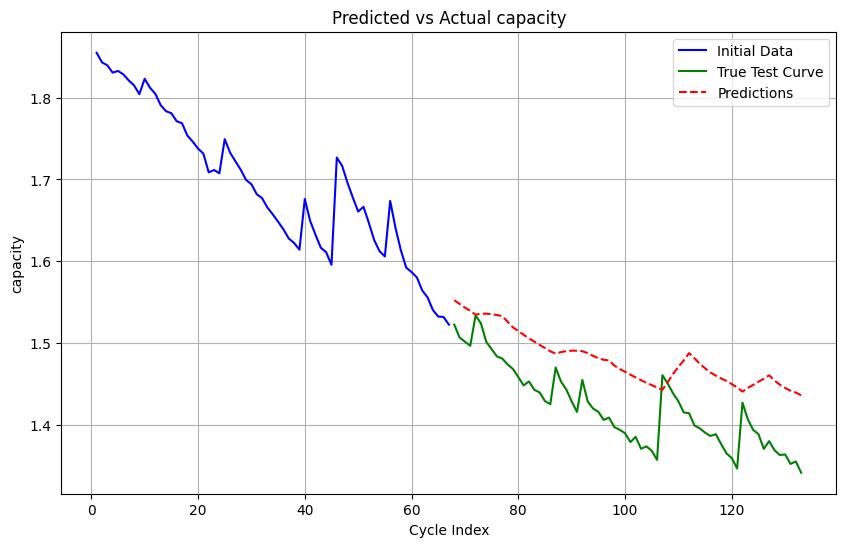

In [93]:

for i in range(4):
    model_3 = BiGRUModel(input_size=5, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    train_model(
        model=model_3,
        train_dataloader=NASA_train_dataloaders_50[i],
        val_dataloader=NASA_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=20,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}_50.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}_50.pth'))
    model_3.to(device)

    metrics = evaluate_model(model_3, NASA_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 50, 5)

## CNN - DBLSTM Model

Epoch 1: Validation loss improved to 0.5929670929908752. Model saved!
Epoch 1/200, Train Loss: 0.5889751315116882, Val Loss: 0.5929670929908752
Epoch 2: Validation loss improved to 0.5805912911891937. Model saved!
Epoch 2/200, Train Loss: 0.5681411669804499, Val Loss: 0.5805912911891937
Epoch 3: Validation loss improved to 0.5797320902347565. Model saved!
Epoch 3/200, Train Loss: 0.5514568182138296, Val Loss: 0.5797320902347565
Epoch 4: Validation loss improved to 0.517889641225338. Model saved!
Epoch 4/200, Train Loss: 0.5316562698437617, Val Loss: 0.517889641225338
Epoch 5: Validation loss improved to 0.4195556864142418. Model saved!
Epoch 5/200, Train Loss: 0.46711986110760617, Val Loss: 0.4195556864142418
Epoch 6: Validation loss improved to 0.2527681142091751. Model saved!
Epoch 6/200, Train Loss: 0.3208592167267433, Val Loss: 0.2527681142091751
Epoch 7: Validation loss improved to 0.10306882672011852. Model saved!
Epoch 7/200, Train Loss: 0.1684574565062156, Val Loss: 0.103068826

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\1433967353.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.00687714188632507
MAE: 0.004618402603453239


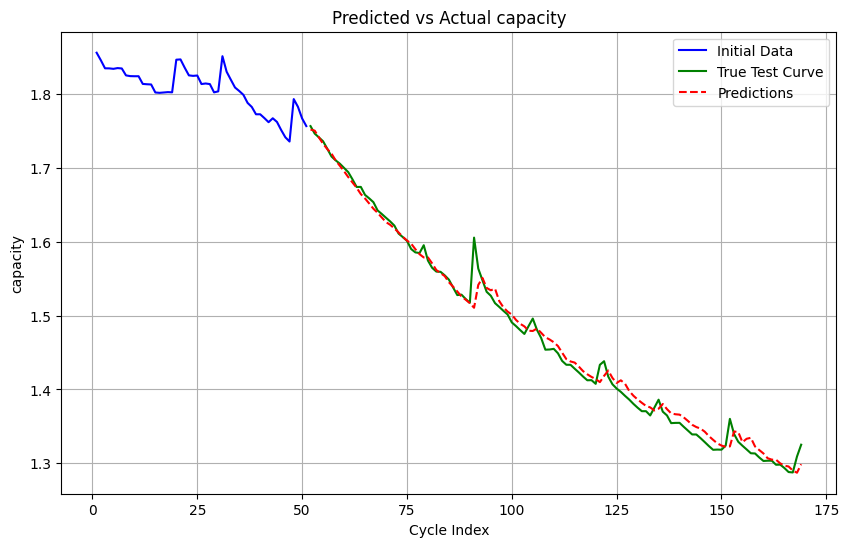

Epoch 1: Validation loss improved to 0.26870615780353546. Model saved!
Epoch 1/200, Train Loss: 0.272008471764051, Val Loss: 0.26870615780353546
Epoch 2: Validation loss improved to 0.25782419741153717. Model saved!
Epoch 2/200, Train Loss: 0.25682397416004765, Val Loss: 0.25782419741153717
Epoch 3: Validation loss improved to 0.24273573607206345. Model saved!
Epoch 3/200, Train Loss: 0.24810264431513274, Val Loss: 0.24273573607206345
Epoch 4: Validation loss improved to 0.21630825847387314. Model saved!
Epoch 4/200, Train Loss: 0.2315354897425725, Val Loss: 0.21630825847387314
Epoch 5: Validation loss improved to 0.09742495976388454. Model saved!
Epoch 5/200, Train Loss: 0.16289806136718163, Val Loss: 0.09742495976388454
Epoch 6: Validation loss improved to 0.012617661384865642. Model saved!
Epoch 6/200, Train Loss: 0.049645813611837536, Val Loss: 0.012617661384865642
Epoch 7: Validation loss improved to 0.009291748283430934. Model saved!
Epoch 7/200, Train Loss: 0.009336481049943429,

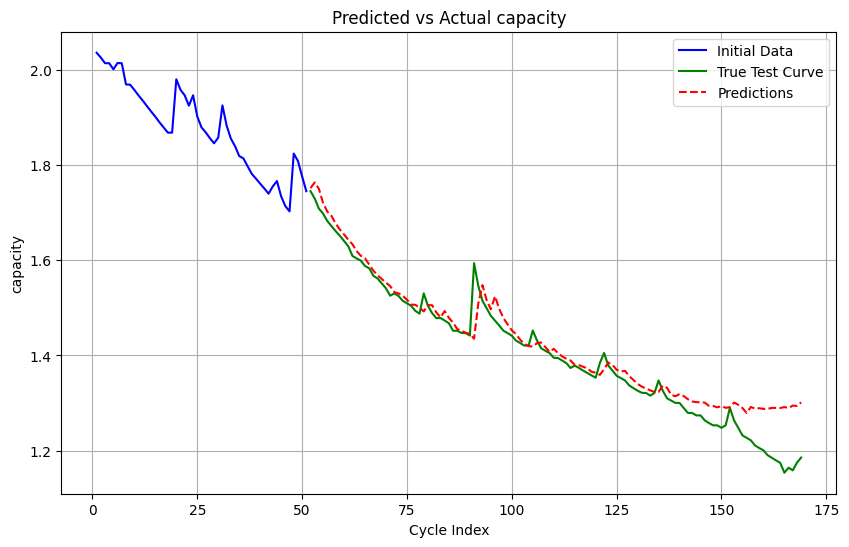

Epoch 1: Validation loss improved to 0.6855396777391434. Model saved!
Epoch 1/200, Train Loss: 0.6556715369224548, Val Loss: 0.6855396777391434
Epoch 2: Validation loss improved to 0.6678405702114105. Model saved!
Epoch 2/200, Train Loss: 0.6326802831429702, Val Loss: 0.6678405702114105
Epoch 3: Validation loss improved to 0.6042971760034561. Model saved!
Epoch 3/200, Train Loss: 0.5933521802608783, Val Loss: 0.6042971760034561
Epoch 4: Validation loss improved to 0.4328923970460892. Model saved!
Epoch 4/200, Train Loss: 0.501606638614948, Val Loss: 0.4328923970460892
Epoch 5: Validation loss improved to 0.16485029831528664. Model saved!
Epoch 5/200, Train Loss: 0.28321835284049696, Val Loss: 0.16485029831528664
Epoch 6: Validation loss improved to 0.016125537222251296. Model saved!
Epoch 6/200, Train Loss: 0.07785444176540925, Val Loss: 0.016125537222251296
Epoch 7: Validation loss improved to 0.013415318680927157. Model saved!
Epoch 7/200, Train Loss: 0.014235311975845924, Val Loss: 

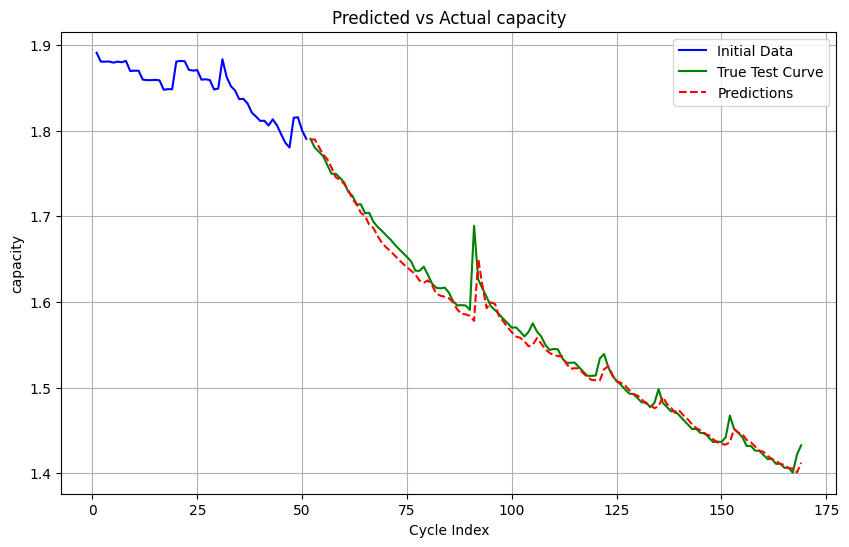

Epoch 1: Validation loss improved to 0.918168842792511. Model saved!
Epoch 1/200, Train Loss: 0.9612966435296195, Val Loss: 0.918168842792511
Epoch 2: Validation loss improved to 0.8851634413003922. Model saved!
Epoch 2/200, Train Loss: 0.9242226140839713, Val Loss: 0.8851634413003922
Epoch 3: Validation loss improved to 0.7732821851968765. Model saved!
Epoch 3/200, Train Loss: 0.8525171620505196, Val Loss: 0.7732821851968765
Epoch 4: Validation loss improved to 0.31339649111032486. Model saved!
Epoch 4/200, Train Loss: 0.5835046257291522, Val Loss: 0.31339649111032486
Epoch 5: Validation loss improved to 0.016232393449172378. Model saved!
Epoch 5/200, Train Loss: 0.13090761019183056, Val Loss: 0.016232393449172378
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.014612733818856733, Val Loss: 0.022312635090202093
Epoch 7: Validation loss improved to 0.010546931880526245. Model saved!
Epoch 7/200, Train Loss: 0.012566564937255211, Val Loss: 0.010546931880526245
Epoch 8: Valida

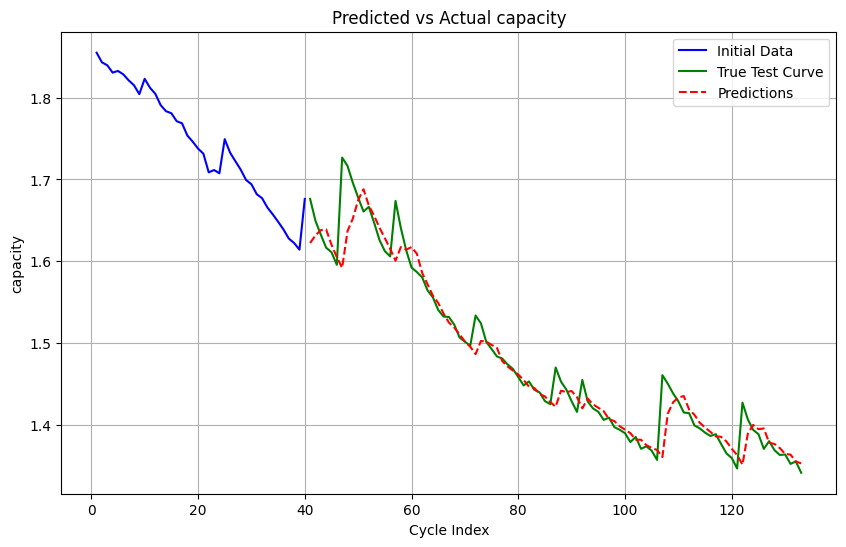

In [86]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_4,
        train_dataloader=NASA_train_dataloaders_30[i],
        val_dataloader=NASA_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}_30.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}_30.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, NASA_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

Epoch 1: Validation loss improved to 1.1969841718673706. Model saved!
Epoch 1/200, Train Loss: 1.1956556950296675, Val Loss: 1.1969841718673706
Epoch 2: Validation loss improved to 1.135363906621933. Model saved!
Epoch 2/200, Train Loss: 1.1476816534996033, Val Loss: 1.135363906621933
Epoch 3: Validation loss improved to 0.9477508813142776. Model saved!
Epoch 3/200, Train Loss: 1.0366911504949843, Val Loss: 0.9477508813142776
Epoch 4: Validation loss improved to 0.39710526168346405. Model saved!
Epoch 4/200, Train Loss: 0.6691923290491104, Val Loss: 0.39710526168346405
Epoch 5: Validation loss improved to 0.04511684086173773. Model saved!
Epoch 5/200, Train Loss: 0.193722059151956, Val Loss: 0.04511684086173773
Epoch 6: Validation loss improved to 0.01649613957852125. Model saved!
Epoch 6/200, Train Loss: 0.01680248583267842, Val Loss: 0.01649613957852125
Epoch 7: Validation loss improved to 0.011409245897084475. Model saved!
Epoch 7/200, Train Loss: 0.014902217180601187, Val Loss: 0.0

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2142896396.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

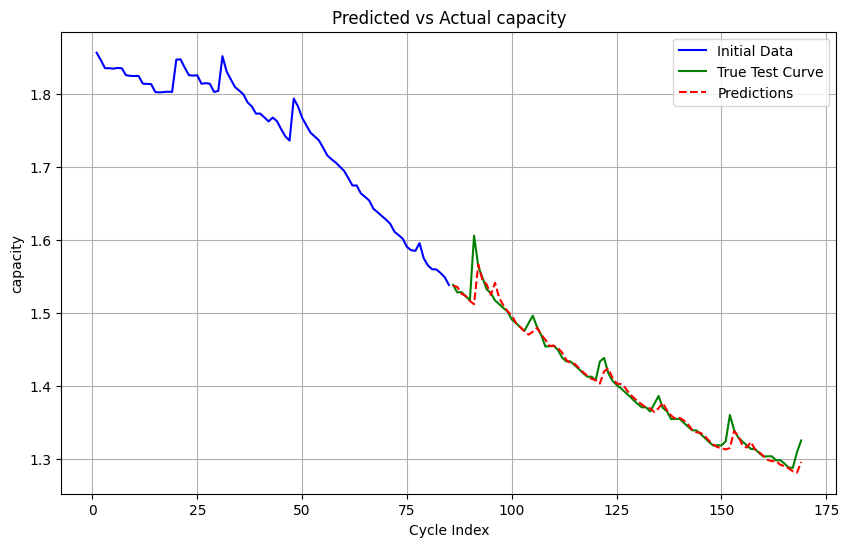

Epoch 1: Validation loss improved to 1.2112616300582886. Model saved!
Epoch 1/200, Train Loss: 1.2236487099102564, Val Loss: 1.2112616300582886
Epoch 2: Validation loss improved to 1.132736325263977. Model saved!
Epoch 2/200, Train Loss: 1.167926984173911, Val Loss: 1.132736325263977
Epoch 3: Validation loss improved to 0.9629344344139099. Model saved!
Epoch 3/200, Train Loss: 1.0592490349497115, Val Loss: 0.9629344344139099
Epoch 4: Validation loss improved to 0.26426343619823456. Model saved!
Epoch 4/200, Train Loss: 0.6240232842309135, Val Loss: 0.26426343619823456
Epoch 5: Validation loss improved to 0.01027787709608674. Model saved!
Epoch 5/200, Train Loss: 0.07993537679846797, Val Loss: 0.01027787709608674
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.021446849053193415, Val Loss: 0.012346580624580383
Epoch 7: Validation loss improved to 0.007996538071893156. Model saved!
Epoch 7/200, Train Loss: 0.007883302767628006, Val Loss: 0.007996538071893156
Epoch 8: Validatio

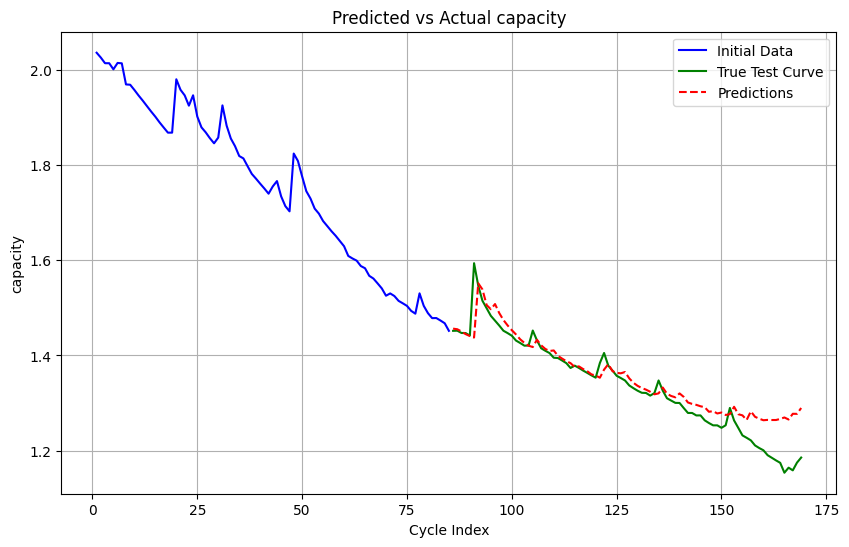

Epoch 1: Validation loss improved to 0.2459648661315441. Model saved!
Epoch 1/200, Train Loss: 0.2566851026245526, Val Loss: 0.2459648661315441
Epoch 2: Validation loss improved to 0.21393059939146042. Model saved!
Epoch 2/200, Train Loss: 0.23830566235951015, Val Loss: 0.21393059939146042
Epoch 3: Validation loss improved to 0.1687789298593998. Model saved!
Epoch 3/200, Train Loss: 0.20435728239161627, Val Loss: 0.1687789298593998
Epoch 4: Validation loss improved to 0.049086821265518665. Model saved!
Epoch 4/200, Train Loss: 0.11843231852565493, Val Loss: 0.049086821265518665
Epoch 5: Validation loss improved to 0.010411751456558704. Model saved!
Epoch 5/200, Train Loss: 0.021691239372427975, Val Loss: 0.010411751456558704
Epoch 6: Validation loss improved to 0.007529296330176294. Model saved!
Epoch 6/200, Train Loss: 0.00983900879509747, Val Loss: 0.007529296330176294
Epoch 7: Validation loss improved to 0.003874336660373956. Model saved!
Epoch 7/200, Train Loss: 0.00581209797279110

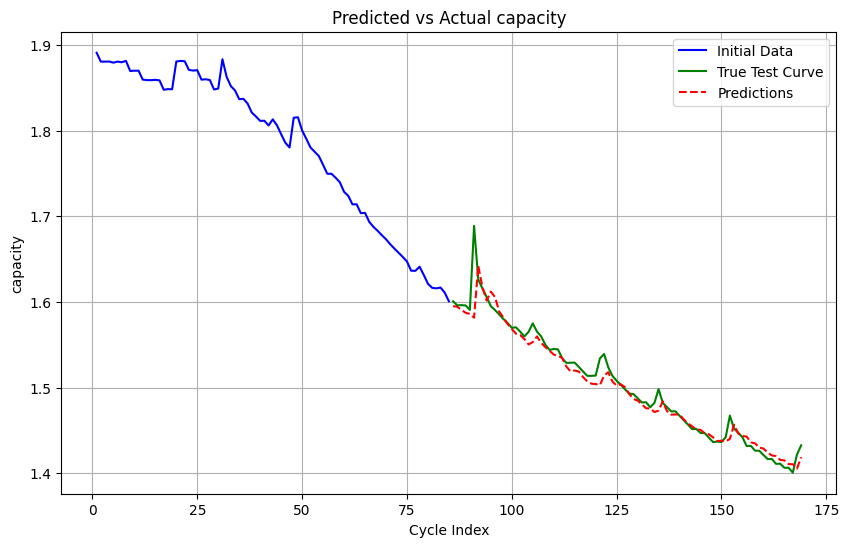

Epoch 1: Validation loss improved to 0.43637458235025406. Model saved!
Epoch 1/200, Train Loss: 0.4484571729387556, Val Loss: 0.43637458235025406
Epoch 2: Validation loss improved to 0.4102998822927475. Model saved!
Epoch 2/200, Train Loss: 0.4248672127723694, Val Loss: 0.4102998822927475
Epoch 3: Validation loss improved to 0.3733191415667534. Model saved!
Epoch 3/200, Train Loss: 0.3960081402744566, Val Loss: 0.3733191415667534
Epoch 4: Validation loss improved to 0.16553327813744545. Model saved!
Epoch 4/200, Train Loss: 0.2931783656988825, Val Loss: 0.16553327813744545
Epoch 5: Validation loss improved to 0.009179520886391401. Model saved!
Epoch 5/200, Train Loss: 0.0607359638836767, Val Loss: 0.009179520886391401
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.013723424436258418, Val Loss: 0.010569245787337422
Epoch 7: Validation loss improved to 0.006778177805244923. Model saved!
Epoch 7/200, Train Loss: 0.007022945975352611, Val Loss: 0.006778177805244923
Epoch 8: Val

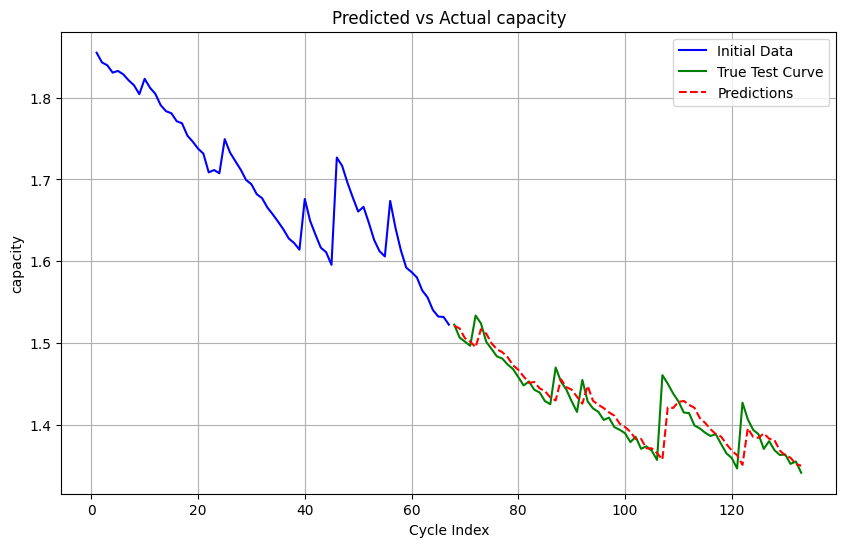

In [87]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_4,
        train_dataloader=NASA_train_dataloaders_50[i],
        val_dataloader=NASA_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}_50.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}_50.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, NASA_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 50, 5)

## CNN - ASTLSTM

Epoch 1: Validation loss improved to 0.01322863600216806. Model saved!
Epoch 1/200, Train Loss: 0.07685235801797646, Val Loss: 0.01322863600216806
Epoch 2: Validation loss improved to 0.008702210616320372. Model saved!
Epoch 2/200, Train Loss: 0.017849253204006415, Val Loss: 0.008702210616320372
Epoch 3: Validation loss improved to 0.008481536817271262. Model saved!
Epoch 3/200, Train Loss: 0.010952046355948998, Val Loss: 0.008481536817271262
Epoch 4: No improvement. (1/30)
Epoch 4/200, Train Loss: 0.010205584220015086, Val Loss: 0.008534964523278177
Epoch 5: No improvement. (2/30)
Epoch 5/200, Train Loss: 0.01008590984229858, Val Loss: 0.009346537059172988
Epoch 6: No improvement. (3/30)
Epoch 6/200, Train Loss: 0.010093619079830555, Val Loss: 0.009679480222985148
Epoch 7: Validation loss improved to 0.007738103158771992. Model saved!
Epoch 7/200, Train Loss: 0.009759184259634752, Val Loss: 0.007738103158771992
Epoch 8: No improvement. (1/30)
Epoch 8/200, Train Loss: 0.009960053703532

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\4225898822.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConsta

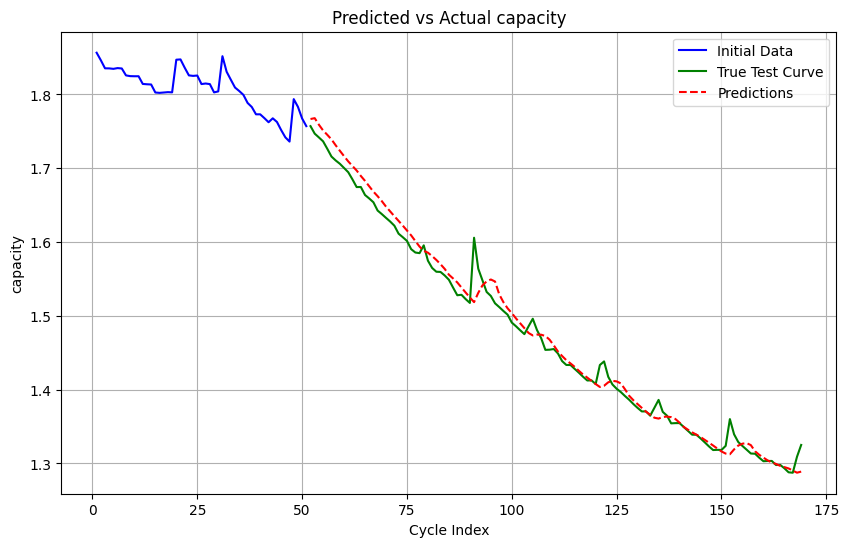

Epoch 1: Validation loss improved to 0.6087529510259628. Model saved!
Epoch 1/200, Train Loss: 0.8098995272929852, Val Loss: 0.6087529510259628
Epoch 2: Validation loss improved to 0.36957652121782303. Model saved!
Epoch 2/200, Train Loss: 0.5066890922876505, Val Loss: 0.36957652121782303
Epoch 3: Validation loss improved to 0.10222535952925682. Model saved!
Epoch 3/200, Train Loss: 0.2392904099363547, Val Loss: 0.10222535952925682
Epoch 4: Validation loss improved to 0.018471582094207406. Model saved!
Epoch 4/200, Train Loss: 0.03530130374173705, Val Loss: 0.018471582094207406
Epoch 5: Validation loss improved to 0.009427267359569669. Model saved!
Epoch 5/200, Train Loss: 0.01856382520726094, Val Loss: 0.009427267359569669
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.009163769248586435, Val Loss: 0.01004238217137754
Epoch 7: Validation loss improved to 0.007898904266767204. Model saved!
Epoch 7/200, Train Loss: 0.008599176752166105, Val Loss: 0.007898904266767204
Epoch 8

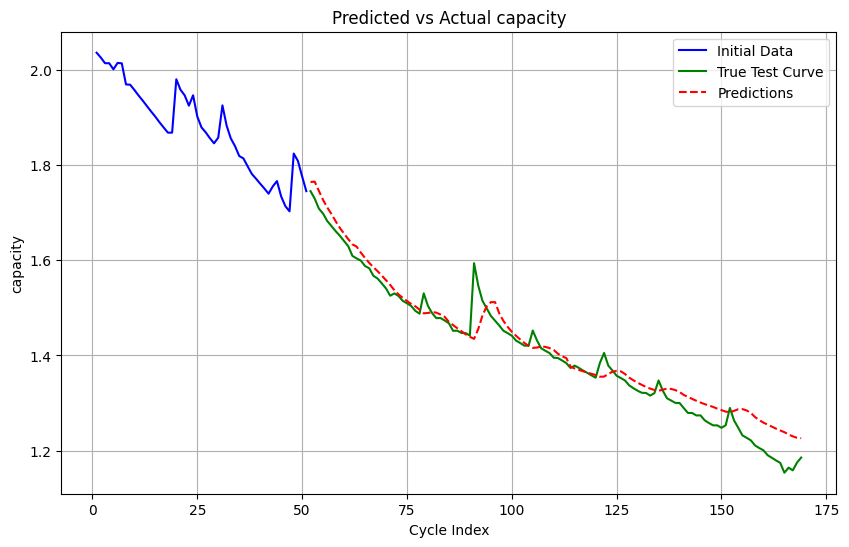

Epoch 1: Validation loss improved to 0.07459534239023924. Model saved!
Epoch 1/200, Train Loss: 0.3777762410732416, Val Loss: 0.07459534239023924
Epoch 2: Validation loss improved to 0.014471106114797294. Model saved!
Epoch 2/200, Train Loss: 0.022685700382750768, Val Loss: 0.014471106114797294
Epoch 3: Validation loss improved to 0.009728801902383566. Model saved!
Epoch 3/200, Train Loss: 0.016729556024074554, Val Loss: 0.009728801902383566
Epoch 4: No improvement. (1/30)
Epoch 4/200, Train Loss: 0.011503647511395125, Val Loss: 0.010368095128796995
Epoch 5: No improvement. (2/30)
Epoch 5/200, Train Loss: 0.011393526927209817, Val Loss: 0.009948020800948143
Epoch 6: No improvement. (3/30)
Epoch 6/200, Train Loss: 0.011193687955920514, Val Loss: 0.012684687739238143
Epoch 7: No improvement. (4/30)
Epoch 7/200, Train Loss: 0.011066901712463452, Val Loss: 0.011577325407415628
Epoch 8: No improvement. (5/30)
Epoch 8/200, Train Loss: 0.011226993878013812, Val Loss: 0.010720520280301571
Epoc

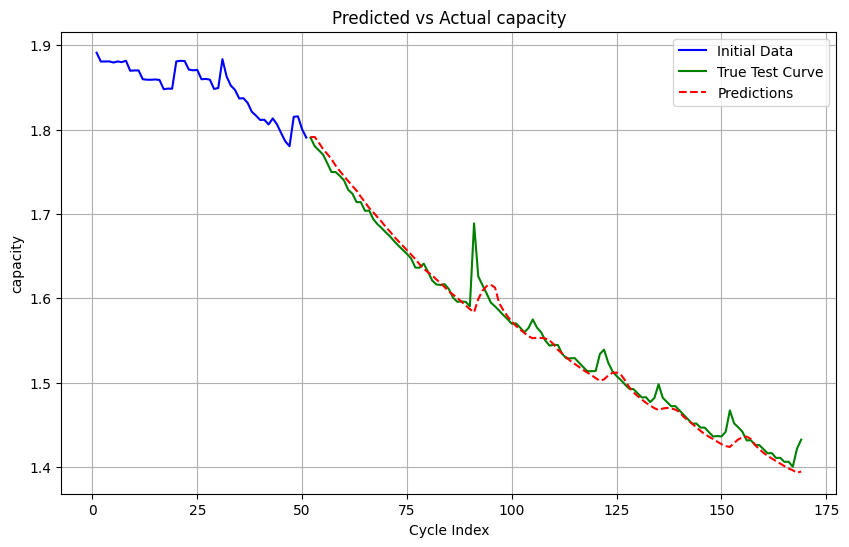

Epoch 1: Validation loss improved to 0.036346720065921545. Model saved!
Epoch 1/200, Train Loss: 0.14509430368031775, Val Loss: 0.036346720065921545
Epoch 2: Validation loss improved to 0.026470670010894537. Model saved!
Epoch 2/200, Train Loss: 0.01704271011320608, Val Loss: 0.026470670010894537
Epoch 3: Validation loss improved to 0.013006113935261965. Model saved!
Epoch 3/200, Train Loss: 0.011634274419131023, Val Loss: 0.013006113935261965
Epoch 4: Validation loss improved to 0.009891589172184467. Model saved!
Epoch 4/200, Train Loss: 0.010321866837330163, Val Loss: 0.009891589172184467
Epoch 5: No improvement. (1/30)
Epoch 5/200, Train Loss: 0.008661532641521521, Val Loss: 0.011480740737169981
Epoch 6: No improvement. (2/30)
Epoch 6/200, Train Loss: 0.009070534159296326, Val Loss: 0.011484478018246591
Epoch 7: No improvement. (3/30)
Epoch 7/200, Train Loss: 0.009009032044559717, Val Loss: 0.012514195870608091
Epoch 8: No improvement. (4/30)
Epoch 8/200, Train Loss: 0.0089763883567

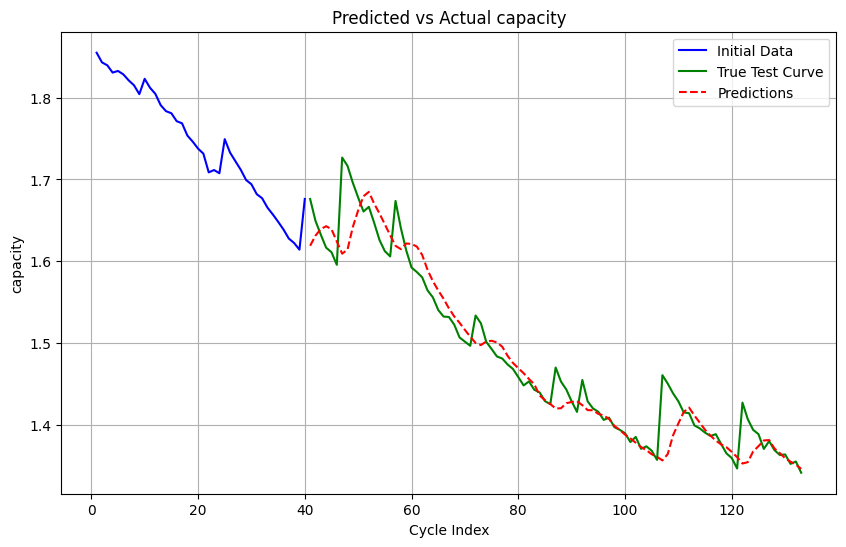

In [97]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_5,
        train_dataloader=NASA_train_dataloaders_30[i],
        val_dataloader=NASA_val_dataloaders_30[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_30.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_30.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, NASA_test_dataloaders_30[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

Epoch 1: Validation loss improved to 0.033441121224313974. Model saved!
Epoch 1/200, Train Loss: 0.08543395557041679, Val Loss: 0.033441121224313974
Epoch 2: Validation loss improved to 0.0130845766980201. Model saved!
Epoch 2/200, Train Loss: 0.0202191240553345, Val Loss: 0.0130845766980201
Epoch 3: Validation loss improved to 0.009248352842405438. Model saved!
Epoch 3/200, Train Loss: 0.011401846805321319, Val Loss: 0.009248352842405438
Epoch 4: No improvement. (1/30)
Epoch 4/200, Train Loss: 0.009748599358967372, Val Loss: 0.010115142911672592
Epoch 5: No improvement. (2/30)
Epoch 5/200, Train Loss: 0.009202274893011366, Val Loss: 0.009930664673447609
Epoch 6: No improvement. (3/30)
Epoch 6/200, Train Loss: 0.009492649996121014, Val Loss: 0.009931608103215694
Epoch 7: No improvement. (4/30)
Epoch 7/200, Train Loss: 0.009081360884010792, Val Loss: 0.010321613634005189
Epoch 8: No improvement. (5/30)
Epoch 8/200, Train Loss: 0.008940875064581633, Val Loss: 0.009872834663838148
Epoch 9

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_12152\2527378258.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConsta

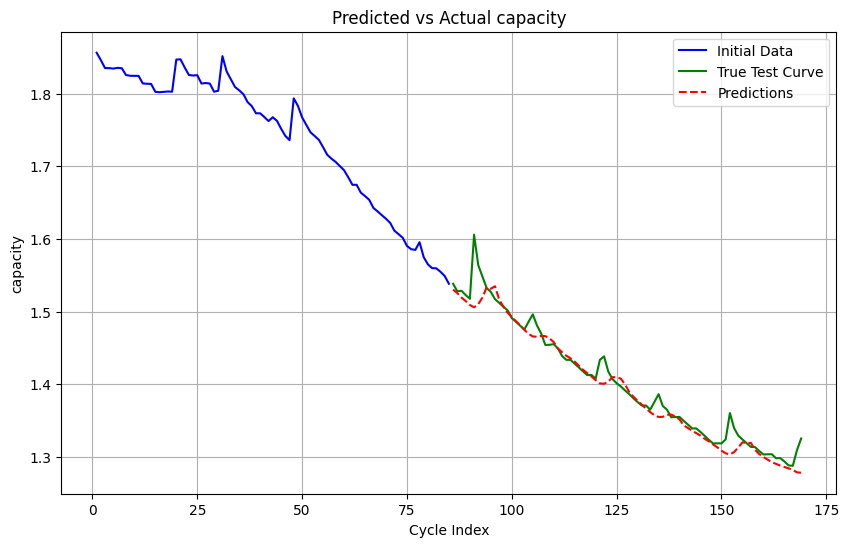

Epoch 1: Validation loss improved to 0.01263410784304142. Model saved!
Epoch 1/200, Train Loss: 0.04248825813244496, Val Loss: 0.01263410784304142
Epoch 2: Validation loss improved to 0.00839276285842061. Model saved!
Epoch 2/200, Train Loss: 0.009227079771725195, Val Loss: 0.00839276285842061
Epoch 3: Validation loss improved to 0.007531713228672743. Model saved!
Epoch 3/200, Train Loss: 0.008121912035026721, Val Loss: 0.007531713228672743
Epoch 4: Validation loss improved to 0.007419485133141279. Model saved!
Epoch 4/200, Train Loss: 0.007687356622357454, Val Loss: 0.007419485133141279
Epoch 5: No improvement. (1/30)
Epoch 5/200, Train Loss: 0.007579737958232207, Val Loss: 0.008121112128719687
Epoch 6: No improvement. (2/30)
Epoch 6/200, Train Loss: 0.007989236918677176, Val Loss: 0.008168783271685243
Epoch 7: No improvement. (3/30)
Epoch 7/200, Train Loss: 0.007695108918207032, Val Loss: 0.008674990385770798
Epoch 8: No improvement. (4/30)
Epoch 8/200, Train Loss: 0.0076480271693851

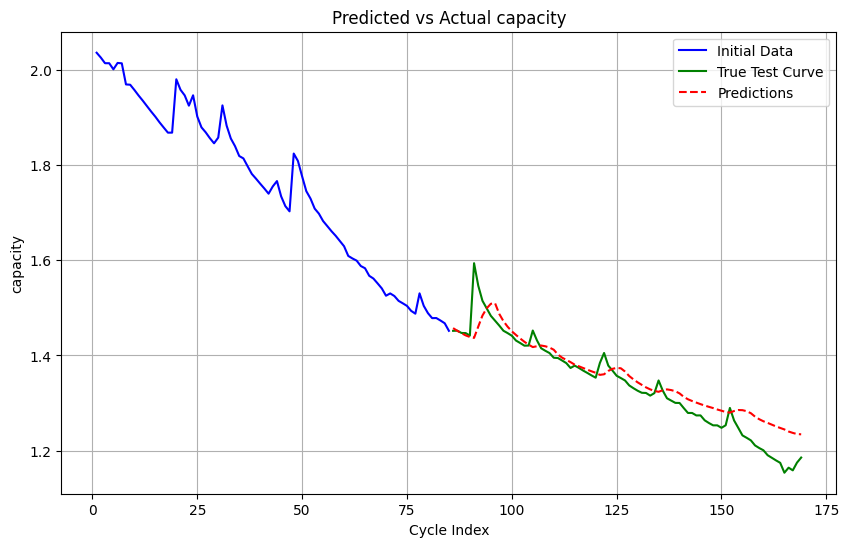

Epoch 1: Validation loss improved to 0.36277979612350464. Model saved!
Epoch 1/200, Train Loss: 0.5548493819577354, Val Loss: 0.36277979612350464
Epoch 2: Validation loss improved to 0.1295984387397766. Model saved!
Epoch 2/200, Train Loss: 0.26453016911234173, Val Loss: 0.1295984387397766
Epoch 3: Validation loss improved to 0.008836788590997458. Model saved!
Epoch 3/200, Train Loss: 0.06003894829856498, Val Loss: 0.008836788590997458
Epoch 4: No improvement. (1/30)
Epoch 4/200, Train Loss: 0.01603383823697056, Val Loss: 0.014642355963587761
Epoch 5: No improvement. (2/30)
Epoch 5/200, Train Loss: 0.011892600284357156, Val Loss: 0.009593436261638999
Epoch 6: No improvement. (3/30)
Epoch 6/200, Train Loss: 0.0102471657696047, Val Loss: 0.009073619614355266
Epoch 7: No improvement. (4/30)
Epoch 7/200, Train Loss: 0.010105071788919824, Val Loss: 0.009191017248667777
Epoch 8: No improvement. (5/30)
Epoch 8/200, Train Loss: 0.009843990373026048, Val Loss: 0.008966170717030764
Epoch 9: No i

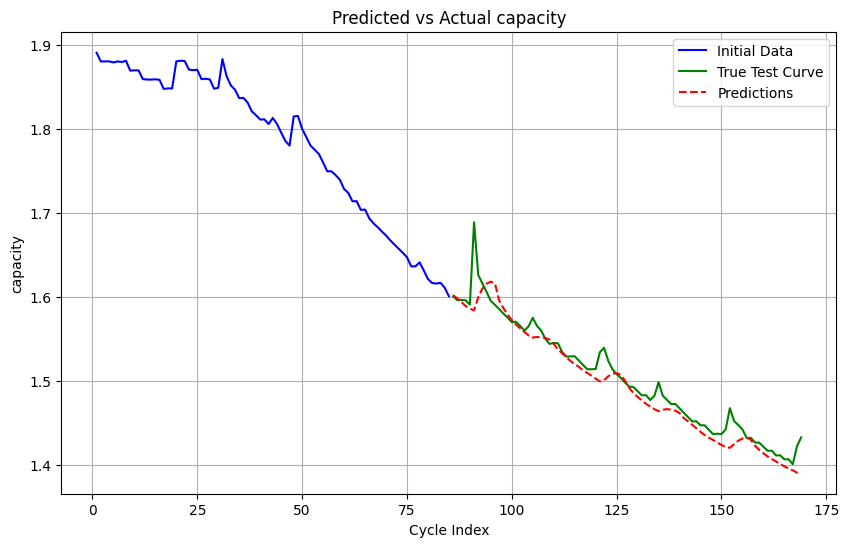

Epoch 1: Validation loss improved to 0.014121655141934752. Model saved!
Epoch 1/200, Train Loss: 0.06356905340882284, Val Loss: 0.014121655141934752
Epoch 2: Validation loss improved to 0.012052161619067192. Model saved!
Epoch 2/200, Train Loss: 0.016973551429275955, Val Loss: 0.012052161619067192
Epoch 3: Validation loss improved to 0.011615863535553217. Model saved!
Epoch 3/200, Train Loss: 0.010432307608425617, Val Loss: 0.011615863535553217
Epoch 4: No improvement. (1/30)
Epoch 4/200, Train Loss: 0.009931378332631928, Val Loss: 0.011687415884807706
Epoch 5: Validation loss improved to 0.010924915550276637. Model saved!
Epoch 5/200, Train Loss: 0.009487281021262919, Val Loss: 0.010924915550276637
Epoch 6: Validation loss improved to 0.010509704472497106. Model saved!
Epoch 6/200, Train Loss: 0.009337855636009149, Val Loss: 0.010509704472497106
Epoch 7: Validation loss improved to 0.009902216726914048. Model saved!
Epoch 7/200, Train Loss: 0.0091284364794514, Val Loss: 0.009902216726

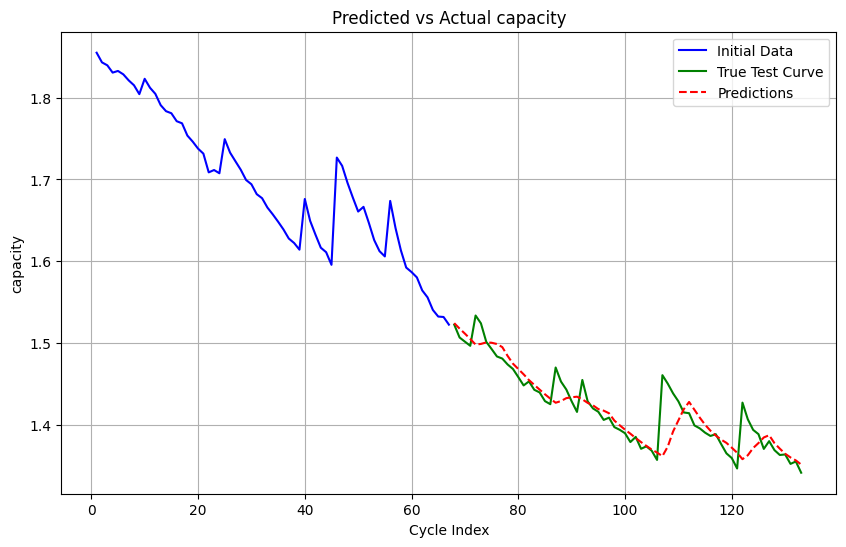

In [99]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_5,
        train_dataloader=NASA_train_dataloaders_50[i],
        val_dataloader=NASA_val_dataloaders_50[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_50.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}_50.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, NASA_test_dataloaders_50[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 50, 5)